# Amazon Mattress Market Analysis_v02

### NPI data 추가

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

#### - Mattress Datasets

In [7]:
# get the Matttress data from BigQuery
sql = f"""
select * from wook.stckln_amz_mattress_ms_trend 
"""

df_mattress = bqclient.query(sql).to_dataframe()

In [9]:
print(df_mattress)

        RetailerSku         category    subcategory profile size_raw   size  \
0        B09JP9N6GL  Spring Mattress        Bonnell      12    Queen  Queen   
1        B0CQD3CMXN  Spring Mattress        Bonnell       6     Twin   Twin   
2        B07BNS7M21  Spring Mattress        Bonnell       8        K   King   
3        B07BNS7M21  Spring Mattress        Bonnell       8        K   King   
4        B07BNRS5V6  Spring Mattress        Bonnell       8        T   Twin   
...             ...              ...            ...     ...      ...    ...   
1028080  B0CCD8TBMF  Spring Mattress  Pocket Spring      12        K   King   
1028081  B0CCD8TBMF  Spring Mattress  Pocket Spring      12        K   King   
1028082  B0CCD8TBMF  Spring Mattress  Pocket Spring      12        K   King   
1028083  B0DX1TJR2G  Spring Mattress  Pocket Spring      12     King   King   
1028084  B0C817KR5D  Spring Mattress  Pocket Spring      10    Queen  Queen   

        bsr_ctgry_label                   Brand_raw

#### - NRR Data

In [79]:
# get the NRR data from BigQuery
sql = f"""
select * from wook.amz_nrr_add_brand_category_listed_since 
"""

df_nrr = bqclient.query(sql).to_dataframe()

In [81]:
print(df_nrr)

            asin                                              title  \
0     B0D7QXSCNG  GAESTE 8 Inch Twin XL Cooling Gel Memory Foam ...   
1     B0CYGNT3P7  EGOHOME 10 Inch Twin XL Mattress, Cooling Gel ...   
2     B0D83MJL8L  AMICLIBER 3 Inch Tri-Fold Mattress, Small Sing...   
3     B0F7G97MQ1  AYDMI 45D High-Density Foam Sagging Mattress S...   
4     B0DZHZ1XF9  Amzreine Baby Bassinet Mattress Topper, 30" x ...   
...          ...                                                ...   
6616  B0DWTD7WG4  Twin XL Mattress, Memory Foam Medium Firm Hybr...   
6617  B0CQMWLNL3  koorlian Twin XL Adjustable Bed Mattress, 10 i...   
6618  B0CQN1N3P8  koorlian Twin XL Adjustable Bed Mattress, 12 i...   
6619  B0DPWVXNWV  pengucool 10 Inch Twin XL Memory Foam Mattress...   
6620  B0DR26MW7G  sleeprove Twin XL Size Mattress, 6 Inch Hybrid...   

      sales_2024  sales_2025  units_sold_2024  units_sold_2025  price_2024  \
0       73893.19    76475.68            533.0            579.0   142.

In [11]:
df_mattress['RetailerSku'].nunique()

39252

In [13]:
df_mattress['Brand_raw'].nunique()

1629

In [15]:
# WeekEnding이 object 타입이라면 datetime으로 변환
df_mattress['WeekEnding'] = pd.to_datetime(df_mattress['WeekEnding'], errors='coerce')

# 연도 컬럼 추가
df_mattress['year'] =df_mattress['WeekEnding'].dt.year
df_mattress['year'].isna().sum()

0

In [17]:
df_mattress['yr_half'] = df_mattress['yr_month'].apply(
    lambda ym: f"{ym.split('-')[0]}-H1" if int(ym.split('-')[1]) <= 6 else f"{ym.split('-')[0]}-H2"
)

In [19]:
df_mattress.head(5)

,RetailerSku,category,subcategory,profile,size_raw,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B09JP9N6GL,Spring Mattress,Bonnell,12,Queen,Queen,01. Mattresses,NUTAN,NUTAN,12-Inch Medium Plush Double Sided Pillowtop In...,...,1,535.91,24-1,24-02,Y24 W07,Y24 W07,1.788970e+06,56676.11,2024,24-H1
1,B0CQD3CMXN,Spring Mattress,Bonnell,6,Twin,Twin,01. Mattresses,AC PACIFIC,AC PACIFIC,AC Pacific Pure 6 Inch Firm Mattress with Bonn...,...,5,88.98,25-1,25-02,Y25 W09,Y25 W09,7.861180e+06,105343.54,2025,25-H1
2,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,3,324.10,25-1,25-01,Y25 W03,Y25 W03,4.408013e+08,17525453.16,2025,25-H1
3,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,49,224.98,19-2,19-05,Y19 W19,Y19 W19,4.408013e+08,17525453.16,2019,19-H1
4,B07BNRS5V6,Spring Mattress,Bonnell,8,T,Twin,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,55,139.99,23-3,23-08,Y23 W33,Y23 W33,4.408013e+08,17525453.16,2023,23-H2


### 1. 기초 데이터 분석 - Mattress 카테고리

#### - 2025년 기준 제품 개수, 브랜드 개수

In [21]:
df1 = df_mattress.copy()

In [25]:
df_2025 = df1[df1['year'] == 2025].copy()

In [53]:
# Brand_raw별 매출 합계 집계
asin_sales_2025 = (
    df_2025.groupby('RetailerSku')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = asin_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
asin_sales_2025['Ratio'] = asin_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
asin_sales_2025['Cumul'] = asin_sales_2025['Ratio'].cumsum()

print(asin_sales_2025)
asin_sales_2025.to_csv('asin_sales_2025_0808.csv', index=False)

      RetailerSku  RetailSales         Ratio     Cumul
3879   B0BCYPWNWT  12592922.62  1.132074e-02  0.011321
6145   B0CKYZ3B83  12325229.33  1.108009e-02  0.022401
6169   B0CKZ1CK1H  10629906.86  9.556039e-03  0.031957
9340   B0DCXFXGBM   9334579.00  8.391569e-03  0.040348
1529   B083YYBNF9   9106938.52  8.186926e-03  0.048535
...           ...          ...           ...       ...
12241  B0DWK3F59V         6.00  5.393860e-09  1.000000
12423  B0DX7LG9M6         5.00  4.494883e-09  1.000000
12421  B0DX7K6XQ2         3.00  2.696930e-09  1.000000
12419  B0DX7JD1JS         2.00  1.797953e-09  1.000000
12422  B0DX7L51KZ         1.00  8.989767e-10  1.000000

[14416 rows x 4 columns]


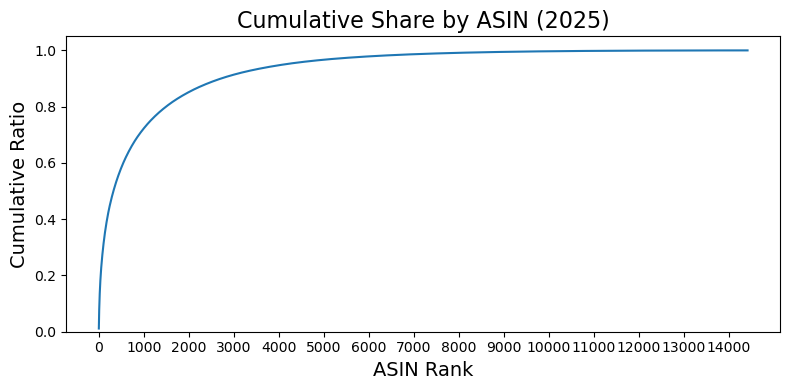

In [39]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(asin_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(8, 4))
plt.plot(x_labels, asin_sales_2025['Cumul'])

# 제목과 축 라벨 폰트 크기 확대
plt.title("Cumulative Share by ASIN (2025)", fontsize=16)
plt.xlabel("ASIN Rank", fontsize=14)
plt.ylabel("Cumulative Ratio", fontsize=14)

plt.ylim(0, 1.05)

# x축 라벨을 1000 단위로 설정 + 폰트 크기 키우기
step = 1000
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step], fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [33]:
#asin_sales_2025.to_csv('asin_sales_2025.csv', index=False)

In [55]:
# 2025년 데이터 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = brand_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
brand_sales_2025['Ratio'] = brand_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
brand_sales_2025['Cumul'] = brand_sales_2025['Ratio'].cumsum()
print(brand_sales_2025)

brand_sales_2025.to_csv('brand_sales_2025_0808.csv', index=False)

       Brand_raw   RetailSales         Ratio     Cumul
686        ZINUS  1.773575e+08  1.594402e-01  0.159440
435      NOVILLA  7.764270e+07  6.979898e-02  0.229239
190          FDW  4.342930e+07  3.904193e-02  0.268281
424       NECTAR  4.239187e+07  3.810930e-02  0.306390
400        MLILY  4.233994e+07  3.806262e-02  0.344453
..           ...           ...           ...       ...
246       HOKWAY  4.999000e+01  4.493985e-08  1.000000
368   MASTERMARK  4.299000e+01  3.864701e-08  1.000000
102      COCOARM  3.412000e+01  3.067308e-08  1.000000
684       ZERONE  2.842000e+01  2.554892e-08  1.000000
376  MAXXI CLEAN  2.600000e+01  2.337339e-08  1.000000

[695 rows x 4 columns]


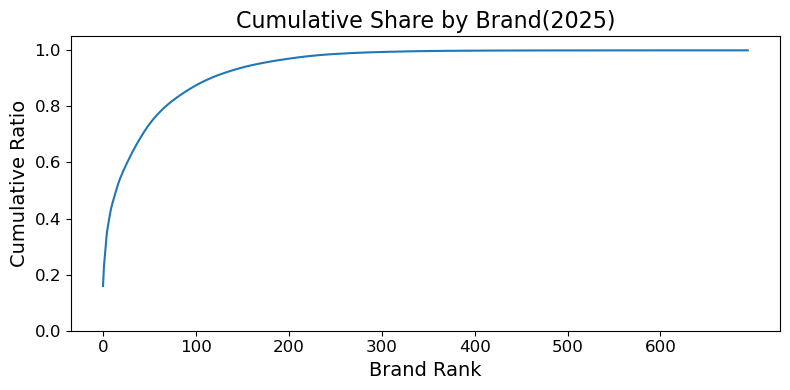

In [51]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(brand_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(8, 4))
plt.plot(x_labels, brand_sales_2025['Cumul'])

# 제목과 축 라벨 폰트 크기 확대
plt.title("Cumulative Share by Brand(2025)", fontsize=16)
plt.xlabel("Brand Rank", fontsize=14)
plt.ylabel("Cumulative Ratio", fontsize=14)

plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정 + 폰트 크기 조정
step = 100
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step], fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

#### - 년도별 시장 크기

In [58]:
df1 = df_mattress.copy()

In [64]:
df1

,RetailerSku,category,subcategory,profile,size_raw,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07TGF1KHC,Spring Mattress,Bonnell,9,Twin,Twin,01. Mattresses,MAYTON,MAYTON,9-Inch Medium Firm Tight top Innerspring Fully...,...,1,187.99,22-4,22-10,Y22 W41,Y22 W41,1.179975e+06,101024.19,2022,22-H2
1,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,149,209.94,20-2,20-04,Y20 W14,Y20 W14,4.408013e+08,17525453.16,2020,20-H1
2,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,29,185.25,20-4,20-12,Y20 W49,Y20 W49,4.408013e+08,17525453.16,2020,20-H2
3,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,5,299.99,21-4,21-10,Y21 W40,Y21 W40,4.408013e+08,17525453.16,2021,21-H2
4,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,3,290.50,19-3,19-08,Y19 W32,Y19 W32,4.408013e+08,17525453.16,2019,19-H2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028080,B0BXL3ZDRX,Spring Mattress,Pocket Spring,14,Queen,Queen,01. Mattresses,SOFREE BEDDING,SOFREE BEDDING,"sofree bedding Queen Size Mattress, 14 Inch Me...",...,1,209.98,24-3,24-07,Y24 W27,Y24 W27,1.852687e+07,2334475.95,2024,24-H2
1028081,B0DLGHKQPP,Spring Mattress,Pocket Spring,10,King,King,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it King Size Mattress, 10 Inch King Mattr...",...,2,299.99,24-4,24-11,Y24 W46,Y24 W46,2.864487e+06,38212.60,2024,24-H2
1028082,B0C817LWT9,Spring Mattress,Pocket Spring,10,Queen,Queen,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Queen Mattress, 10 Inch Queen Mattress...",...,5,209.99,24-2,24-04,Y24 W16,Y24 W16,2.864487e+06,38212.60,2024,24-H1
1028083,B0C817LWT9,Spring Mattress,Pocket Spring,10,Queen,Queen,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Queen Mattress, 10 Inch Queen Mattress...",...,1,209.99,24-2,24-06,Y24 W23,Y24 W23,2.864487e+06,38212.60,2024,24-H1


In [62]:
df1.groupby('year')['RetailSales'].sum()

year
2019    9.500844e+08
2020    1.144626e+09
2021    1.407931e+09
2022    1.575243e+09
2023    1.750982e+09
2024    1.877684e+09
2025    1.112376e+09
Name: RetailSales, dtype: float64

In [66]:
df1['yr_week'].min()

'Y19 W01'

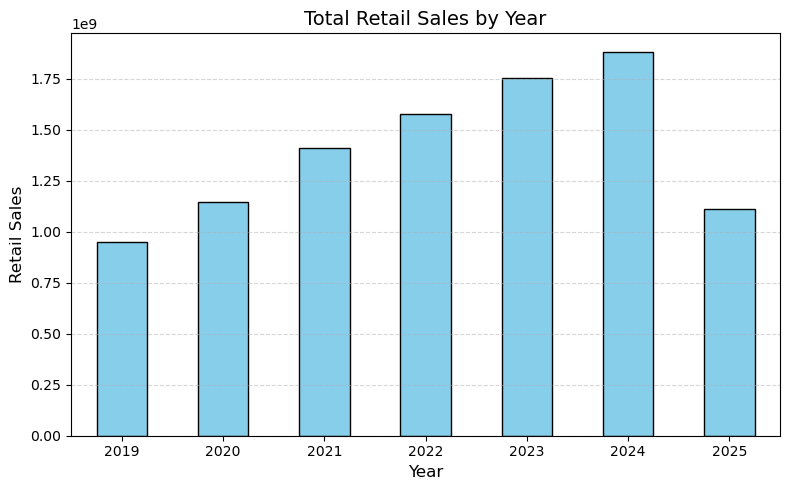

In [68]:
# 연도별 매출 합계
year_sales = df1.groupby('year')['RetailSales'].sum()

# 막대그래프 그리기
plt.figure(figsize=(8, 5))
year_sales.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Total Retail Sales by Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Retail Sales", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### - Prifile(Inch) 별 매출

In [156]:
df1 = df_mattress.copy()
df_2025 = df1[df1['year'] == 2025].copy()

In [158]:
profile_grp = (
    df_2025
    .groupby('profile')
    .agg(
        sku_count=('RetailerSku', 'nunique'),
        total_sales=('RetailSales', 'sum')
    )
    .reset_index()
)
print(profile_grp)

   profile  sku_count   total_sales
0      0.4          2  1.775040e+03
1      0.5          2  1.746486e+04
2        1          3  3.068440e+03
3       10       2454  1.739560e+08
4     10.5         18  2.848325e+05
..     ...        ...           ...
57     8.0          1  3.790000e+02
58     8.5         15  1.131683e+06
59       9        107  2.828166e+06
60    9.25          6  5.659231e+05
61     9.5         13  7.610019e+05

[62 rows x 3 columns]


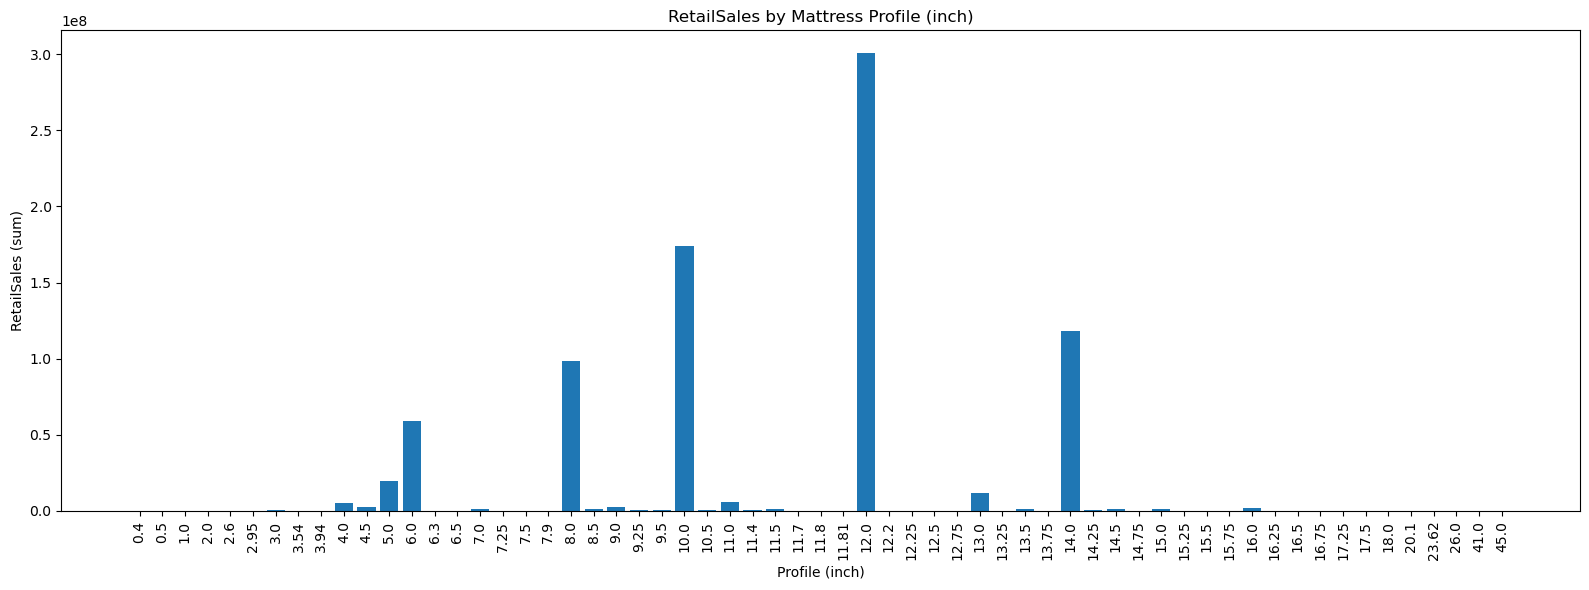

In [165]:

# profile 값 전처리
df_2025['profile'] = pd.to_numeric(df_2025['profile'], errors='coerce')
df_2025 = df_2025[df_2025['profile'].notnull()]

# 각 profile(inch) 별 RetailSales 합계 집계
sales_by_profile = (
    df_2025
    .groupby('profile')['RetailSales']
    .sum()
    .reset_index()
    .sort_values('profile')
)

# Plot
plt.figure(figsize=(16, 6))
plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
plt.xlabel('Profile (inch)')
plt.ylabel('RetailSales (sum)')
plt.title('RetailSales by Mattress Profile (inch)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

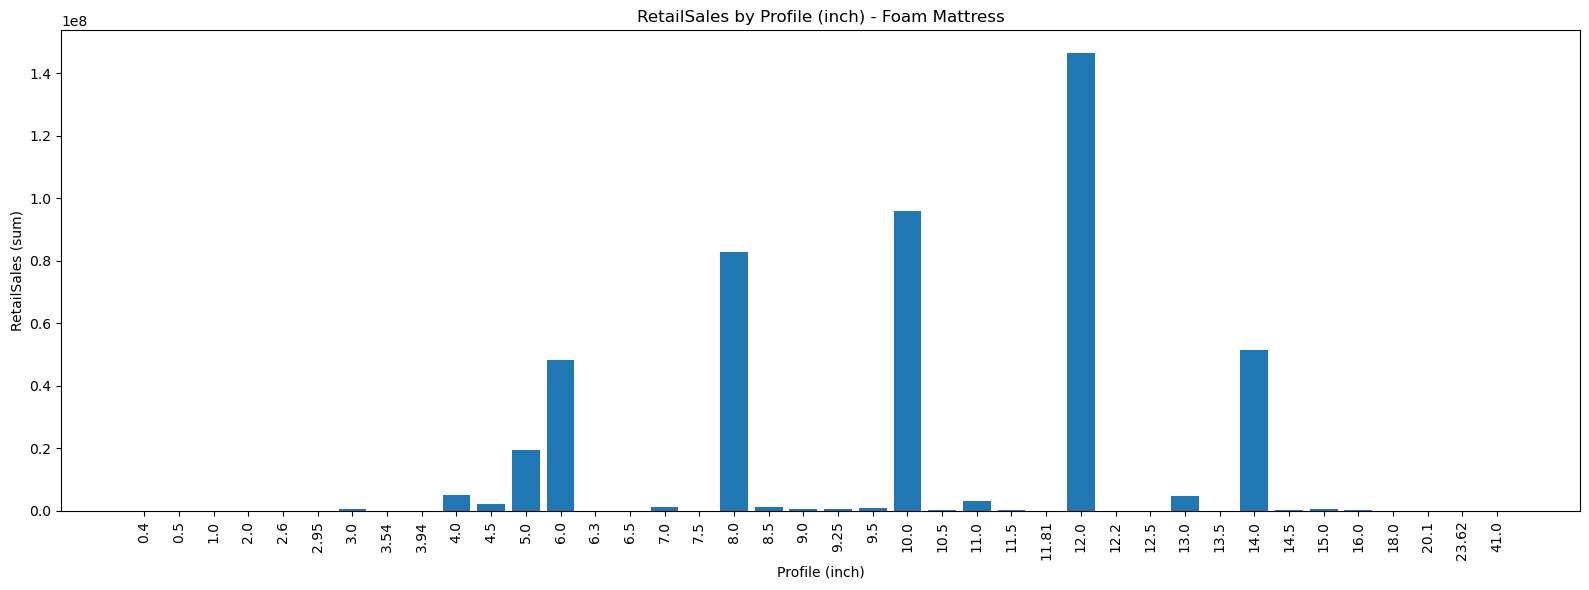

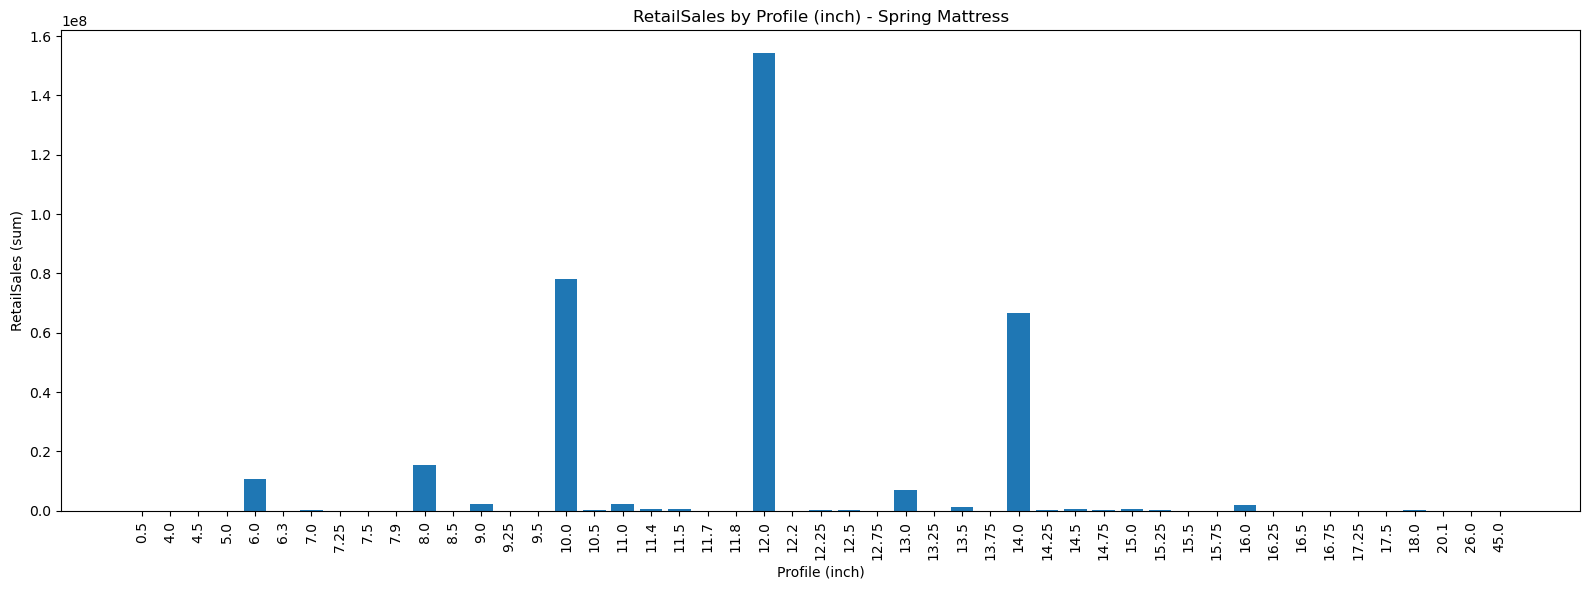

In [167]:

# profile 값 전처리
#df_mattress['profile'] = pd.to_numeric(df_mattress['profile'], errors='coerce')
#df_mattress = df_mattress[df_mattress['profile'].notnull()]

# 각 카테고리별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_2025[df_2025['category'] == cat]

    sales_by_profile = (
        df_cat
        .groupby('profile')['RetailSales']
        .sum()
        .reset_index()
        .sort_values('profile')
    )

    plt.figure(figsize=(16, 6))
    plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
    plt.xlabel('Profile (inch)')
    plt.ylabel('RetailSales (sum)')
    plt.title(f'RetailSales by Profile (inch) - {cat}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### - Size별 매출

In [170]:
df_2025 = df1[df1['year'] == 2025].copy()

In [172]:
size_group = (
    df_2025.groupby('size')
    .agg(sku_count=('RetailerSku','nunique'), total_sales=('RetailSales','sum'))
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

print(size_group)

          size  sku_count   total_sales
5        Queen       2694  3.098964e+08
2         King       1874  1.688741e+08
1         Full       2159  1.612158e+08
6         Twin       2037  1.349056e+08
4       OTHERS       2562  5.810250e+07
7      Twin XL        804  2.038457e+07
0     Cal King        516  1.244793e+07
3  Narrow Twin         91  2.115705e+06


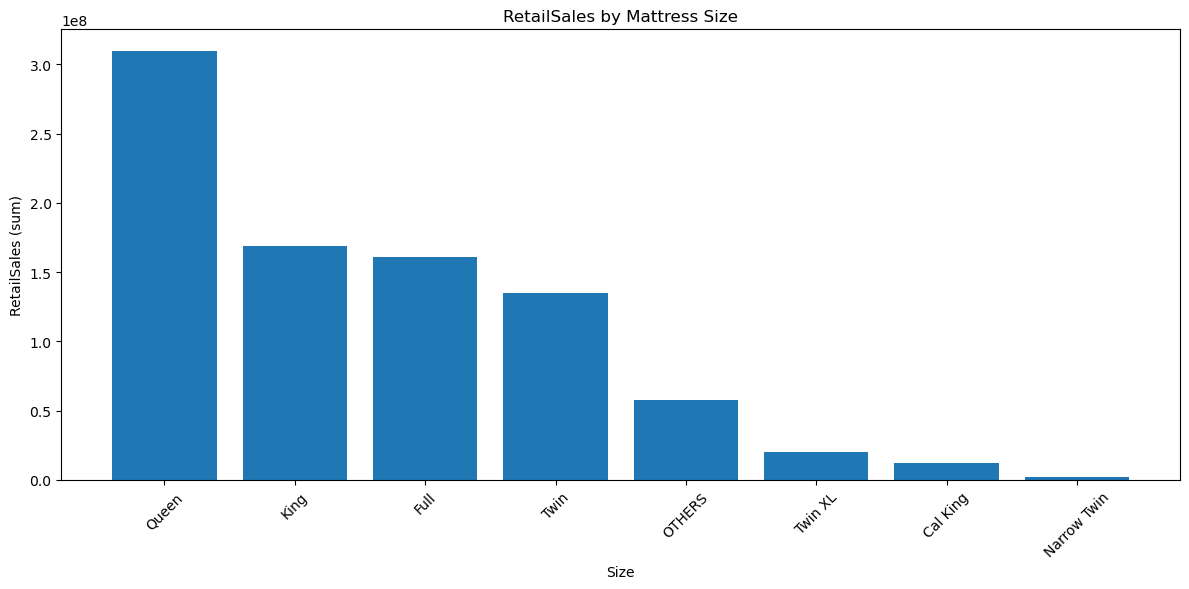

In [174]:
plt.figure(figsize=(12, 6))
plt.bar(size_group['size'].astype(str), size_group['total_sales'])
plt.xlabel('Size')
plt.ylabel('RetailSales (sum)')
plt.title('RetailSales by Mattress Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

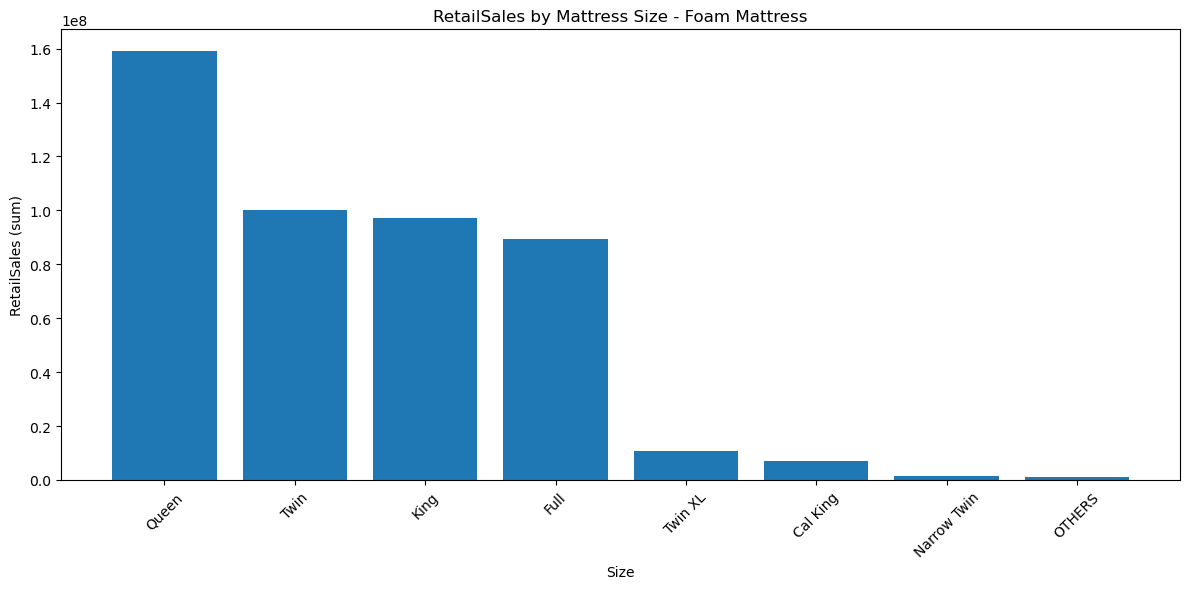

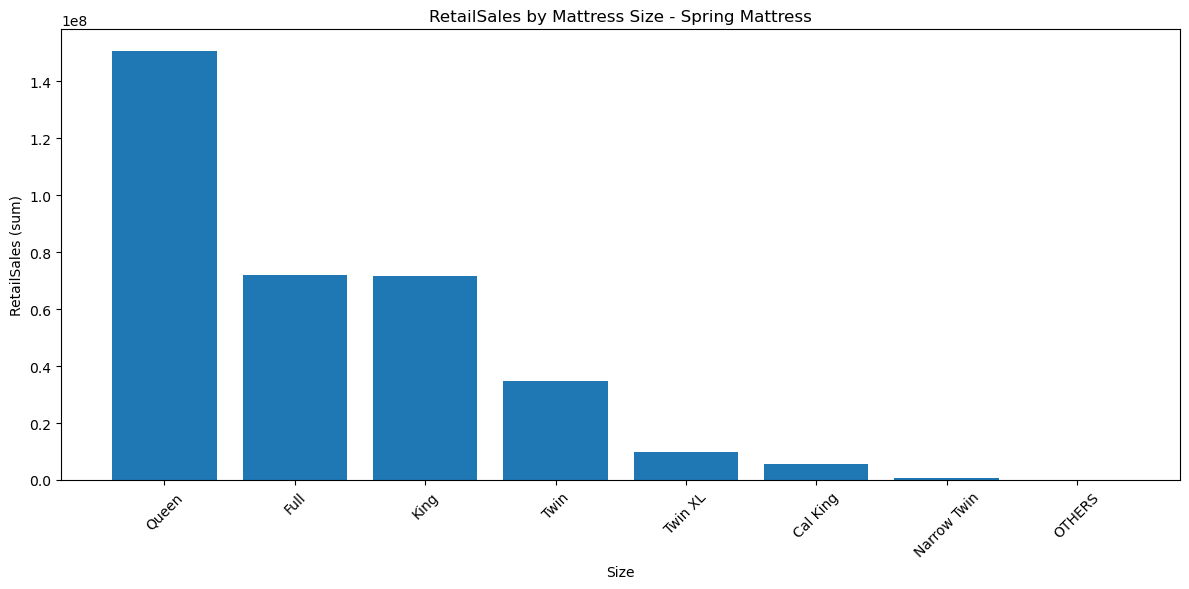

In [176]:
# Foam과 Spring으로 분리해서 처리
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_2025[df_2025['category'] == cat]

    # size별 sku 수와 매출 집계
    size_group = (
        df_cat.groupby('size')
        .agg(sku_count=('RetailerSku', 'nunique'),
             total_sales=('RetailSales', 'sum'))
        .reset_index()
        .sort_values(by='total_sales', ascending=False)
    )

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.bar(size_group['size'].astype(str), size_group['total_sales'])
    plt.xlabel('Size')
    plt.ylabel('RetailSales (sum)')
    plt.title(f'RetailSales by Mattress Size - {cat}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 2. Category 분석

In [41]:
df1 = df_mattress.copy()

In [45]:
print(df1)

       RetailerSku         category    subcategory profile size_raw  size  \
0       B07KNGW8BX  Spring Mattress        Bonnell       8     Full  Full   
1       B07KNGW8BX  Spring Mattress        Bonnell       8     Full  Full   
2       B07KNGW8BX  Spring Mattress        Bonnell       8     Full  Full   
3       B07KNGW8BX  Spring Mattress        Bonnell       8     Full  Full   
4       B07KNGW8BX  Spring Mattress        Bonnell       8     Full  Full   
...            ...              ...            ...     ...      ...   ...   
992154  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10     Twin  Twin   
992155  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10     Twin  Twin   
992156  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10     Twin  Twin   
992157  B0DLGGCVSH  Spring Mattress  Pocket Spring      12     Twin  Twin   
992158  B0DLGGCVSH  Spring Mattress  Pocket Spring      12     Twin  Twin   

       bsr_ctgry_label Brand_raw Brand_adj  \
0       01. Mattresses   SOME

In [47]:
df1.groupby(['year'])['RetailSales'].sum()

year
2019    9.500844e+08
2020    1.144626e+09
2021    1.407931e+09
2022    1.575239e+09
2023    1.750029e+09
2024    1.863939e+09
2025    8.679426e+08
Name: RetailSales, dtype: float64

In [49]:
df1_grp = df1.groupby(['category'], as_index=False)['RetailSales'].sum()
total = df1['RetailSales'].sum()
df1_grp['Ratio'] = df1_grp['RetailSales']/total*100
print(df1_grp)

          category   RetailSales      Ratio
0    Foam Mattress  5.513754e+09  57.676515
1           OTHERS  6.927441e+08   7.246436
2  Spring Mattress  3.353293e+09  35.077049


In [51]:
df1_grp = df1.groupby(['subcategory'], as_index=False)['RetailSales'].sum()
total = df1['RetailSales'].sum()
df1_grp['Ratio'] = df1_grp['RetailSales']/total*100
print(df1_grp)

       subcategory   RetailSales      Ratio
0          Bonnell  7.334930e+08   7.672689
1  Continuous Coil  4.465297e+04   0.000467
2      Cooling/Gel  3.405077e+09  35.618742
3      Non-Cooling  2.108453e+09  22.055432
4           OTHERS  6.927857e+08   7.246871
5    Pocket Spring  2.619937e+09  27.405800


#### 2.1 시장 규모

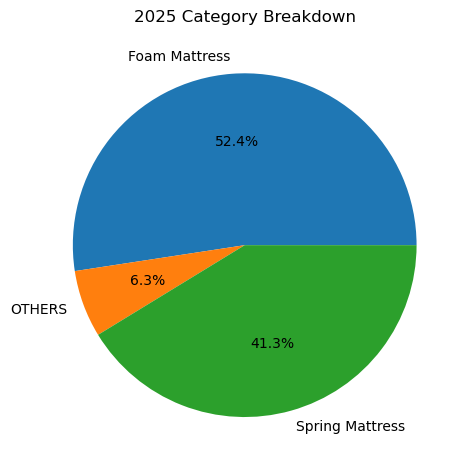

In [58]:
df_2025 = df1[df1['year'] == 2025].copy()
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('category')['RetailSales'].sum()

# 2. Pie Chart
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Category Breakdown')
plt.tight_layout()
plt.show()

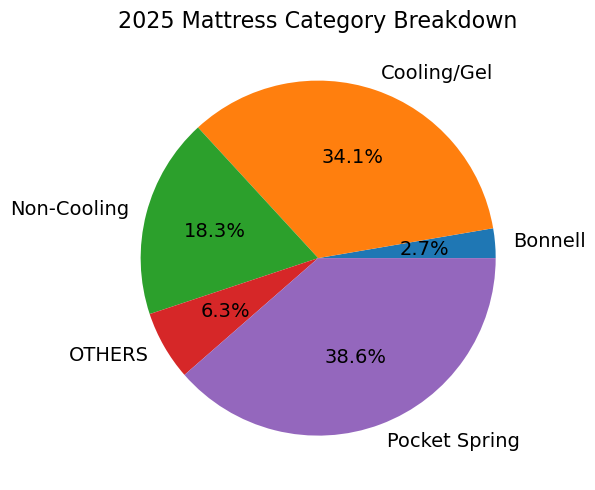

In [62]:
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('subcategory')['RetailSales'].sum()

# 2. 파이 차트 수동 생성 (폰트 크기 조절 가능)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    textprops={'fontsize': 14}  # ✅ 글자 폰트 크기 조절
)

ax.set_title('2025 Mattress Category Breakdown', fontsize=16)
plt.tight_layout()
plt.show()

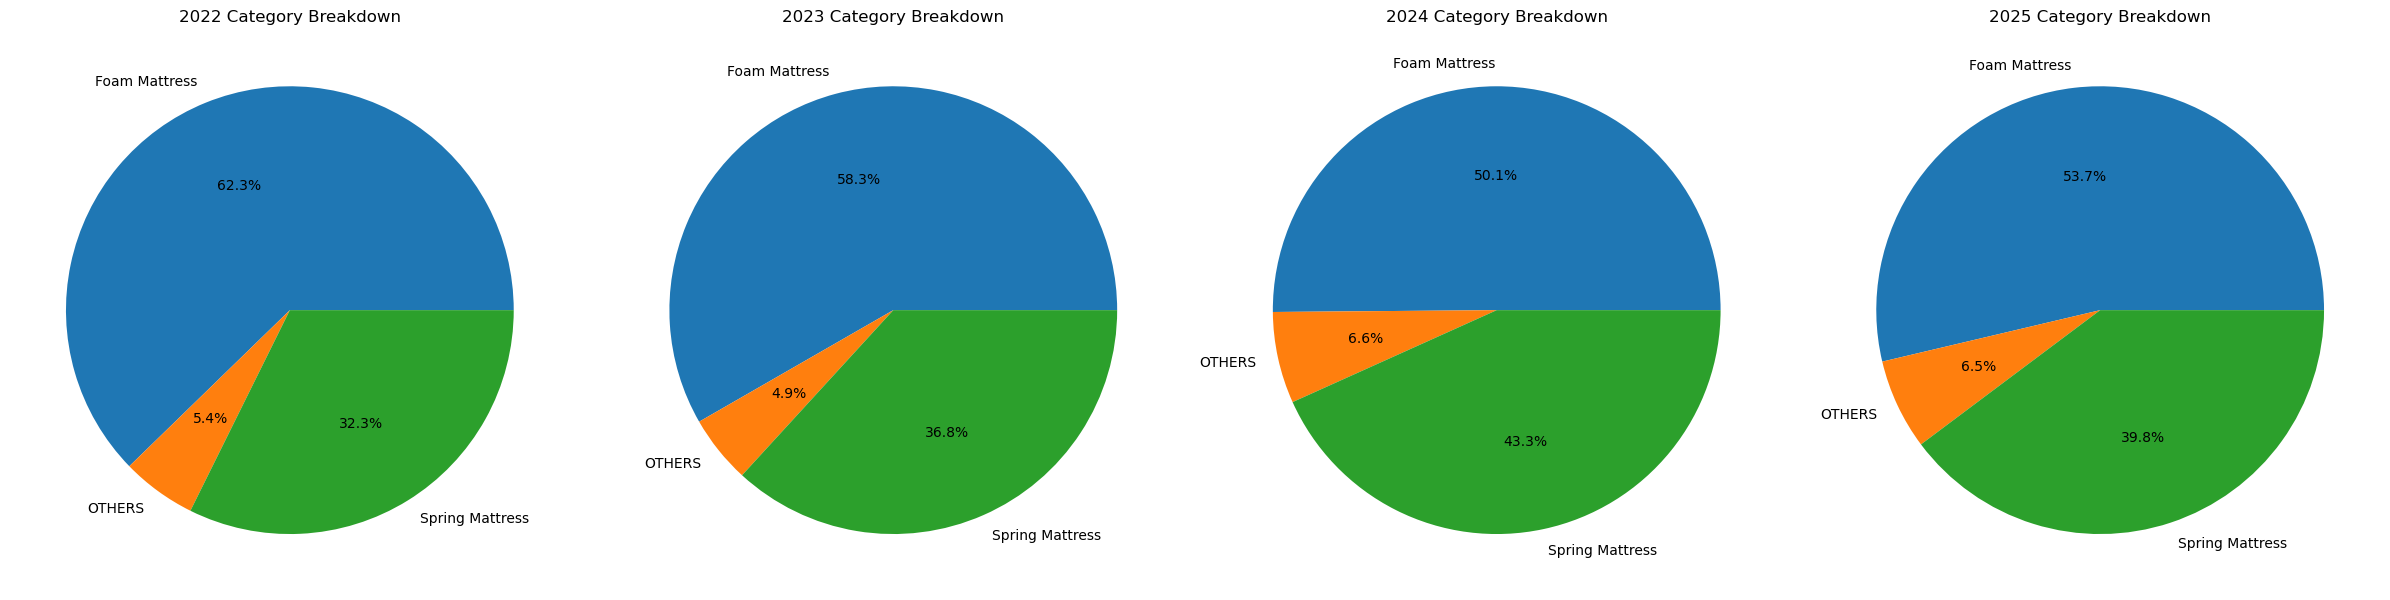

In [63]:
# 1. year 컬럼에서 고유 연도 추출 (정렬 포함) → 최근 4년만 추출
years = sorted(df1['year'].dropna().unique())[-4:]

# 2. subplot 생성
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 6))

# 3. 연도별 반복
for i, year in enumerate(years):
    df_year = df1[df1['year'] == year]
    category_sales = df_year.groupby('category')['RetailSales'].sum()

    # 파이차트 그리기
    category_sales.plot(
        kind='pie',
        autopct='%1.1f%%',
        ylabel='',
        title=f'{year} Category Breakdown',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

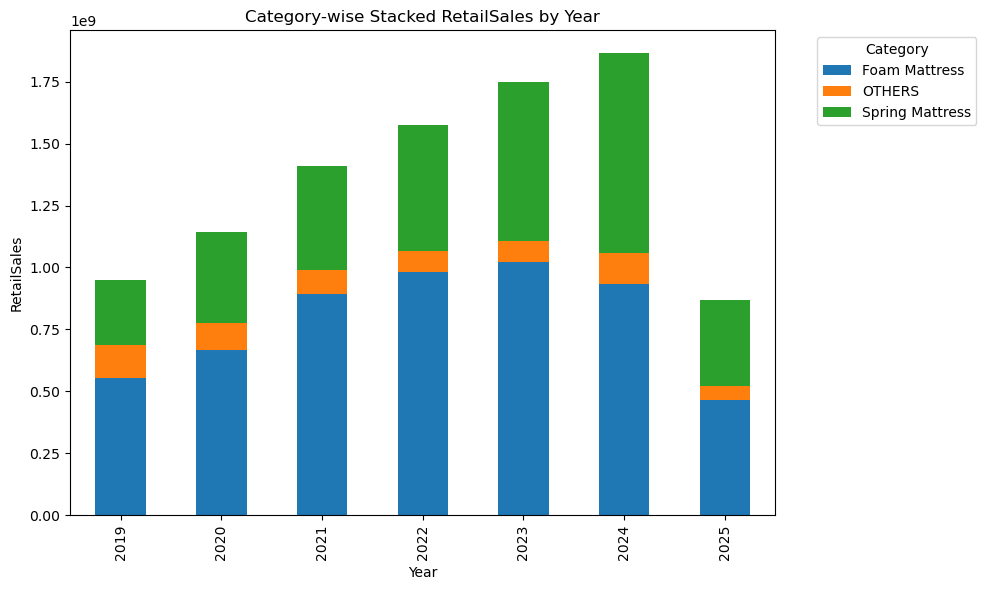

In [61]:
# 1. 연도 리스트 추출
years = sorted(df1['year'].dropna().unique())

# 2. 연도별 category별 매출 합계 집계 (pivot 형태로 변환)
df_grouped = (
    df1.groupby(['year', 'category'])['RetailSales']
       .sum()
       .reset_index()
       .pivot(index='year', columns='category', values='RetailSales')
)

# 결측값은 0으로 채움
df_grouped = df_grouped.fillna(0)

# 3. 누적 막대 그래프 그리기
df_grouped.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Category-wise Stacked RetailSales by Year')
plt.xlabel('Year')
plt.ylabel('RetailSales')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [73]:
df1.groupby('subcategory').agg(
    total_sales = ('RetailSales', 'sum'),
    asin_count = ('RetailerSku','nunique')
).reset_index()

,subcategory,total_sales,asin_count
0,Bonnell,7.334930e+08,593
1,Continuous Coil,4.465297e+04,1
2,Cooling/Gel,3.405077e+09,8263
3,Non-Cooling,2.108453e+09,4321
4,OTHERS,6.927857e+08,14390
5,Pocket Spring,2.619937e+09,10036


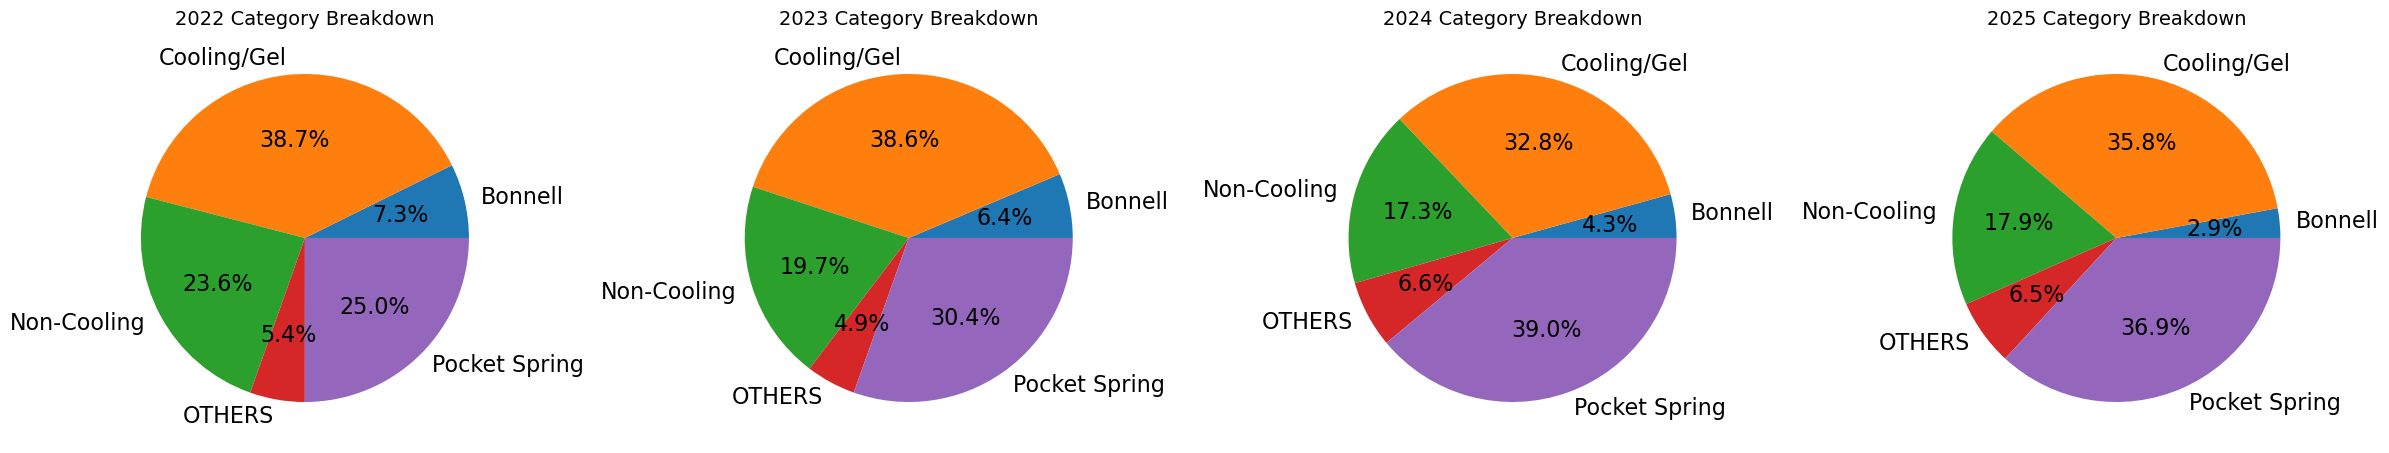

In [93]:
# 1. year 컬럼에서 고유 연도 추출 (정렬 포함) → 최근 4년만 추출
years = sorted(df1['year'].dropna().unique())[-4:]

# 2. subplot 생성
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 6))

# 3. 연도별 반복
for i, year in enumerate(years):
    df_year = df1[(df1['year'] == year) & (df1['subcategory'] != 'Continuous Coil')]

    category_sales = df_year.groupby('subcategory')['RetailSales'].sum()

    # 파이차트 수동 그리기 (글자 크기 조절)
    axes[i].pie(
        category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%',
        textprops={'fontsize': 16}  # ✅ 글자 크기 조절
    )
    axes[i].set_title(f'{year} Category Breakdown', fontsize=14)

plt.tight_layout()
plt.show()

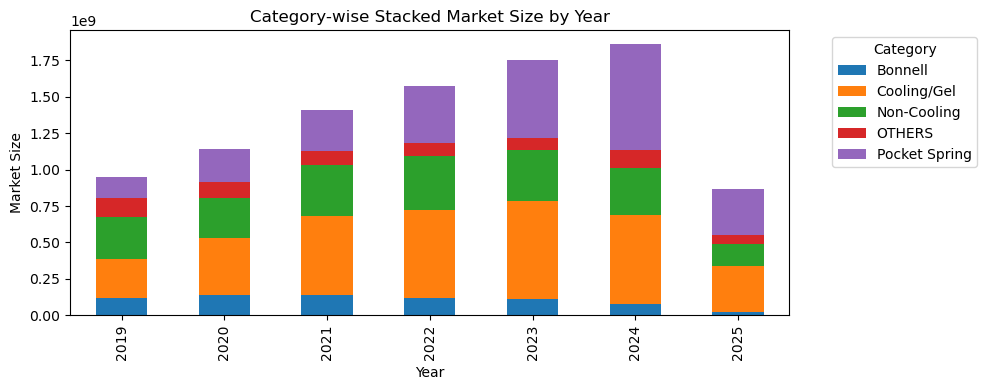

In [99]:
# 1. 연도 리스트 추출
years = sorted(df1['year'].dropna().unique())

# 'Continuous Coil' 제외한 데이터만 필터링
df_filtered = df1[df1['subcategory'] != 'Continuous Coil']

# 2. 연도별 category별 매출 합계 집계 (pivot 형태로 변환)
df_grouped = (
    df_filtered.groupby(['year', 'subcategory'])['RetailSales']
       .sum()
       .reset_index()
       .pivot(index='year', columns='subcategory', values='RetailSales')
)

# 결측값은 0으로 채움
df_grouped = df_grouped.fillna(0)

# 3. 누적 막대 그래프 그리기
df_grouped.plot(kind='bar', stacked=True, figsize=(10, 4))

plt.title('Category-wise Stacked Market Size by Year')
plt.xlabel('Year')
plt.ylabel('Market Size')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

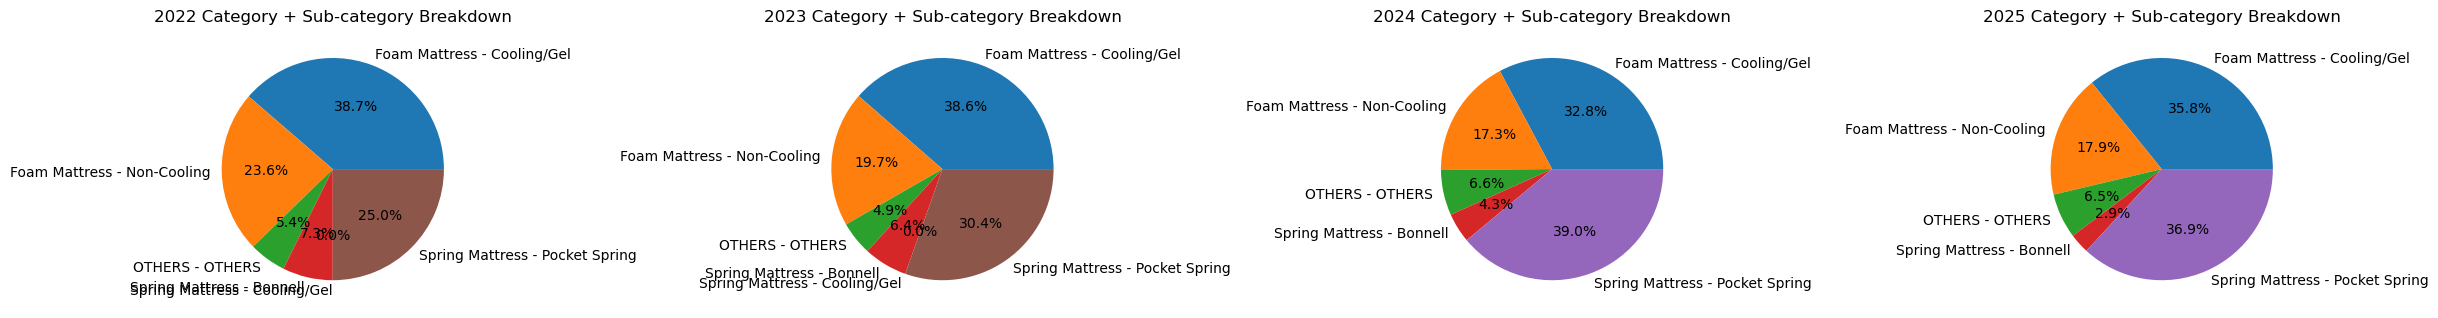

In [81]:
# 1. 최근 4년 추출
years = sorted(df1['year'].dropna().unique())[-4:]

# 2. subplot 생성
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 6))

# 3. 연도별 반복
for i, year in enumerate(years):
    df_year = df1[
        (df1['year'] == year) &
        (df1['subcategory'] != 'Continuous Coil')
    ].copy()

    # 카테고리 + 서브카테고리 결합
    df_year['cat_subcat'] = df_year['category'] + ' - ' + df_year['subcategory']

    # 매출 합계 집계
    category_sales = df_year.groupby('cat_subcat')['RetailSales'].sum()

    # 파이차트 그리기
    category_sales.plot(
        kind='pie',
        autopct='%1.1f%%',
        ylabel='',
        title=f'{year} Category + Sub-category Breakdown',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

#### - 영역 차트

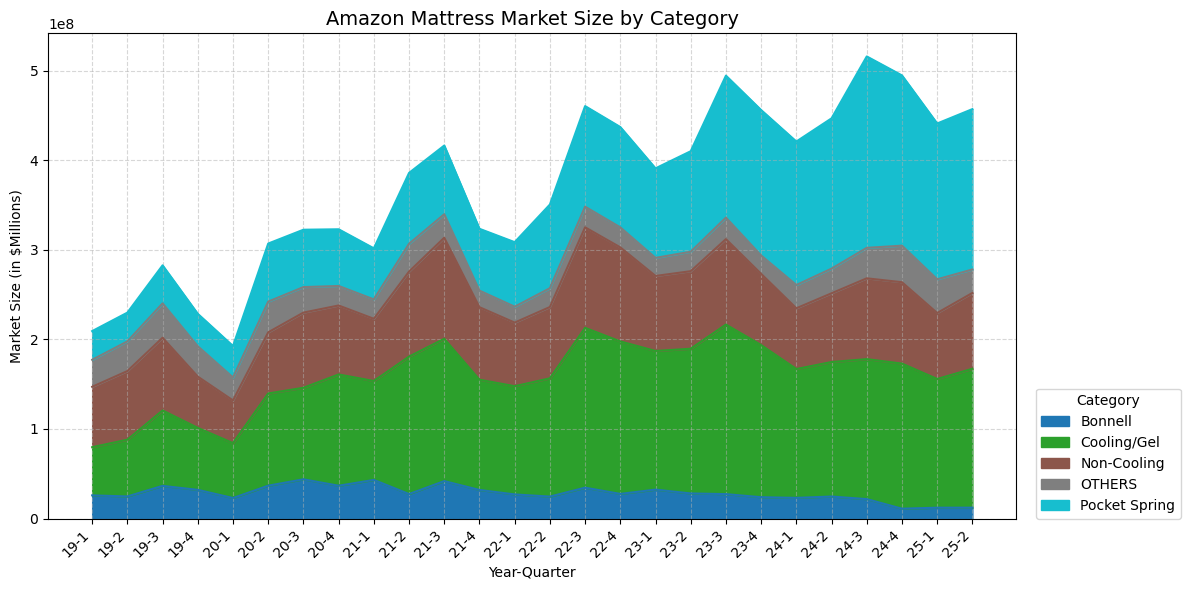

In [69]:
# 1. 'Continuous Coil'과 '25-3' 제외
df_filtered = df1[
    (df1['subcategory'].str.lower() != 'continuous coil') &
    (df1['yr_quarter'] != '25-3')
]

# 2. 분기별 subcategory 매출 집계
df_grouped = (
    df_filtered.groupby(['yr_quarter', 'subcategory'])['RetailSales']
    .sum()
    .unstack()
    .fillna(0)
)

# 3. 그래프 그리기
fig, ax = plt.subplots(figsize=(12, 6))
df_grouped.plot(kind='area', stacked=True, colormap='tab10', ax=ax)

# 4. x축 전체 레이블 표시
ax.set_xticks(range(len(df_grouped.index)))
ax.set_xticklabels(df_grouped.index, rotation=45, ha='right')

# 5. 제목 및 축 라벨
ax.set_title('Amazon Mattress Market Size by Category', fontsize=14)
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Market Size (in $Millions)')

# ✅ 범례 오른쪽 바깥 + 아래 정렬
ax.legend(
    title='Category',
    loc='lower left',              # 기준 위치: 왼쪽 아래
    bbox_to_anchor=(1.02, 0.0),    # 오른쪽 밖으로 이동, 하단 정렬
    borderaxespad=0
)

# 6. 격자
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2.2 지누스 점유율

In [26]:
df1 = df_mattress.copy()

In [34]:
df_2025_zinus = df1[(df1['year'] == 2025) & (df1['Brand_raw'] == 'ZINUS')].copy()

In [36]:
df_2025_zinus['RetailSales'].sum()

177357479.01

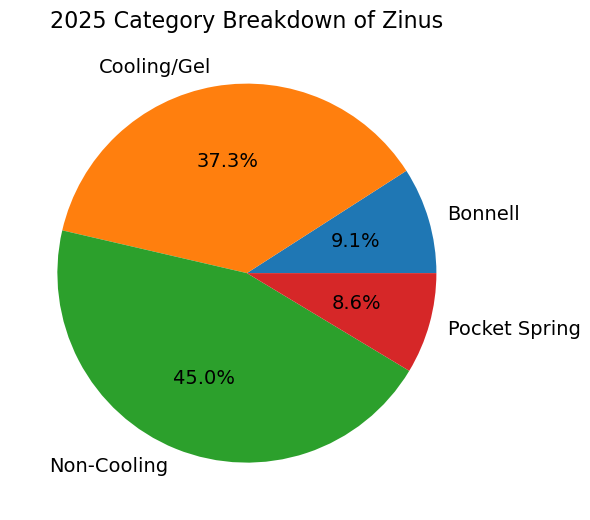

In [66]:
# 1. OTHERS 제외 후 매출 합계
category_sales = (
    df_2025_zinus[df_2025_zinus['subcategory'] != 'OTHERS']
    .groupby('subcategory')['RetailSales']
    .sum()
)

# 2. Pie Chart
plt.figure(figsize=(6, 6))
category_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel='',
    #title='2025 Category Breakdown of ZINUS',
    textprops={'fontsize': 14}  # ✅ 폰트 크기 조정
)

plt.title('2025 Category Breakdown of Zinus', fontsize=16, loc='center')  # ✅ 제목 폰트 크기
plt.tight_layout()
plt.show()

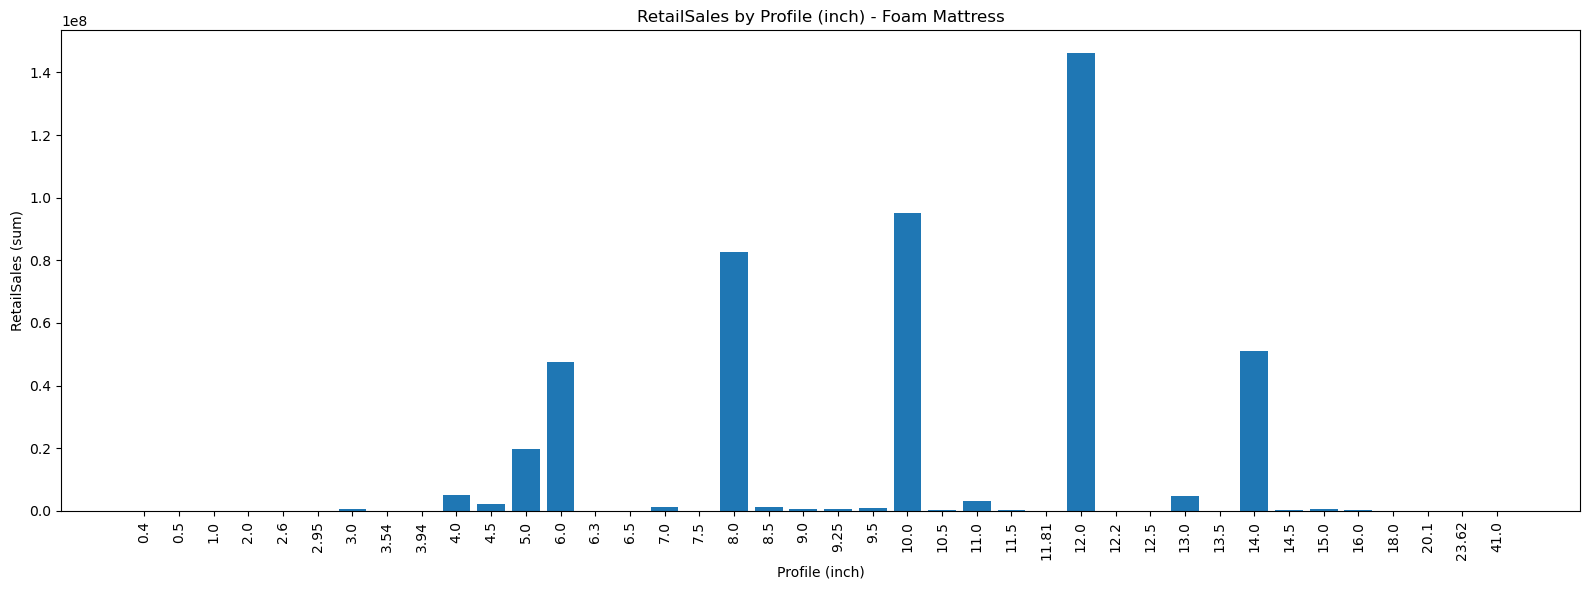

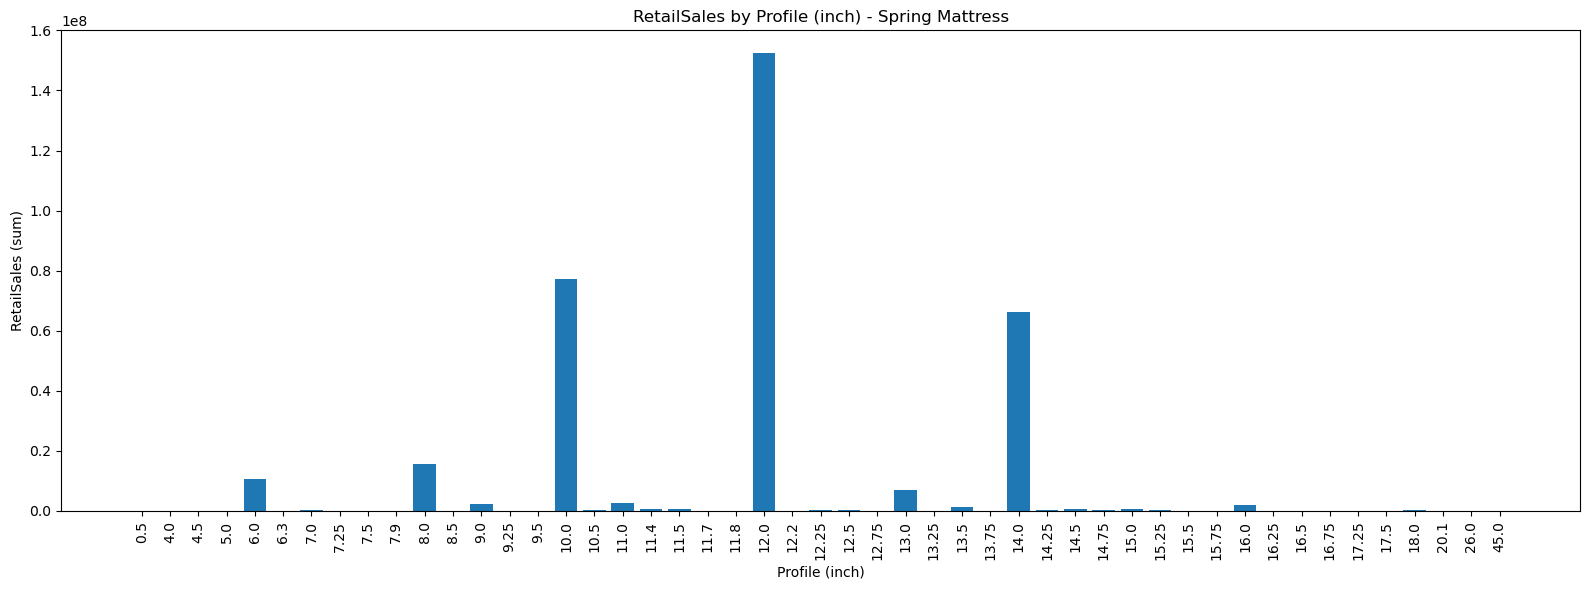

In [281]:
# 2025년 데이터 필터링
df_mattress = df1[df1['year']==2025].copy()

# profile 값 전처리
df_mattress['profile'] = pd.to_numeric(df_mattress['profile'], errors='coerce')
df_mattress = df_mattress[df_mattress['profile'].notnull()]

# 각 카테고리별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_mattress[df_mattress['category'] == cat]

    sales_by_profile = (
        df_cat
        .groupby('profile')['RetailSales']
        .sum()
        .reset_index()
        .sort_values('profile')
    )

    plt.figure(figsize=(16, 6))
    plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
    plt.xlabel('Profile (inch)')
    plt.ylabel('RetailSales (sum)')
    plt.title(f'RetailSales by Profile (inch) - {cat}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### 3. Price 분석

#### 3.1 가격 분석 (KDE)

In [21]:
df1 = df_mattress.copy()

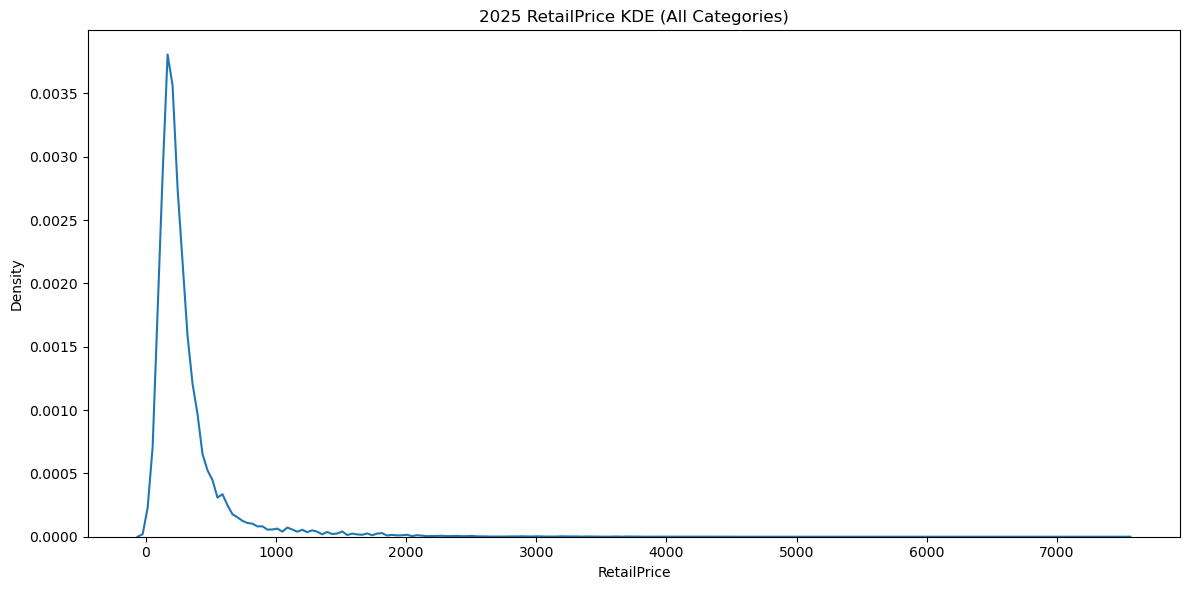

In [23]:
# 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025]

plt.figure(figsize=(12, 6))

# KDE 플롯 (log 변환 없이)
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
sns.kdeplot(prices, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE (All Categories)')
plt.tight_layout()
plt.show()

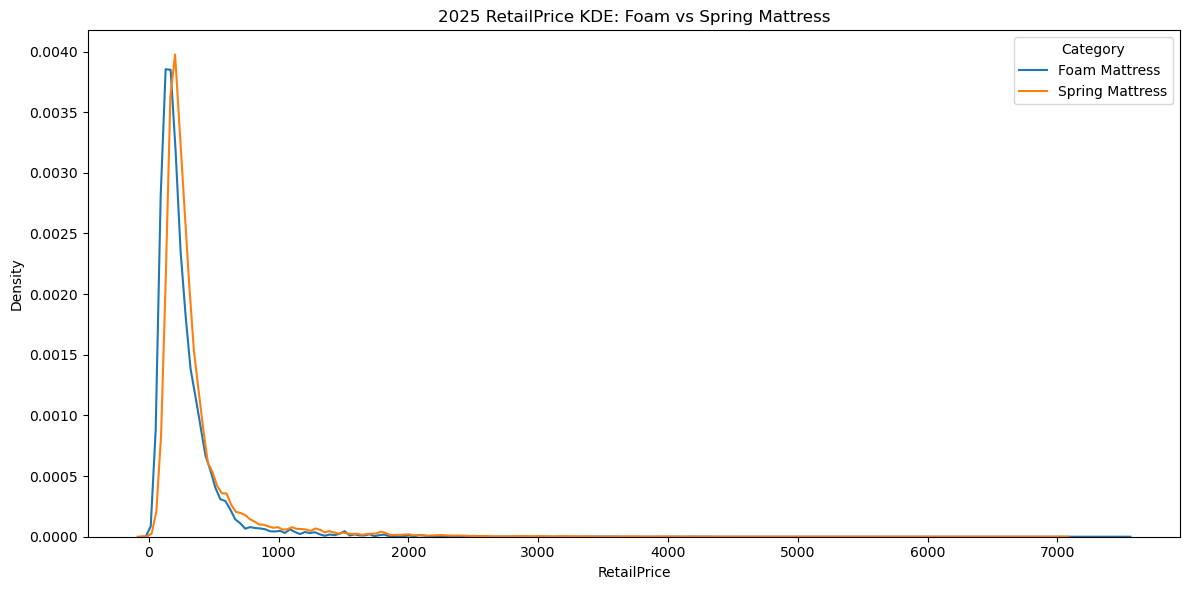

In [25]:
# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df_2025[df_2025['category'].isin(target_cats)]

plt.figure(figsize=(12, 6))

# Foam/Spring 각각 KDE 그리기 (로그 변환 없이)
for cat in target_cats:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    sns.kdeplot(prices, label=cat, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE: Foam vs Spring Mattress')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

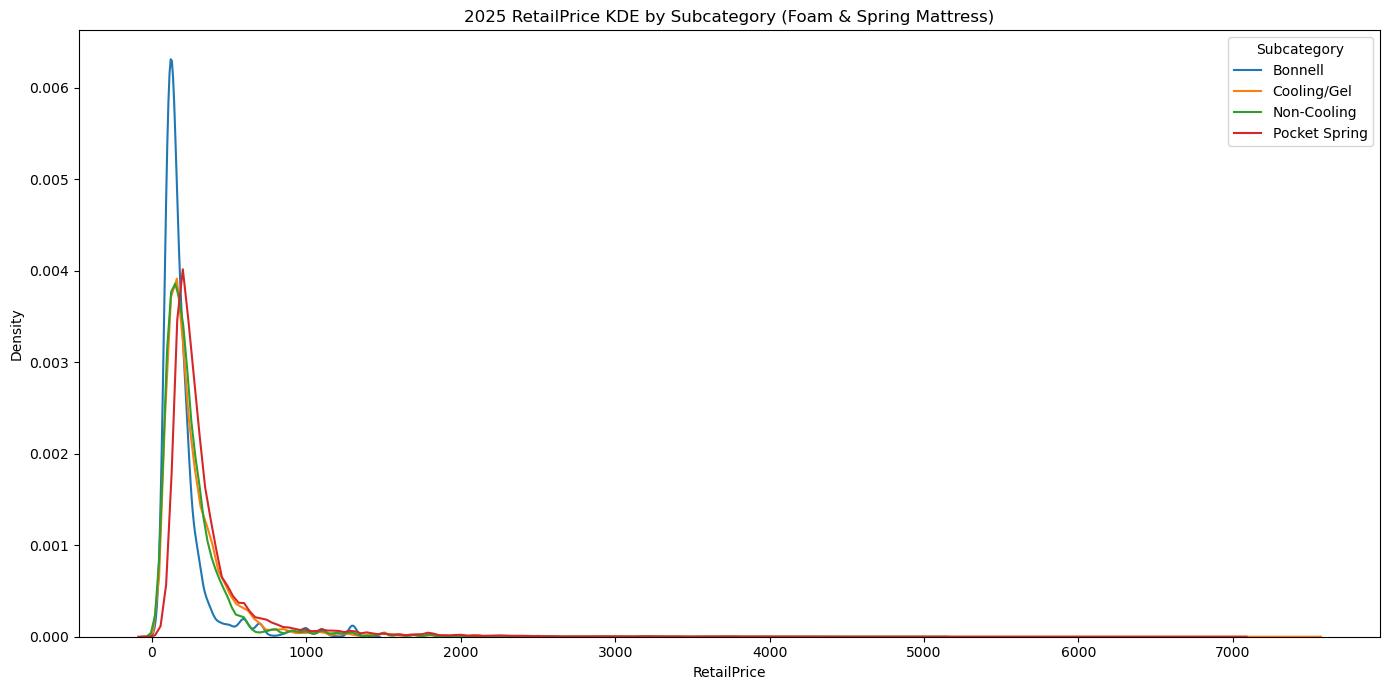

In [27]:
# 분석 대상 subcategory 목록 자동 추출
subcats = sorted(df_2025['subcategory'].dropna().unique())

plt.figure(figsize=(14, 7))

# subcategory별 KDE 그리기 (로그 변환 없이)
for subcat in subcats:
    prices = df_2025[df_2025['subcategory'] == subcat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    if not prices.empty:
        sns.kdeplot(prices, label=subcat, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE by Subcategory (Foam & Spring Mattress)')
plt.legend(title='Subcategory')
plt.tight_layout()
plt.show()

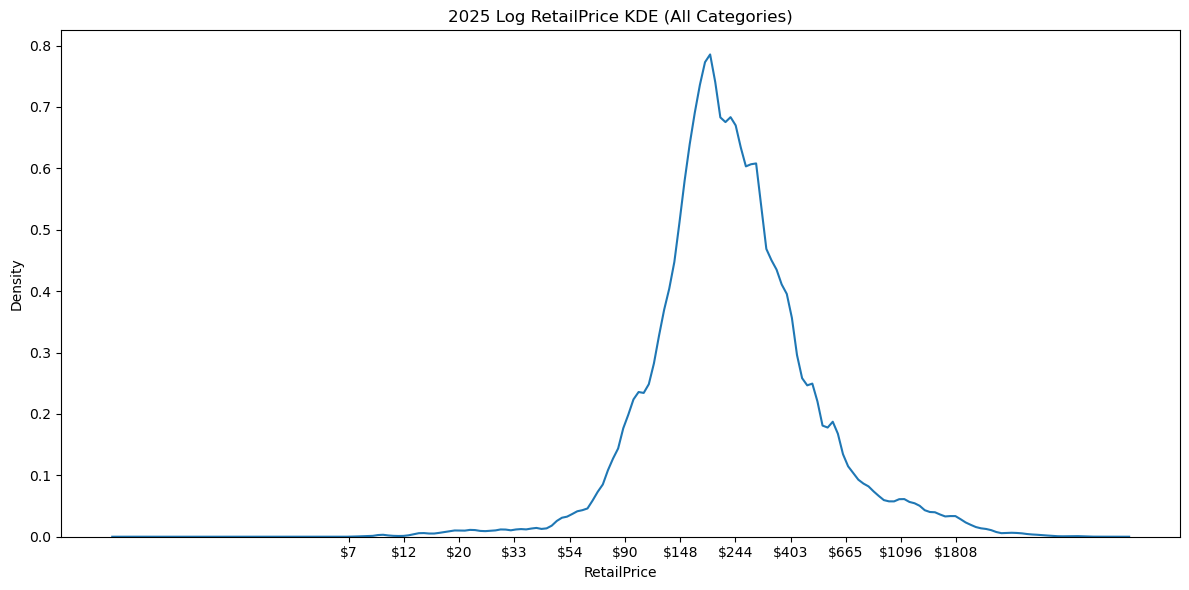

In [105]:
# 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025]

plt.figure(figsize=(12, 6))

# KDE 플롯
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
log_prices = np.log(prices)
sns.kdeplot(log_prices, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE (All Categories)')
plt.tight_layout()
plt.show()

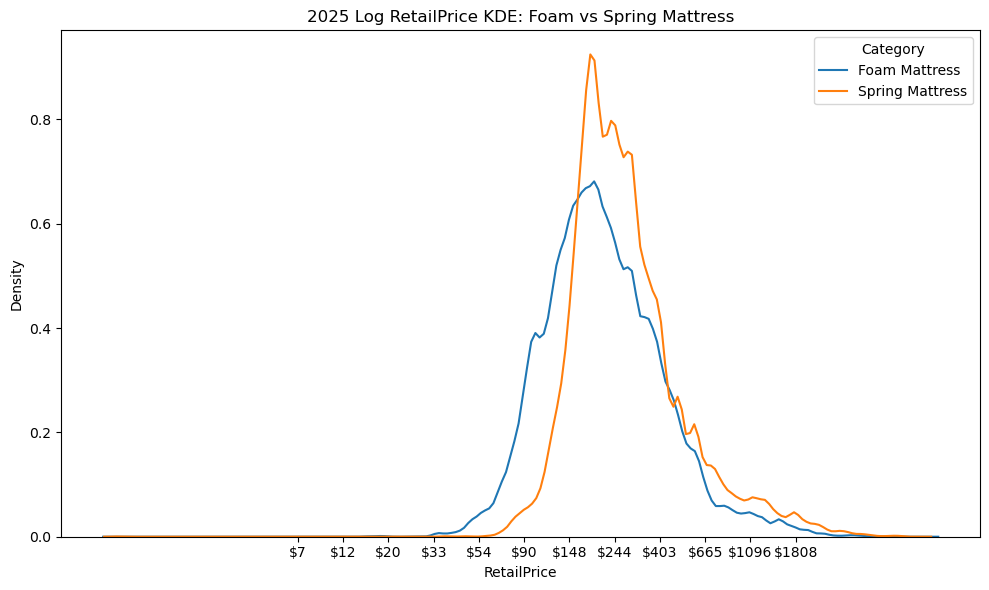

In [49]:
# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df_2025[df_2025['category'].isin(target_cats)]

plt.figure(figsize=(10, 6))

# Foam/Spring 각각 KDE 그리기
for cat in target_cats:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=cat, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE: Foam vs Spring Mattress')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

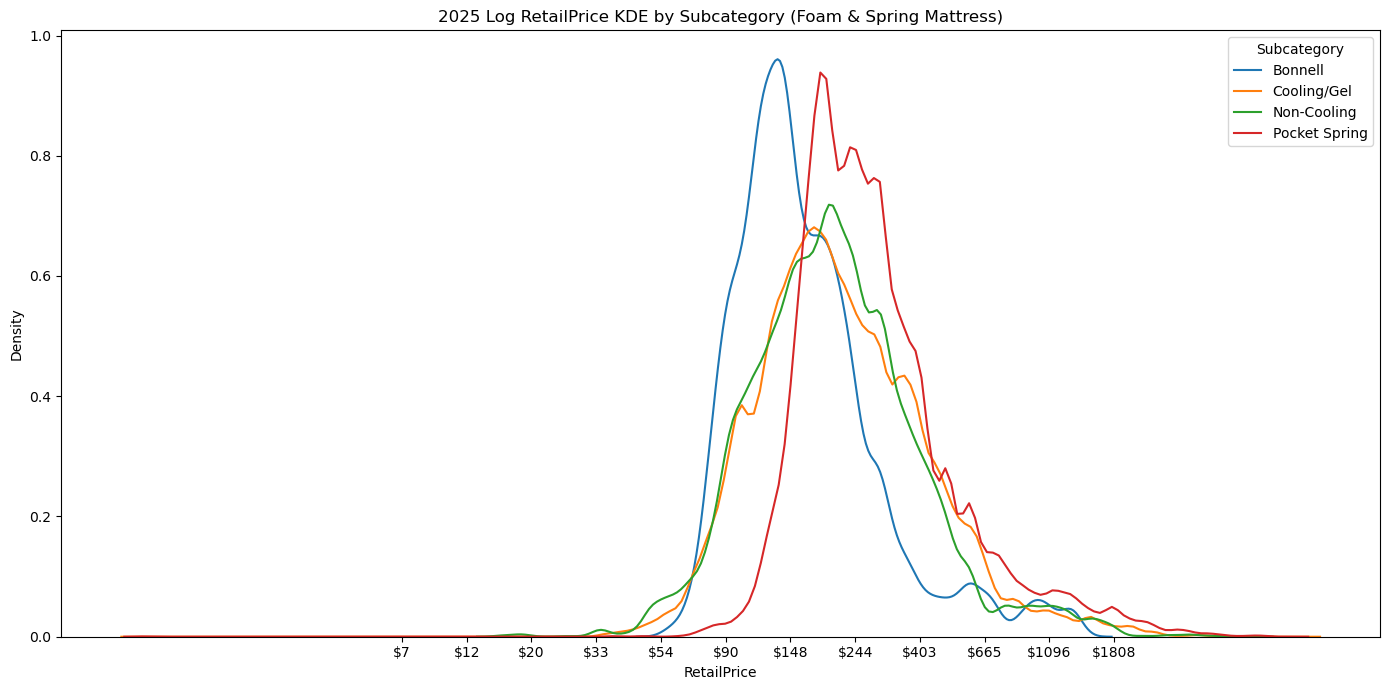

In [33]:
# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df_2025[df_2025['category'].isin(target_cats)]

# subcategory 목록 추출 및 정렬
subcats = sorted(df_2025['subcategory'].dropna().unique())

plt.figure(figsize=(14, 7))

# subcategory별 KDE (로그 변환)
for subcat in subcats:
    prices = df_2025[df_2025['subcategory'] == subcat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    if not prices.empty:
        log_prices = np.log(prices)
        sns.kdeplot(log_prices, label=subcat, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # 필요시 범위 조정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]
plt.xticks(xticks, xtick_labels)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE by Subcategory (Foam & Spring Mattress)')
plt.legend(title='Subcategory')
plt.tight_layout()
plt.show()

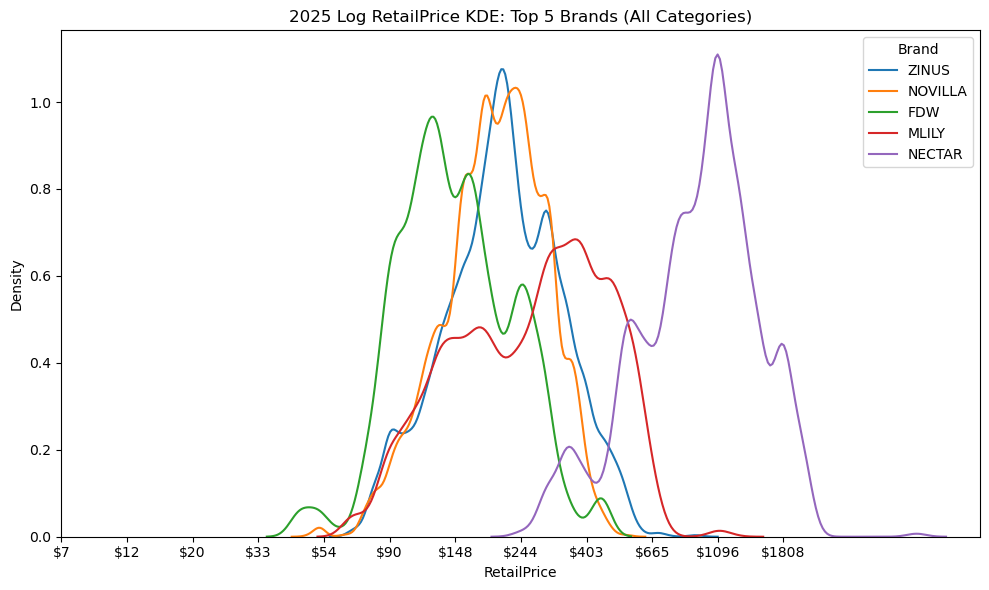

In [55]:
# 2025년 전체(카테고리 구분 없이) 데이터
df_2025 = df1[df1['year'] == 2025]

# 매출 기준 Top 5 브랜드 추출 (카테고리 상관없이)
top_brands = (
    df_2025.groupby('Brand_raw')['RetailSales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

plt.figure(figsize=(10, 6))

# Top 5 브랜드별 로그 가격 KDE
for brand in top_brands:
    prices = df_2025[df_2025['Brand_raw'] == brand]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    if not prices.empty:
        log_prices = np.log(prices)
        sns.kdeplot(log_prices, label=brand, bw_adjust=0.7)

# X축: 실제 가격 주요값으로 표시
xticks = np.arange(2, 8, 0.5)
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]
plt.xticks(xticks, xtick_labels)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE: Top 5 Brands (All Categories)')
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

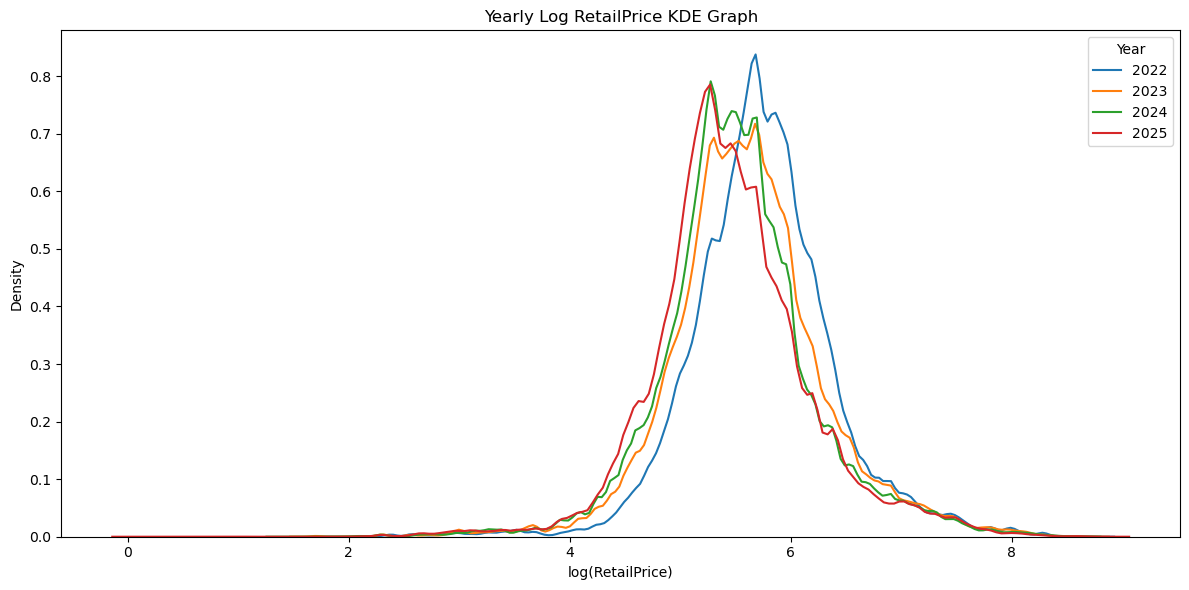

In [53]:
plt.figure(figsize=(12, 6))

# 2022~2025년만 필터링
years_to_plot = [2022, 2023, 2024, 2025]
df_filtered = df1[df1['year'].isin(years_to_plot)]

# 년도별 반복
for year, group in df_filtered.groupby('year'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=year, bw_adjust=0.7)


plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('Yearly Log RetailPrice KDE Graph')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [122]:
int(np.exp(5.5))

244

#### - Half Violin Plot

In [23]:
df_2025 = df1[df1['year'] == 2025].copy()

In [25]:
df_2025.head(5)

,RetailerSku,category,subcategory,profile,size_raw,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
1,B0CQD3CMXN,Spring Mattress,Bonnell,6,Twin,Twin,01. Mattresses,AC PACIFIC,AC PACIFIC,AC Pacific Pure 6 Inch Firm Mattress with Bonn...,...,5,88.98,25-1,25-02,Y25 W09,Y25 W09,7.861180e+06,105343.54,2025,25-H1
2,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,3,324.10,25-1,25-01,Y25 W03,Y25 W03,4.408013e+08,17525453.16,2025,25-H1
5,B07BNRS5V6,Spring Mattress,Bonnell,8,T,Twin,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,7,179.99,25-1,25-01,Y25 W04,Y25 W04,4.408013e+08,17525453.16,2025,25-H1
9,B0D69QW86M,Spring Mattress,Bonnell,6,F,Full,01. Mattresses,AVENCO,NOVILLA FAMILY,"Avenco 6 Inch Full Mattress, Medium Soft, Brea...",...,7,123.99,25-2,25-06,Y25 W24,Y25 W24,5.820650e+08,79607655.48,2025,25-H1
10,B0D73R3V7K,Spring Mattress,Bonnell,6,Q,Queen,01. Mattresses,AVENCO,NOVILLA FAMILY,"Avenco 6 Inch Queen Size Mattress, Foam and Sp...",...,1,129.99,25-2,25-05,Y25 W18,Y25 W18,5.820650e+08,79607655.48,2025,25-H1


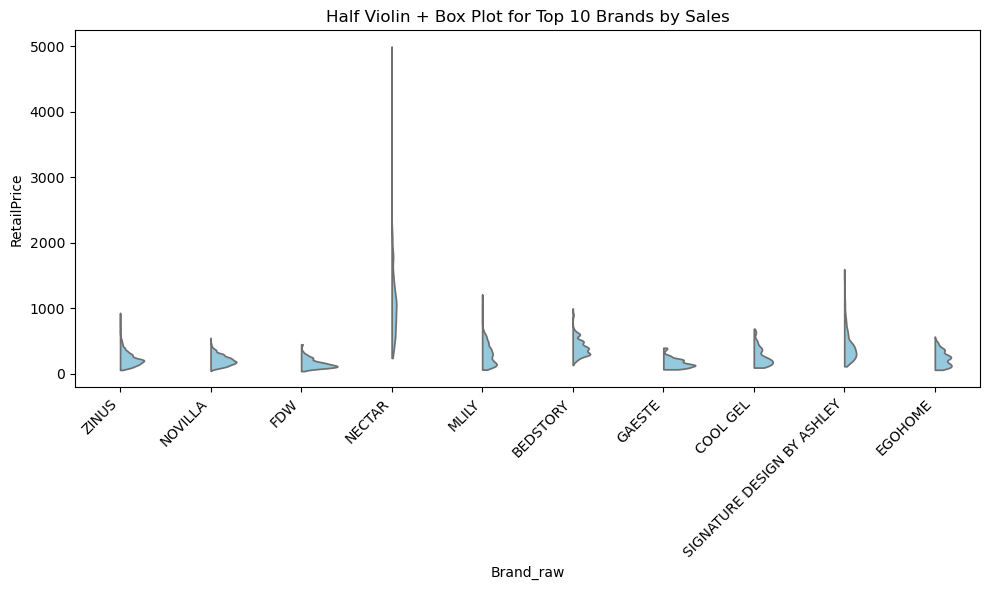

In [36]:
# 1. Brand별 매출 합계 계산
brand_sales = (
    df_2025.groupby('Brand_raw')['RetailSales']
    .sum()
    .reset_index()
    .sort_values(by='RetailSales', ascending=False)
)

# 2. Top 10 브랜드 추출
top_brands = brand_sales.head(10)['Brand_raw'].tolist()

# 3. Top 브랜드 데이터 필터링
df_top = df_2025[df_2025['Brand_raw'].isin(top_brands)]

# Half Violin Plot + Box Plot 함께 표시
plt.figure(figsize=(10, 6))

# Half Violin (오른쪽 절반)
parts = sns.violinplot(
    x="Brand_raw", y="RetailPrice", data=df_top,
    order=top_brands, cut=0, inner=None, color="skyblue"
)

# 오른쪽 절반만 남기기
for pc in parts.collections:
    paths = pc.get_paths()
    for p in paths:
        v = p.vertices
        mean_x = np.mean(v[:, 0])
        v[:, 0] = np.clip(v[:, 0], mean_x, np.max(v[:, 0]))


plt.xticks(rotation=45, ha='right')
plt.title("Half Violin + Box Plot for Top 10 Brands by Sales")
plt.tight_layout()
plt.show()

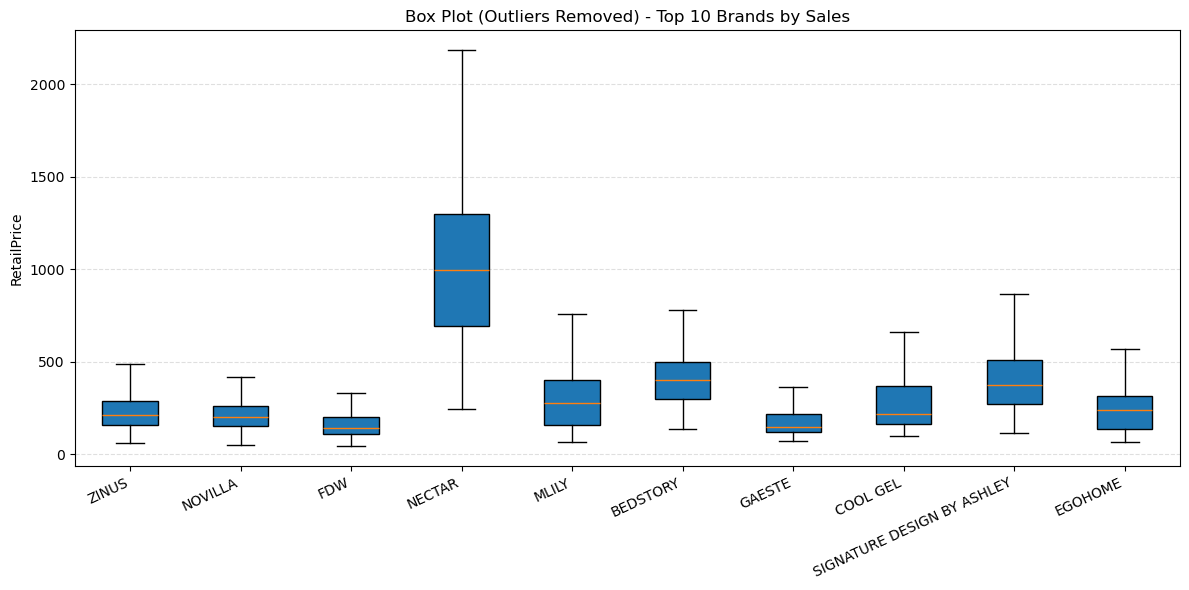

브랜드별 RetailPrice 중위수:
ZINUS: 212.84
NOVILLA: 202.95
FDW: 143.40
NECTAR: 999.00
MLILY: 279.99
BEDSTORY: 399.66
GAESTE: 149.98
COOL GEL: 217.99
SIGNATURE DESIGN BY ASHLEY: 374.35
EGOHOME: 239.99


In [29]:
# ===== Top 10 브랜드 & datasets 생성 =====
brand_sales = (
    df_2025.groupby('Brand_raw')['RetailSales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_brands = brand_sales.index.tolist()

datasets = [df_2025.loc[df_2025['Brand_raw'] == b, 'RetailPrice'].values for b in top_brands]
positions = np.arange(1, len(top_brands) + 1)

# ===== BoxPlot =====
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(
    datasets,
    positions=positions,
    widths=0.5,
    vert=True,
    showfliers=False,  # 이상치 제거
    patch_artist=True
)

ax.set_xticks(positions)
ax.set_xticklabels(top_brands, rotation=25, ha='right')
ax.set_ylabel("RetailPrice")
ax.set_title("Box Plot (Outliers Removed) - Top 10 Brands by Sales")
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ===== 중위수 계산 & 출력 =====
medians = {brand: np.median(prices) for brand, prices in zip(top_brands, datasets)}
print("브랜드별 RetailPrice 중위수:")
for brand, median in medians.items():
    print(f"{brand}: {median:.2f}")

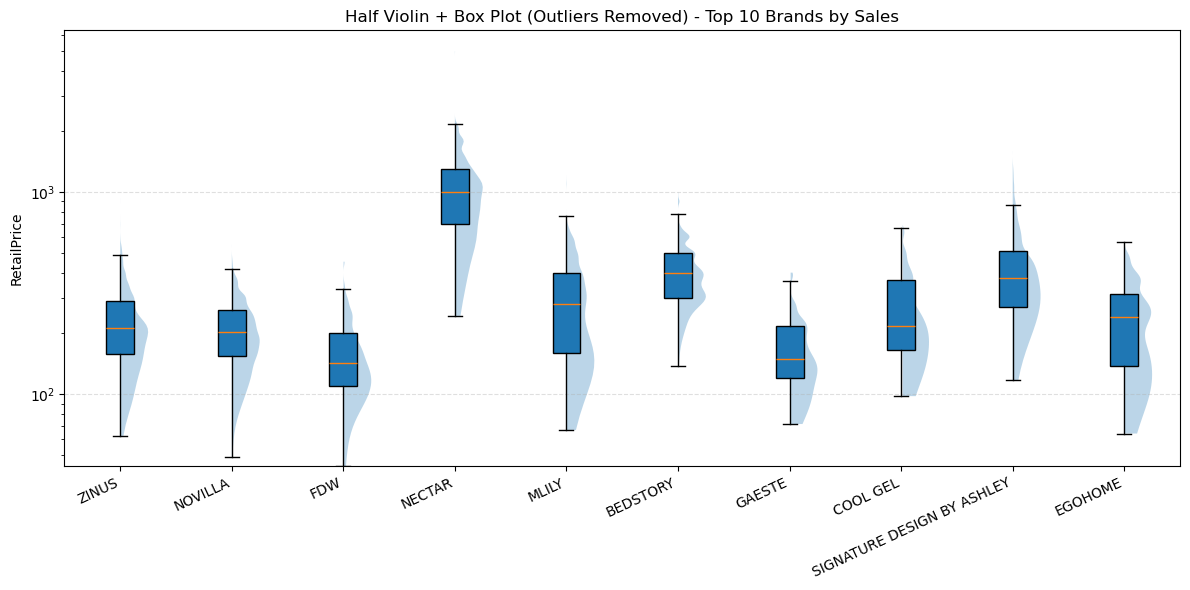

In [60]:


# ===== Top 10 브랜드 & datasets 생성 =====
brand_sales = (
    df_2025.groupby('Brand_raw')['RetailSales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_brands = brand_sales.index.tolist()

datasets = [df_2025.loc[df_2025['Brand_raw'] == b, 'RetailPrice'].values for b in top_brands]
positions = np.arange(1, len(top_brands) + 1)

# y축 상한 (상위 99.5퍼센타일)
all_prices = df_2025.loc[df_2025['Brand_raw'].isin(top_brands), 'RetailPrice'].values
y_max = np.percentile(all_prices, 99.5)

# ===== Half Violin + BoxPlot (이상치 제거) =====
fig, ax = plt.subplots(figsize=(12, 6))

# Half Violin
viol = ax.violinplot(
    datasets,
    positions=positions,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for body in viol['bodies']:
    verts = body.get_paths()[0].vertices
    center_x = np.median(verts[:, 0])
    verts[:, 0] = np.clip(verts[:, 0], center_x, verts[:, 0].max())

# Box Plot (이상치 점 제거)
bp = ax.boxplot(
    datasets,
    positions=positions,
    widths=0.25,
    vert=True,
    showfliers=False,   # 이상치 제거
    patch_artist=True
)

ax.set_xticks(positions)
ax.set_xticklabels(top_brands, rotation=25, ha='right')
ax.set_ylabel("RetailPrice")
ax.set_title("Half Violin + Box Plot (Outliers Removed) - Top 10 Brands by Sales")

ax.set_yscale('log')
ax.set_ylim(bottom=max(10, all_prices.min()))
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

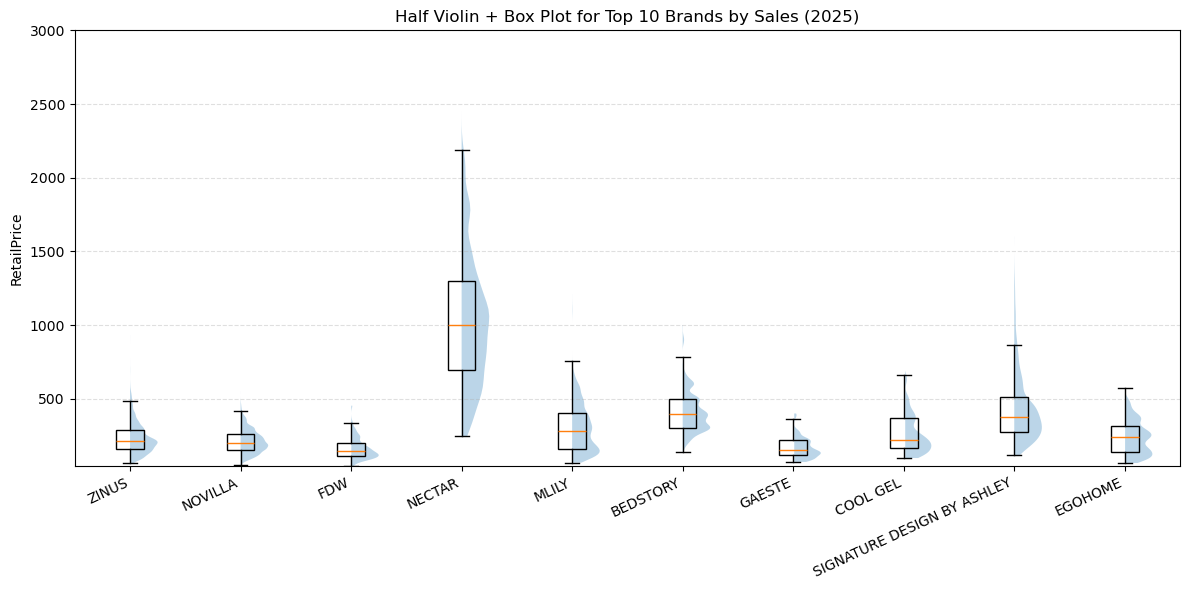

In [76]:
# ===== Half Violin + BoxPlot (이상치 제거, 로그 변환 없음) =====
fig, ax = plt.subplots(figsize=(12, 6))

# Half Violin
viol = ax.violinplot(
    datasets,
    positions=positions,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for body in viol['bodies']:
    verts = body.get_paths()[0].vertices
    center_x = np.median(verts[:, 0])
    verts[:, 0] = np.clip(verts[:, 0], center_x, verts[:, 0].max())

# Box Plot (이상치 점 제거)
bp = ax.boxplot(
    datasets,
    positions=positions,
    widths=0.25,
    vert=True,
    showfliers=False,
    patch_artist=True,                  # 박스 채우기 허용
    boxprops={'facecolor': 'none'}       # 내부 색 제거
)

ax.set_xticks(positions)
ax.set_xticklabels(top_brands, rotation=25, ha='right')
ax.set_ylabel("RetailPrice")
ax.set_title("Half Violin + Box Plot for Top 10 Brands by Sales (2025)")

# 로그 변환 제거, 전체 범위 표시
ax.set_ylim(bottom=max(10, all_prices.min()), top=3000)
#ax.set_ylim(bottom=max(10, all_prices.min()), top=all_prices.max())

ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

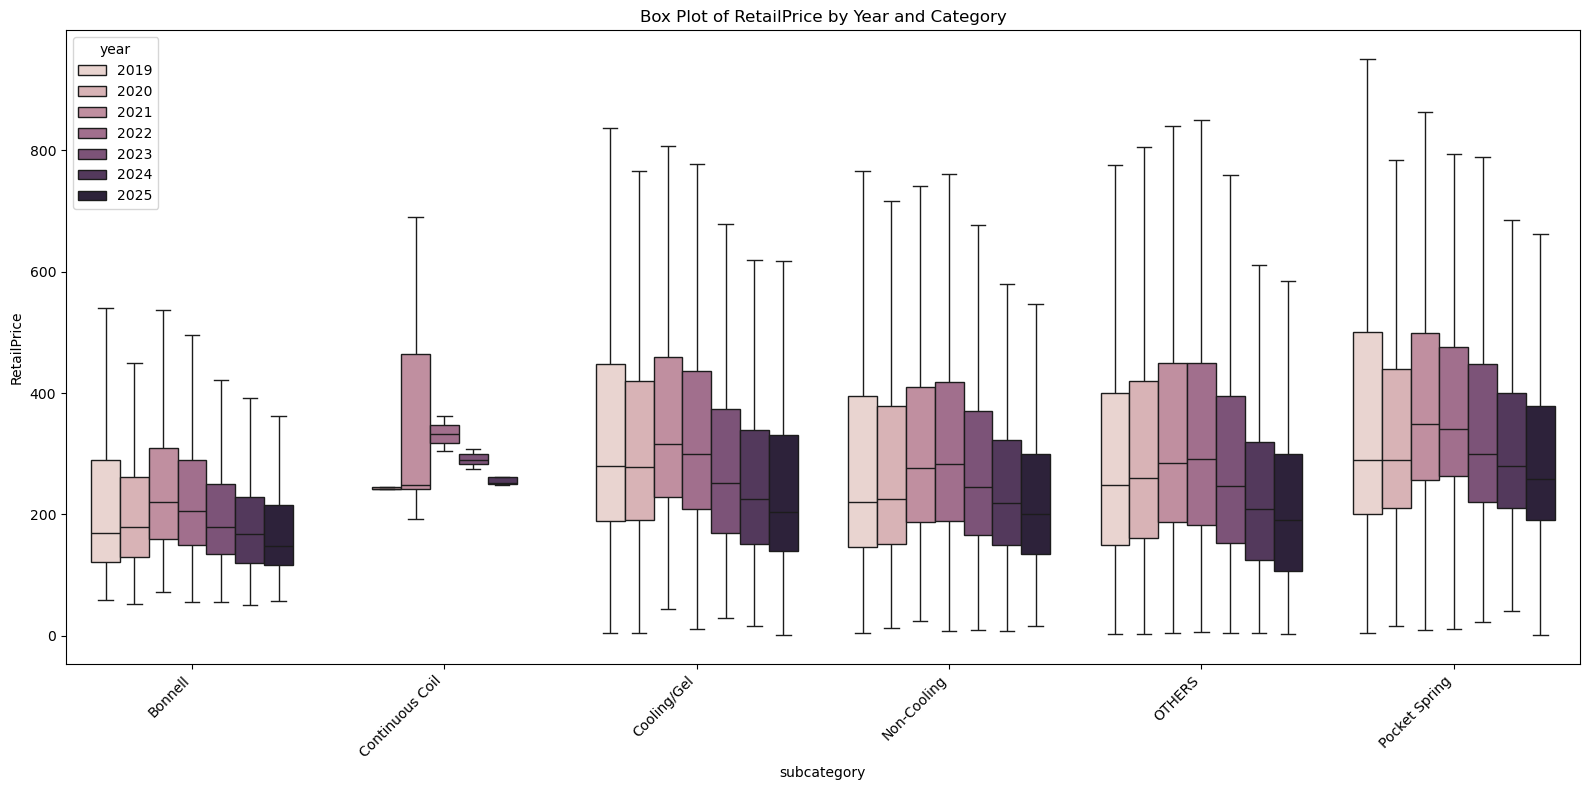

In [190]:
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df1[df1['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='year',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of RetailPrice by Year and Category')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='year')
plt.show()

#### 3.2 고정 가격대별 시장 크기 

In [70]:
df1 = df_mattress.copy()

In [72]:
df1.head(5)

,RetailerSku,category,subcategory,profile,size_raw,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07TGF1KHC,Spring Mattress,Bonnell,9,Twin,Twin,01. Mattresses,MAYTON,MAYTON,9-Inch Medium Firm Tight top Innerspring Fully...,...,1,187.99,22-4,22-10,Y22 W41,Y22 W41,1.179975e+06,101024.19,2022,22-H2
1,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,149,209.94,20-2,20-04,Y20 W14,Y20 W14,4.408013e+08,17525453.16,2020,20-H1
2,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,29,185.25,20-4,20-12,Y20 W49,Y20 W49,4.408013e+08,17525453.16,2020,20-H2
3,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,5,299.99,21-4,21-10,Y21 W40,Y21 W40,4.408013e+08,17525453.16,2021,21-H2
4,B07BNS7M21,Spring Mattress,Bonnell,8,K,King,01. Mattresses,SIGNATURE DESIGN BY ASHLEY,ASHLEY FAMILY,Ashley Chime 8 Inch Firm Hybrid Mattress - Cer...,...,3,290.50,19-3,19-08,Y19 W32,Y19 W32,4.408013e+08,17525453.16,2019,19-H2


In [86]:
df1['yr_week'].max()

'Y25 W31'

In [82]:
# 1) 2025년 + OTHERS 제외
df_filtered = df1[df1['year'] == 2025].copy()

# 2) Price Bin 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = ["1~69.99", "70~99.99", "100~149.99", "150~199.99",
              "200~249.99", "250~299.99", "300~399.99", "400~499.99",
              "500~599.99", "600+"]

# 3) 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4) Price Bin별 매출합 + 비율
sales_by_bin = (
    df_filtered.groupby('PriceBin', observed=True)['RetailSales']
    .sum()
    .reindex(bin_labels)
    .fillna(0)
)

total_sales = sales_by_bin.sum()
share = (sales_by_bin / total_sales).fillna(0)

# 5) Million 단위로 변환
result = (
    pd.DataFrame({
        'RetailSales(M)': (sales_by_bin / 1_000_000).round(2),  # 백만 단위
        'Share(%)': (share * 100).round(2)
    })
    .reset_index()
    .rename(columns={'index': 'PriceBin'})
)

result['PriceBin'] = pd.Categorical(result['PriceBin'], categories=bin_labels, ordered=True)
result = result.sort_values('PriceBin').reset_index(drop=True)

print(result)
result.to_csv('result_0808.csv')

     PriceBin  RetailSales(M)  Share(%)
0     1~69.99           11.81      1.06
1    70~99.99           86.45      7.77
2  100~149.99          153.44     13.79
3  150~199.99          235.68     21.19
4  200~249.99          143.55     12.91
5  250~299.99          134.56     12.10
6  300~399.99          135.20     12.15
7  400~499.99           72.03      6.48
8  500~599.99           48.99      4.40
9        600+           90.65      8.15


C:\Users\최태욱\AppData\Local\Temp\ipykernel_39448\31092706.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBin')['RetailSales']


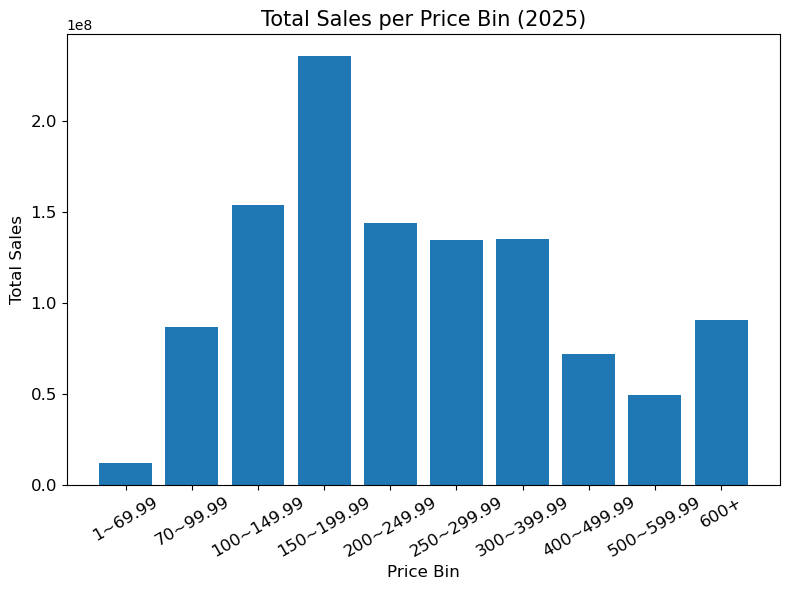

In [74]:
# 1. 2025년 + OTHERS 제외
df_filtered = df1[df1['year'] == 2025].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,   # 왼쪽 포함, 오른쪽 미포함 (1~50은 1 <= x < 50)
    include_lowest=True
)

# 4. Price Bin별 매출 합계 집계
sales_by_bin = (
    df_filtered.groupby('PriceBin')['RetailSales']
    #df_filtered.groupby('PriceBin')['UnitsSold']
    .sum()
    .reindex(bin_labels)  # 빈 구간도 포함
)

# 5. 히스토그램(막대그래프) 시각화
plt.figure(figsize=(8,6))
plt.bar(sales_by_bin.index, sales_by_bin.values)
plt.xlabel("Price Bin", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.title("Total Sales per Price Bin (2025)", fontsize=15)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)   
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\278389721.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby('PriceBin')['RetailSales']


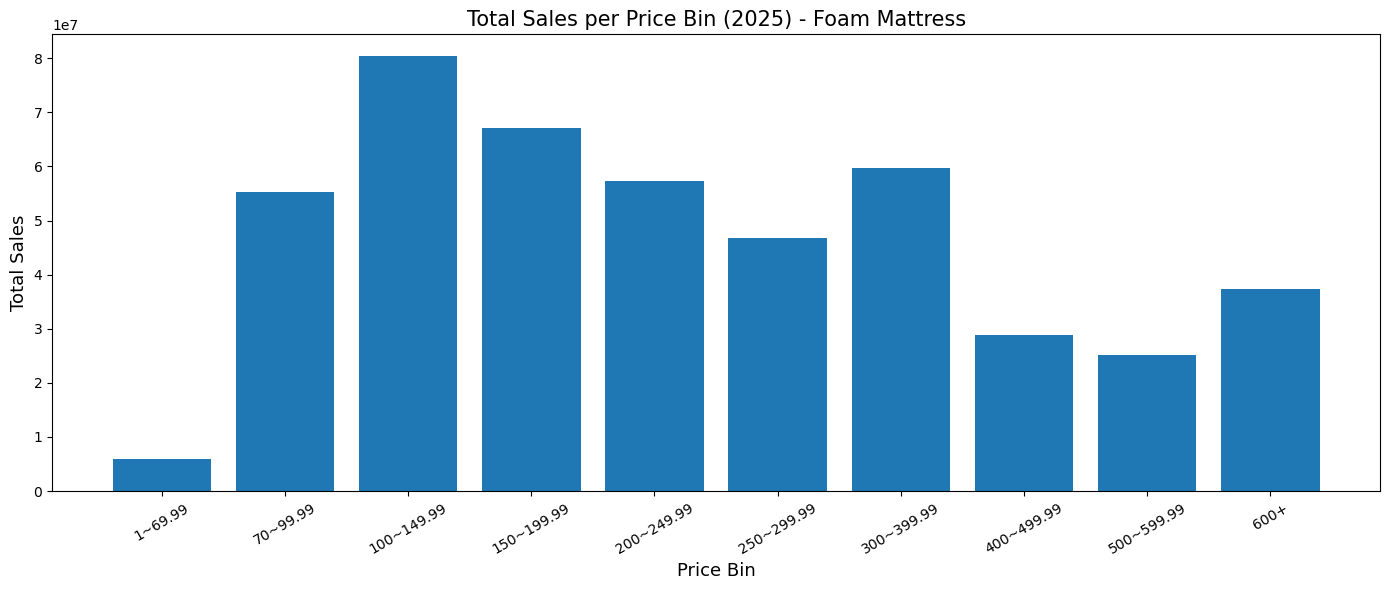

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\278389721.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby('PriceBin')['RetailSales']


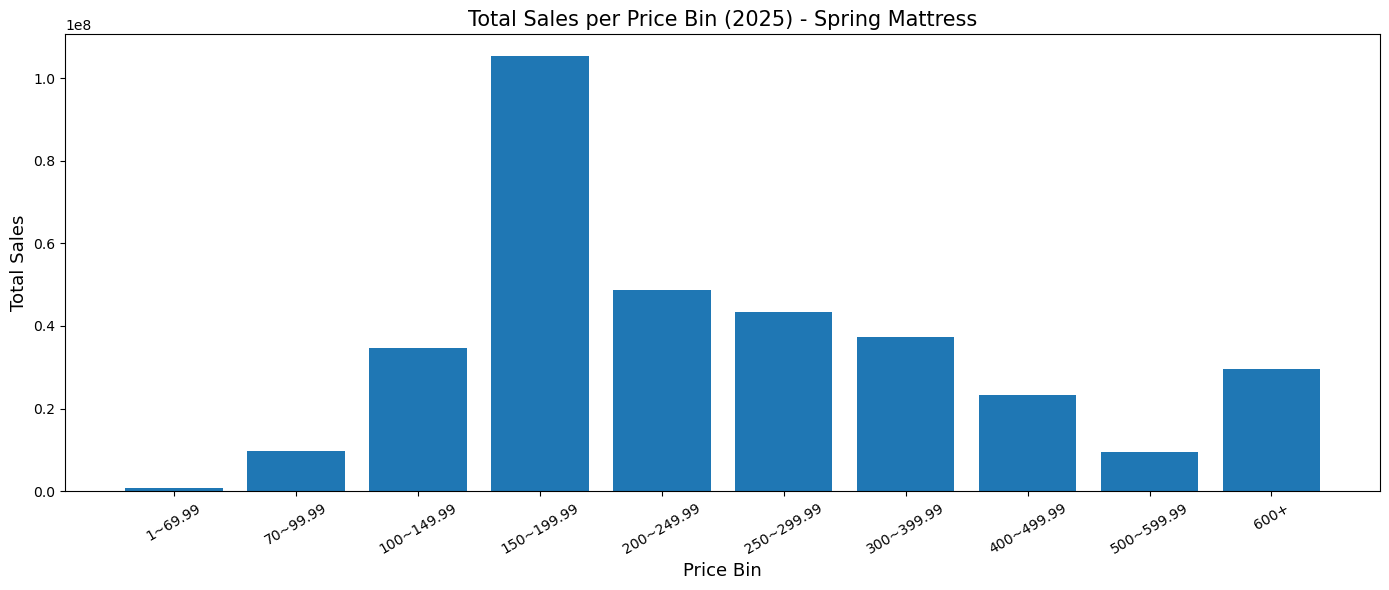

In [132]:
# 1. 2025년 데이터만 + OTHERS 제외
df_filtered = df1[(df1['year'] == 2025) & (df1['category'].isin(['Foam Mattress', 'Spring Mattress']))].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Foam/Spring 별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_filtered[df_filtered['category'] == cat]
    sales_by_bin = (
        df_cat.groupby('PriceBin')['RetailSales']
        .sum()
        .reindex(bin_labels)  # 빈 구간도 포함
    )

    plt.figure(figsize=(14,6))
    plt.bar(sales_by_bin.index, sales_by_bin.values)
    plt.xlabel("Price Bin", fontsize=13)
    plt.ylabel("Total Sales", fontsize=13)
    plt.title(f"Total Sales per Price Bin (2025) - {cat}", fontsize=15)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\271820143.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']


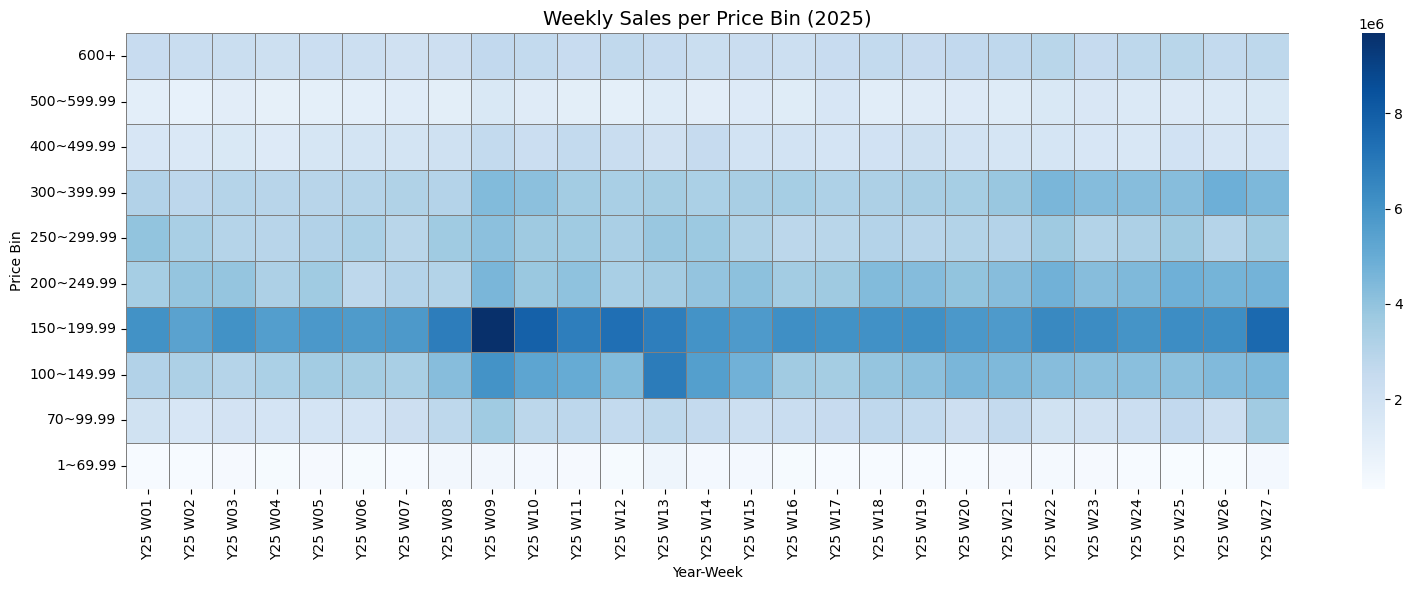

In [194]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Y축(Price Bin), X축(yr_week) 별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']
    .sum()
    .unstack(fill_value=0)
    .reindex(index=bin_labels[::-1])  # Y축 구간 순서 고정
)

# 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bin (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bin")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


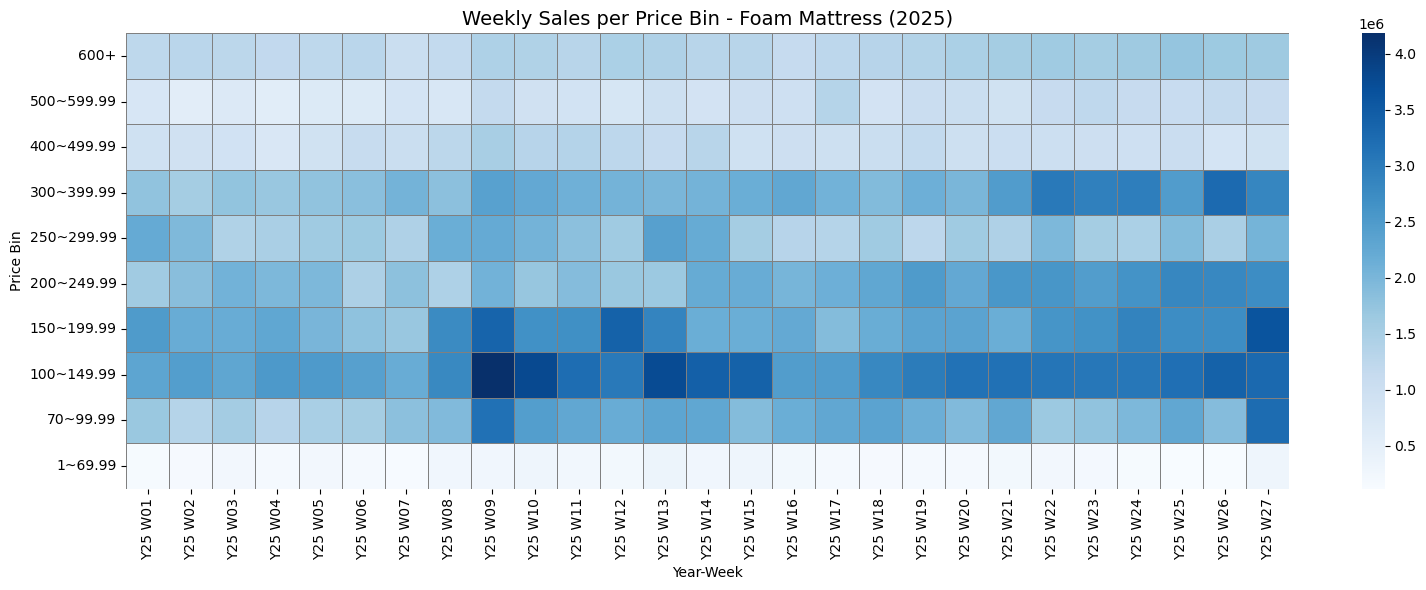

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


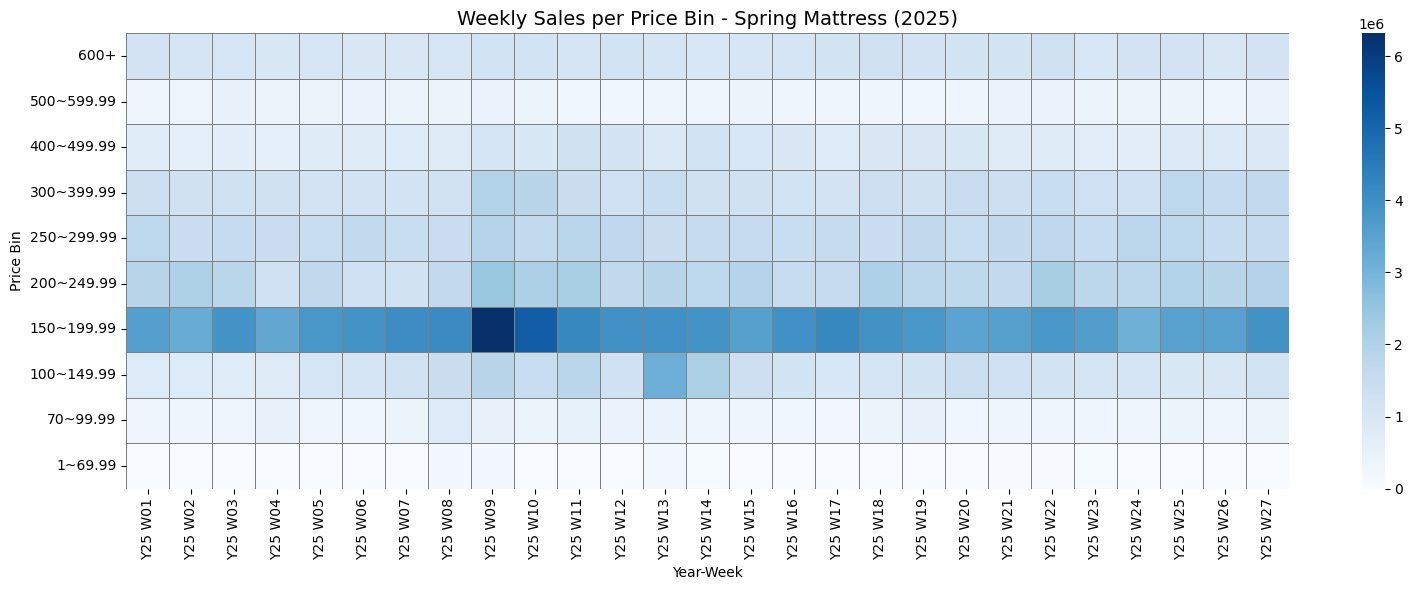

In [206]:
# Price Bin 설정
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

def draw_heatmap(df, category_name):
    df_cat = df[
        (df['category'] == category_name) & (df['year'] == 2025)
    ].copy()
    if len(df_cat) == 0:
        print(f"No data for {category_name}")
        return
    df_cat['PriceBin'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )
    all_weeks = sorted(df_cat['yr_week'].unique())
    heatmap_data = (
        df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=bin_labels[::-1], columns=all_weeks, fill_value=0)
    )
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bin - {category_name} (2025)", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bin")
    plt.tight_layout()
    plt.show()

# Foam Mattress
draw_heatmap(df, 'Foam Mattress')

# Spring Mattress
draw_heatmap(df, 'Spring Mattress')

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2227028325.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']


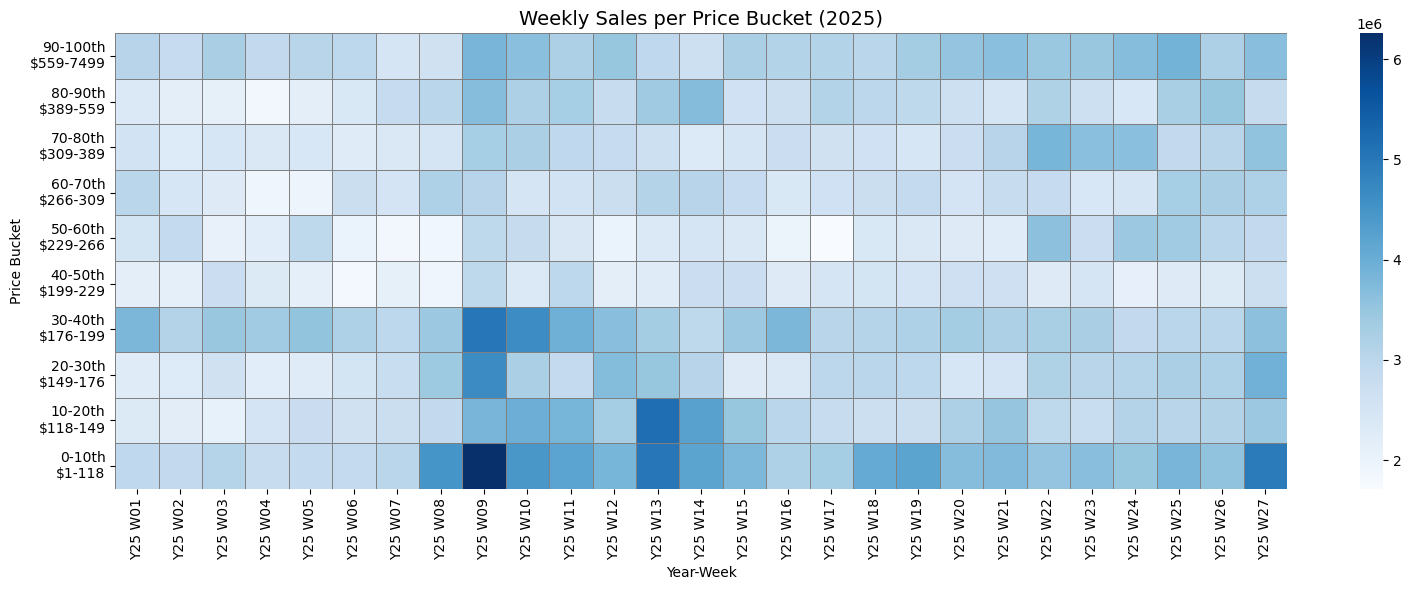

In [180]:

# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025) #&
    #(df['Brand_raw'] == 'ZINUS')
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준)
price_base = df_filtered['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 가격대 내림차순 정렬
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],
    ordered=True
)

# ✅ 4. 가격대 × 주차별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# ✅ 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bucket (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

#### 3.3 Percentile 가격대별 시장크기

In [180]:
df1 = df_mattress.copy()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\2737163554.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_recent.groupby(['PriceBucket', 'yr_month'])['RetailSales']


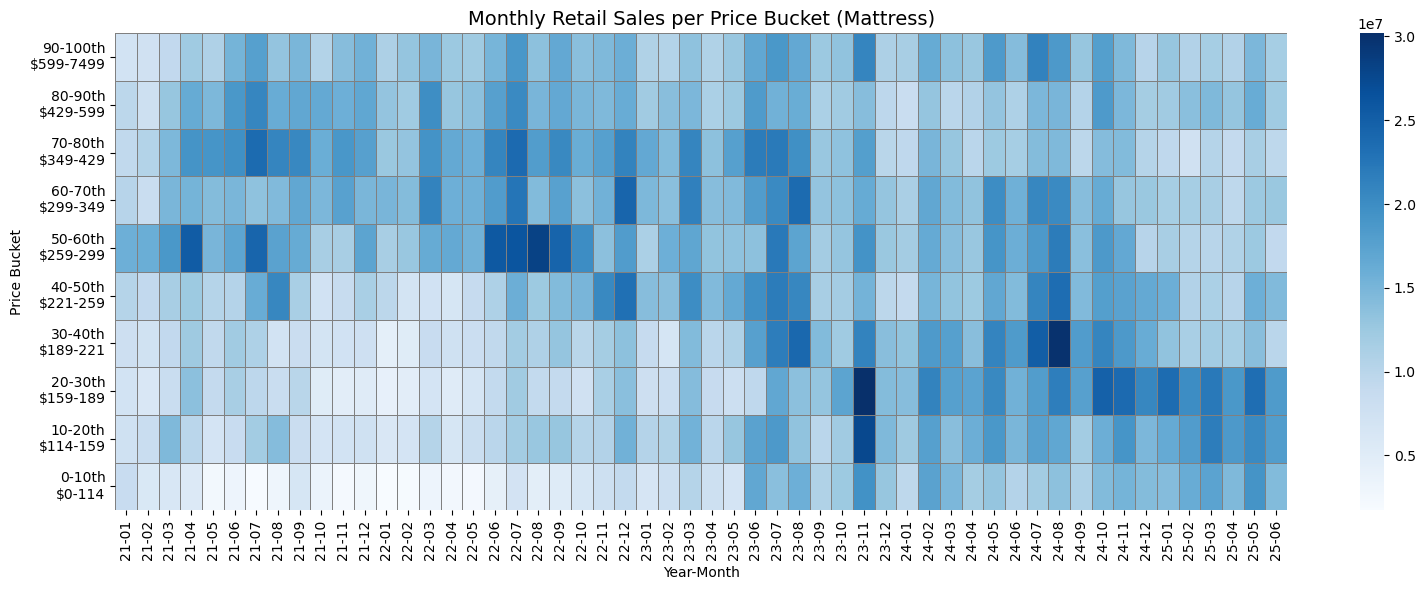

In [202]:
# 1. 2024, 2025년 데이터 필터링
df_recent = df1[df1['year'].isin([2021, 2022, 2023, 2024, 2025])].copy()

# ✅ '25-07' 제외
df_recent = df_recent[df_recent['yr_month'] != '25-07']

# 2. 가격 퍼센타일 구간 (전체 데이터 기준)
price_base = df_recent['RetailPrice'].dropna()
if len(price_base) < 2:
    print("데이터가 충분하지 않습니다.")
else:
    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    price_bins = np.unique(price_bins)

    # 라벨 생성
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_recent['PriceBucket'] = pd.cut(
        df_recent['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_recent['PriceBucket'] = pd.Categorical(
        df_recent['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 3. 히트맵용 데이터 생성 (월별 UnitsSold 합계)
    heatmap_data = (
        df_recent.groupby(['PriceBucket', 'yr_month'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
    )
        # ✅ 값이 숫자형인지 확인 후 변환
    heatmap_data = heatmap_data.astype(float)

    # 4. 히트맵 그리기
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title("Monthly Retail Sales per Price Bucket (Mattress)", fontsize=14)
    plt.xlabel("Year-Month")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14852\2453532074.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2025.groupby('PriceBucket')['RetailSales']


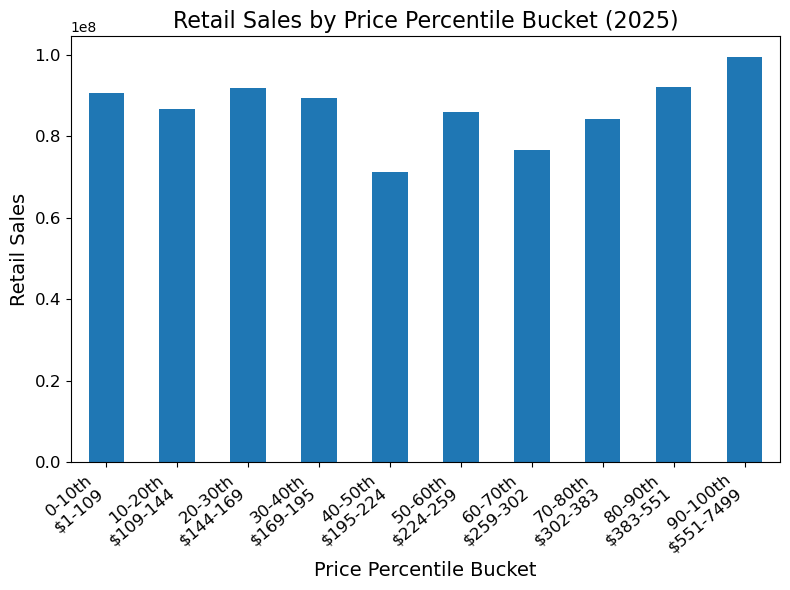

In [71]:
# 1. 2025년 데이터만 추출
df_2025 = df1[df1['year'] == 2025].copy()

# 2. 가격대 구간(퍼센타일) 나누기 (예: 10분위)
percentiles = np.arange(0, 101, 10)
price_base = df_2025['RetailPrice'].dropna()
price_bins = np.percentile(price_base, q=percentiles)
price_bins = np.unique(price_bins)  # 중복 경계 제거

# 3. bin 라벨 생성
bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 4. PriceBucket 컬럼 생성
df_2025['PriceBucket'] = pd.cut(
    df_2025['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# 5. 가격대별 매출 합계 집계 (PriceBucket 내림차순 정렬)
sales_by_bucket = (
    df_2025.groupby('PriceBucket')['RetailSales']
    .sum()
    .reindex(bucket_labels)  # 내림차순: 높은 가격대가 위쪽
)

# 6. 막대그래프 그리기
plt.figure(figsize=(8, 6))
sales_by_bucket.plot(kind='bar')
plt.title('Retail Sales by Price Percentile Bucket (2025)', fontsize=16)
plt.xlabel('Price Percentile Bucket', fontsize=14)
plt.ylabel('Retail Sales', fontsize=14)
plt.xticks(rotation=40, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(False)  # 또는 plt.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()



C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\2642248386.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_month'])['RetailSales']


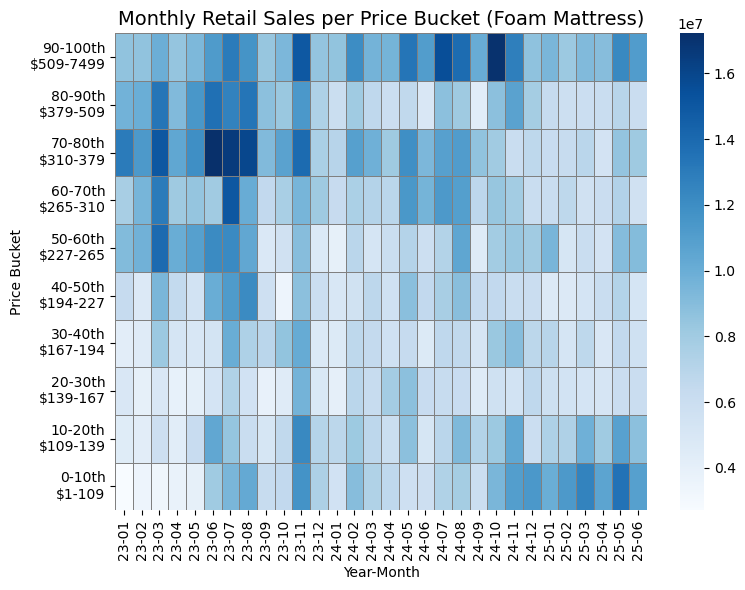

C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\2642248386.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_month'])['RetailSales']


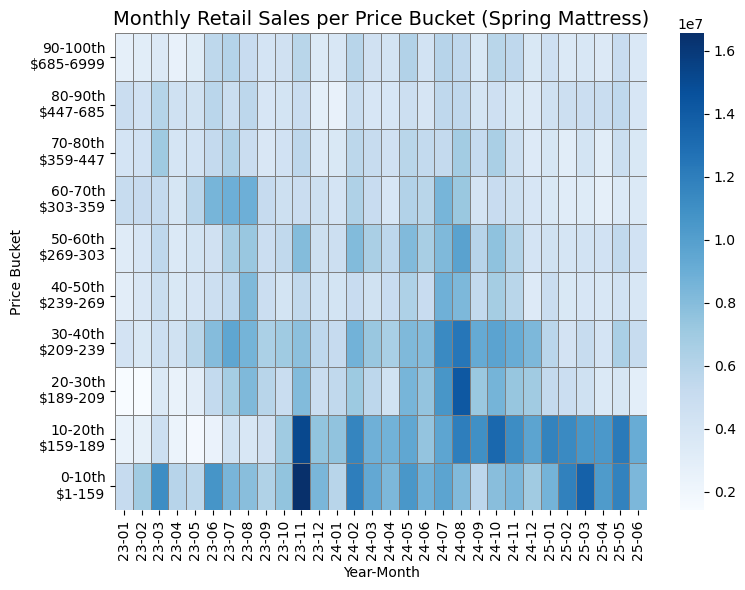

In [240]:

# 1. 최근 연도 필터링 + '25-07' 제외
df_recent = df1[
    df1['year'].isin([2023, 2024, 2025]) &
    (df1['yr_month'] != '25-07')
].copy()

# 2. 카테고리 반복: Foam & Spring
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_recent[df_recent['category'] == cat].copy()
    price_base = df_cat['RetailPrice'].dropna()

    if len(price_base) < 2:
        print(f"[{cat}] 데이터가 충분하지 않아 스킵합니다.")
        continue

    # 3. 가격 퍼센타일 구간
    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    price_bins = np.unique(price_bins)

    # 라벨 생성
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 4. 히트맵용 데이터 생성 (월별 매출 합계)
    heatmap_data = (
        df_cat.groupby(['PriceBucket', 'yr_month'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .astype(float)
    )

    # 5. 히트맵 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Monthly Retail Sales per Price Bucket ({cat})", fontsize=14)
    plt.xlabel("Year-Month")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\3413536068.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']


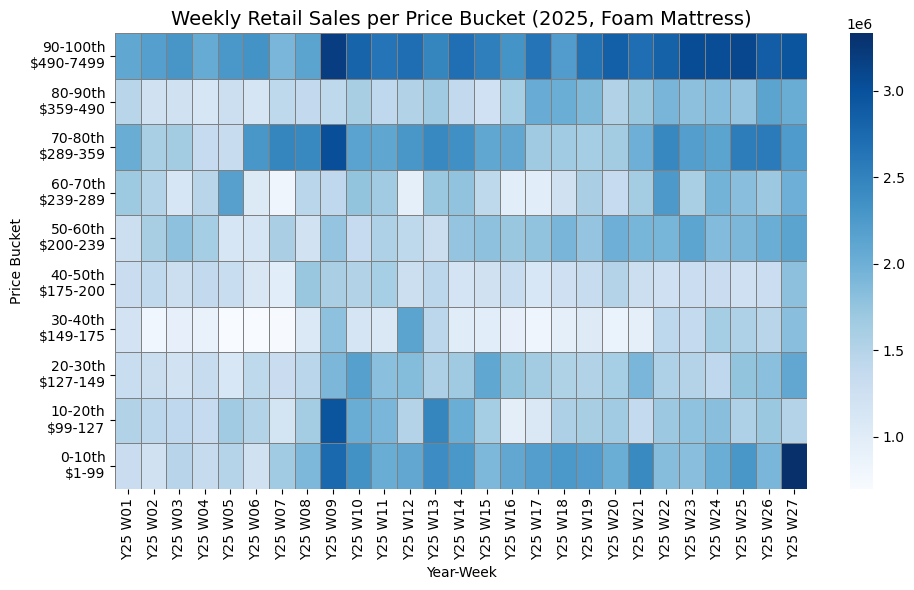

C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\3413536068.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']


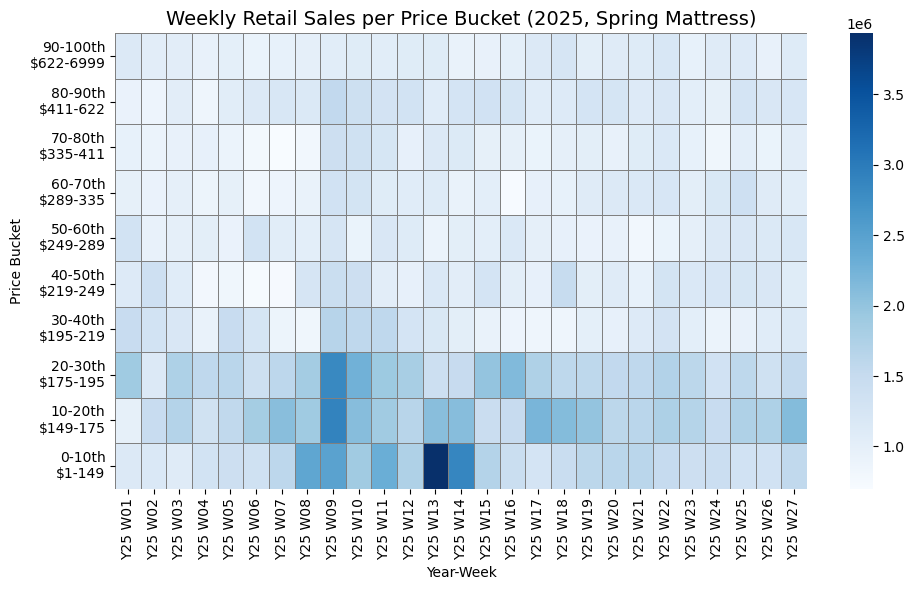

In [234]:

# 1. 2025년 데이터만 필터링 + '25-07' 제외 (yr_month → yr_week)
df_2025 = df1[df1['year'] == 2025].copy()

# 2. 카테고리 반복: Foam & Spring
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_2025[df_2025['category'] == cat].copy()
    price_base = df_cat['RetailPrice'].dropna()

    if len(price_base) < 2:
        print(f"[{cat}] 데이터가 충분하지 않아 스킵합니다.")
        continue

    # 3. 가격 퍼센타일 구간 (해당 카테고리 내)
    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    price_bins = np.unique(price_bins)

    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 4. 히트맵 데이터 생성 (주차별 매출 합계)
    heatmap_data = (
        df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .astype(float)
    )

    # 5. 히트맵 시각화
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Retail Sales per Price Bucket (2025, {cat})", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

#### 3.4 Brand별 가격대 분석

In [232]:
df_cat = df1[(df1['year'] == 2025) & (df1['category'] == 'Foam Mattress')].copy()
result = (
    df_cat.groupby(['Brand_raw'])['RetailSales']
          .sum()
          .sort_values(ascending=False)
)

print(result)

Brand_raw
ZINUS               1.143750e+08
NOVILLA             5.038964e+07
FDW                 3.958101e+07
MLILY               3.400318e+07
NECTAR              2.413848e+07
                        ...     
OLEESLEEP           1.585200e+02
LINSY               1.266600e+02
CHEER COLLECTION    9.999000e+01
MASTERMARK          4.299000e+01
MAXXI CLEAN         5.000000e+00
Name: RetailSales, Length: 305, dtype: float64


C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\3751495311.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


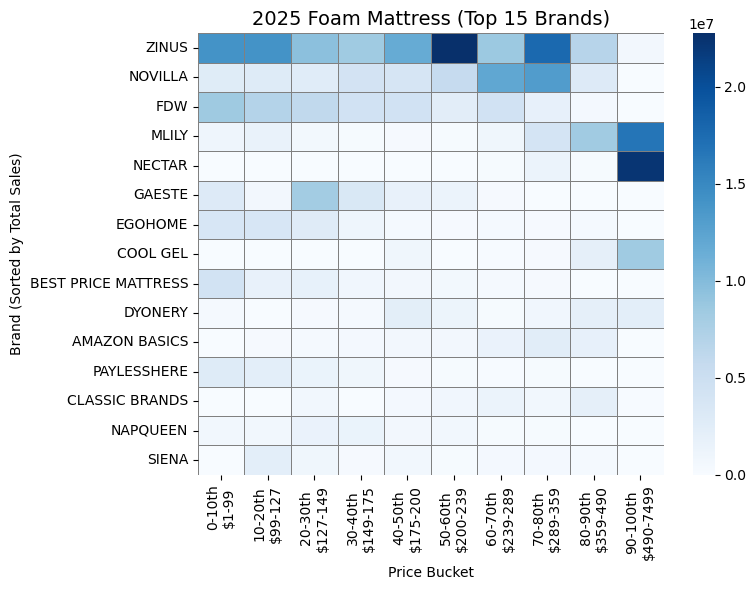

C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\3751495311.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


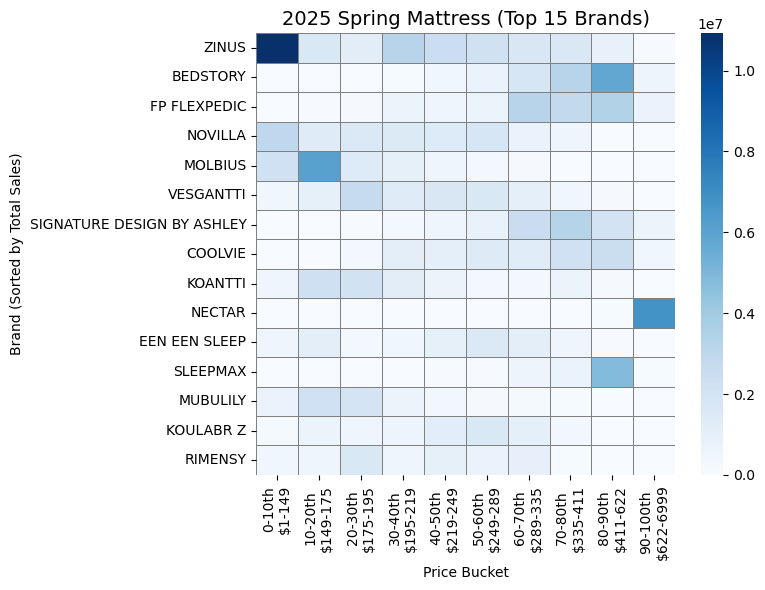

In [244]:
for cat in ['Foam Mattress', 'Spring Mattress']:
    # 1. 2025년 + 해당 카테고리 필터링
    df_cat = df1[(df1['year'] == 2025) & (df1['category'] == cat)].copy()
    if df_cat.empty:
        print(f"{cat}: 데이터가 없습니다.")
        continue

    # 2. 가격 퍼센타일 구간 계산 (카테고리별 독립)
    percentiles = np.arange(0, 101, 10)
    price_base = df_cat['RetailPrice'].dropna()
    price_bins = np.percentile(price_base, q=percentiles)
    price_bins = np.unique(price_bins)

    # 3. Top 15 브랜드 추출
    top_brands = (
        df_cat.groupby('Brand_raw')['RetailSales']
              .sum()
              .sort_values(ascending=False)
              .head(15)
              .index
    )

    # 4. Top 15 브랜드만 필터링
    df_top = df_cat[df_cat['Brand_raw'].isin(top_brands)].copy()

    # 5. 가격 구간 라벨 생성
    bucket_labels = [
        f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 6. 가격 버킷 할당
    df_top['PriceBucket'] = pd.cut(
        df_top['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )

    df_top['PriceBucket'] = pd.Categorical(
    df_top['PriceBucket'],
    categories=bucket_labels,   # ✅ 오름차순
    ordered=True
    )


    # 7. 브랜드 x 가격버킷 매출 집계
    heatmap_data = (
        df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']
              .sum()
              .unstack(fill_value=0)
    )

    # 8. 브랜드 순서를 총 매출 기준 내림차순으로 정렬
    brand_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
    heatmap_data = heatmap_data.loc[brand_order]
    heatmap_data = heatmap_data[bucket_labels]  # ✅ 오름차순
    
    # 9. 히트맵 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )

    plt.title(f"2025 {cat} (Top 15 Brands)", fontsize=14)
    plt.xlabel("Price Bucket")
    plt.ylabel("Brand (Sorted by Total Sales)")
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_34580\1805552970.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


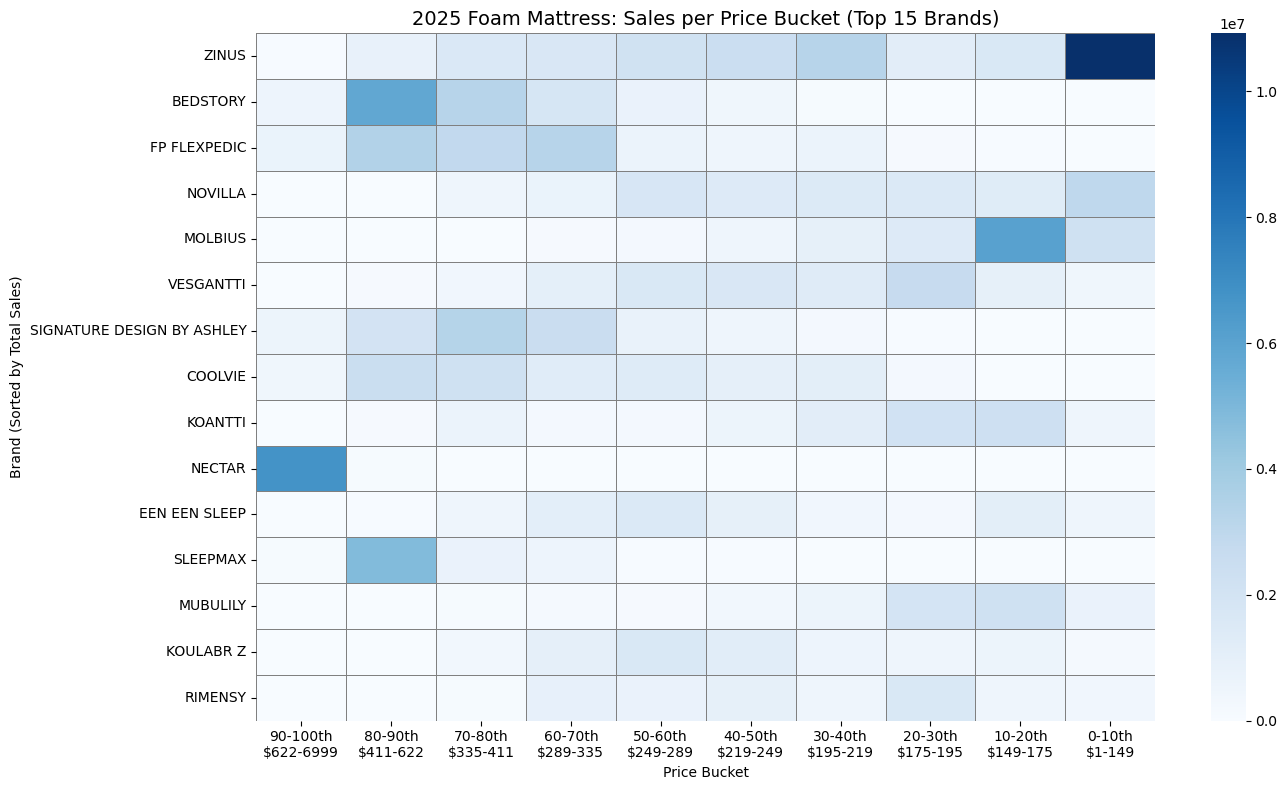

In [222]:

# 1. 2025년 + Foam Mattress 필터링
df_foam = df1[(df1['year'] == 2025) & (df1['category'] == 'Spring Mattress')].copy()

# 2. Top 10 브랜드 추출
top_brands = (
    df_foam.groupby('Brand_raw')['RetailSales']
           .sum()
           .sort_values(ascending=False)
           .head(15)
           .index
)

# 3. Top 10 브랜드만 필터링
df_top = df_foam[df_foam['Brand_raw'].isin(top_brands)].copy()

# 4. 가격 퍼센타일 경계 계산
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(df_foam['RetailPrice'].dropna(), q=percentiles)
price_bins = np.unique(price_bins)  # 중복 제거

# 5. 구간 라벨 생성
bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 6. 가격 버킷 할당
df_top['PriceBucket'] = pd.cut(
    df_top['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)
df_top['PriceBucket'] = pd.Categorical(
    df_top['PriceBucket'],
    categories=bucket_labels[::-1],  # 내림차순 정렬
    ordered=True
)

# 7. 브랜드 x 가격버킷 매출 집계
heatmap_data = (
    df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']
          .sum()
          .unstack(fill_value=0)
)

# 8. 브랜드 순서를 총 매출 기준 내림차순으로 정렬
brand_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[brand_order]

# 9. 히트맵 시각화
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("2025 Foam Mattress: Sales per Price Bucket (Top 15 Brands)", fontsize=14)
plt.xlabel("Price Bucket")
plt.ylabel("Brand (Sorted by Total Sales)")
plt.tight_layout()
plt.show()

## 4. NPI 분석

In [85]:
df1 = df_nrr.copy()

In [87]:
df1.head(5)

,asin,title,sales_2024,sales_2025,units_sold_2024,units_sold_2025,price_2024,price_2025,rank,crawl_time,brand,category,subcategory,profile,size_raw,size,listed_since_date
0,B0D7QXSCNG,GAESTE 8 Inch Twin XL Cooling Gel Memory Foam ...,73893.19,76475.68,533.0,579.0,142.22375,136.318333,2,2024-09-17 09:07:47,None,Foam Mattress,Cooling/Gel,8,TXL,Twin XL,NaT
1,B0CYGNT3P7,"EGOHOME 10 Inch Twin XL Mattress, Cooling Gel ...",24898.34,NaN,166.0,NaN,149.99000,NaN,41,2024-03-24 09:08:47,None,Foam Mattress,Cooling/Gel,10,TXL,Twin XL,NaT
2,B0D83MJL8L,"AMICLIBER 3 Inch Tri-Fold Mattress, Small Sing...",37080.20,4488.26,857.0,95.0,44.04280,50.112174,19,2024-09-23 09:06:04,AMICLIBER,Foam Mattress,Non-Cooling,3,Small Single,Twin,2024-06-26
3,B0F7G97MQ1,AYDMI 45D High-Density Foam Sagging Mattress S...,NaN,NaN,NaN,NaN,NaN,NaN,96,2025-08-02 09:08:27,AYDMI,Foam Mattress,Non-Cooling,2,59”x 24”,OTHERS,2025-05-04
4,B0DZHZ1XF9,"Amzreine Baby Bassinet Mattress Topper, 30"" x ...",NaN,NaN,NaN,NaN,NaN,NaN,51,2025-07-17 09:05:51,Amzreine,Foam Mattress,Non-Cooling,2,"Oval 30"" x 15""",OTHERS,2025-05-18


In [89]:
# 1. 날짜 컬럼이 datetime 타입이 아니면 변환
df1['listed_since_date'] = pd.to_datetime(df1['listed_since_date'], errors='coerce')

# 2. 연도(year) 컬럼 생성
df1['year'] = df1['listed_since_date'].dt.year.astype('Int64')

# 3. 연월(yr_month) 컬럼 생성 (YYYY-MM 형식 문자열)
df1['yr_month'] = df1['listed_since_date'].dt.strftime('%Y-%m')

# 4. 분기(yr_quarter) 컬럼 생성 (YY-Q 형식: 예시 '24-3'은 2024년 3분기)
#df1['yr_quarter'] = df1['listed_since_date'].dt.strftime('%y') + '-' + df1['listed_since_date'].dt.quarter.astype(str)
df1['yr_quarter'] = (
    df1['listed_since_date'].dt.strftime('%y') + '-' +
    df1['listed_since_date'].dt.quarter.fillna(0).astype(int).astype(str)
)

# 결과 일부 확인
print(df1[['listed_since_date', 'year', 'yr_month', 'yr_quarter']].head())

  listed_since_date  year yr_month yr_quarter
0               NaT  <NA>      NaN        NaN
1               NaT  <NA>      NaN        NaN
2        2024-06-26  2024  2024-06       24-2
3        2025-05-04  2025  2025-05       25-2
4        2025-05-18  2025  2025-05       25-2


In [91]:
df1['year'].isna().sum()

1407

In [93]:
df1.groupby('year')['asin'].nunique()

year
2023     453
2024    3135
2025    1626
Name: asin, dtype: int64

In [95]:
# 2024년 ~ 2025년
df2 = df1[df1['year'].isin([2024,2025])]

In [97]:
df2.groupby('year')['asin'].count()

year
2024    3135
2025    1626
Name: asin, dtype: int64

In [99]:
df2.groupby(['category','subcategory'])['asin'].count()

category         subcategory  
Foam Mattress    Cooling/Gel       822
                 Non-Cooling      1042
OTHERS           OTHERS            407
Spring Mattress  Bonnell            48
                 Pocket Spring    2442
Name: asin, dtype: int64

In [101]:
# 브랜드별 신제품 수
df2.groupby('brand')['asin'].nunique().sort_values(ascending=False)

brand
Novilla         193
Generic         153
Avenco           87
FP FLEXPEDIC     77
Sweetnight       72
               ... 
MOMCAYWEX         1
MOLBIUS           1
MATSUBA           1
AC Pacific        1
zvsay             1
Name: asin, Length: 709, dtype: int64

C:\Users\최태욱\AppData\Local\Temp\ipykernel_35992\3973045178.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['listed_since_month'] = pd.to_datetime(df2['listed_since_date']).dt.to_period('M')


<Axes: xlabel='listed_since_month'>

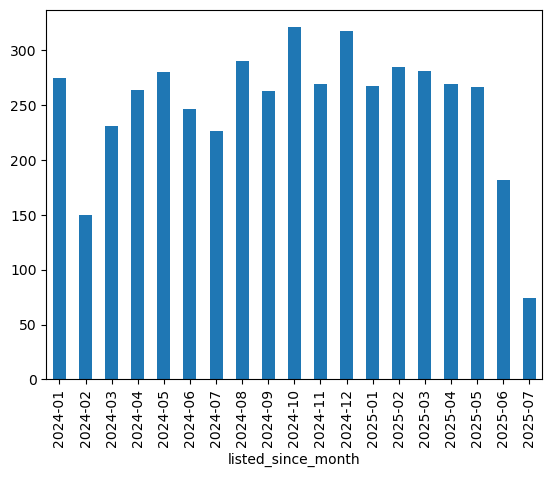

In [103]:
# 신제품 출시 월별 트렌드
df2['listed_since_month'] = pd.to_datetime(df2['listed_since_date']).dt.to_period('M')
df2.groupby('listed_since_month')['asin'].nunique().plot(kind='bar')

### 3.1 분기별 신제품 개수 (2024 ~ 2025)

In [129]:
df2 = df1[df1['year'].isin([2024,2025])]

In [143]:
print(df2)

            asin                                              title  \
2     B0D83MJL8L  AMICLIBER 3 Inch Tri-Fold Mattress, Small Sing...   
3     B0F7G97MQ1  AYDMI 45D High-Density Foam Sagging Mattress S...   
4     B0DZHZ1XF9  Amzreine Baby Bassinet Mattress Topper, 30" x ...   
5     B0DZHY2CH6  Amzreine Baby Bassinet Mattress Pad, 30" x 18"...   
6     B0DZHXPS5G  Baby Bassinet Mattress, 26" x 12" x 2" Dual Si...   
...          ...                                                ...   
6614  B0D8TBN4CH  Yuewanshun Twin XL Mattress 12 Inch, Hybrid XL...   
6615  B0CS9MJJ3J  12 Inches Twin XL Mattress Memory Foam Mattres...   
6616  B0DWTD7WG4  Twin XL Mattress, Memory Foam Medium Firm Hybr...   
6619  B0DPWVXNWV  pengucool 10 Inch Twin XL Memory Foam Mattress...   
6620  B0DR26MW7G  sleeprove Twin XL Size Mattress, 6 Inch Hybrid...   

      sales_2024  sales_2025  units_sold_2024  units_sold_2025  price_2024  \
2        37080.2     4488.26            857.0             95.0     44

In [137]:
# brand가 ZINUS인 데이터만 필터링
df_zinus = df2[df2['brand'] == 'ZINUS']

# 연도별 asin 개수 (중복 제거)
asin_count_by_year = (
    df_zinus.groupby('year')['asin']
    .nunique()
    .reset_index(name='asin_count')
)

print(asin_count_by_year)

   year  asin_count
0  2024           7


In [147]:
# brand가 ZINUS인 데이터 전체 출력
df_zinus_all = df2[df2['brand'] == 'ZINUS']

df_zinus_all

,asin,title,sales_2024,sales_2025,units_sold_2024,units_sold_2025,price_2024,price_2025,rank,crawl_time,brand,category,subcategory,profile,size_raw,size,listed_since_date,year,yr_month,yr_quarter
186,B0CSK2M8DJ,ZINUS 10 Inch Ultima Memory Foam Mattress [New...,379799.79,687046.48,1671.0,2846.0,232.068571,240.268000,100,2024-04-13 09:09:16,ZINUS,Foam Mattress,Non-Cooling,10,SQ,Queen,2024-01-17,2024,2024-01,24-1
2199,B0CSJWLRK7,ZINUS 10 Inch Green Tea Essential Memory Foam ...,171795.65,338141.64,862.0,2021.0,199.140741,174.425862,82,2024-04-11 09:07:36,ZINUS,Foam Mattress,Cooling/Gel,10,F,Full,2024-01-17,2024,2024-01,24-1
3283,B0CSJX5Z2V,ZINUS 10 Inch Green Tea Essential Memory Foam ...,220545.04,241148.94,969.0,1001.0,274.786429,246.348400,75,2024-03-25 09:12:47,ZINUS,Foam Mattress,Cooling/Gel,10,K,King,2024-01-17,2024,2024-01,24-1
5546,B0CSK1787N,ZINUS 10 Inch Green Tea Essential Memory Foam ...,99501.80,829885.21,741.0,6297.0,140.354242,132.627241,96,2024-04-14 09:10:47,ZINUS,Foam Mattress,Cooling/Gel,10,T,Twin,2024-01-17,2024,2024-01,24-1
5548,B0CSJTJCCS,ZINUS 5 Inch Cooling Essential Memory Foam Mat...,640985.02,2177991.04,8227.0,28826.0,78.640000,78.195862,84,2024-03-19 09:13:09,ZINUS,Foam Mattress,Cooling/Gel,5,T,Twin,2024-01-17,2024,2024-01,24-1
5549,B0CSJX57TM,ZINUS 8 Inch Green Tea Essential Memory Foam M...,181781.82,599664.14,1818.0,6050.0,99.990000,99.572414,90,2024-04-16 09:08:20,ZINUS,Foam Mattress,Cooling/Gel,8,T,Twin,2024-01-17,2024,2024-01,24-1
5550,B0CSJMCXKB,ZINUS 8 Inch Green Tea Essential Memory Foam M...,835777.12,1913681.29,9287.0,21716.0,90.545278,88.866207,88,2024-02-21 09:07:18,ZINUS,Foam Mattress,Cooling/Gel,6,T,Twin,2024-01-17,2024,2024-01,24-1


In [107]:
# 1. 분기별 신제품 개수 집계
quarter_trend = (
    df2.groupby('yr_quarter')['asin']
    .nunique()
    .reset_index()
)

# 2. '25-3' 분기 제외
quarter_trend = quarter_trend[quarter_trend['yr_quarter'] != '25-3']

# 3. 정렬
quarter_trend = quarter_trend.sort_values('yr_quarter')

print(quarter_trend)

  yr_quarter  asin
0       24-1   656
1       24-2   791
2       24-3   780
3       24-4   908
4       25-1   834
5       25-2   718


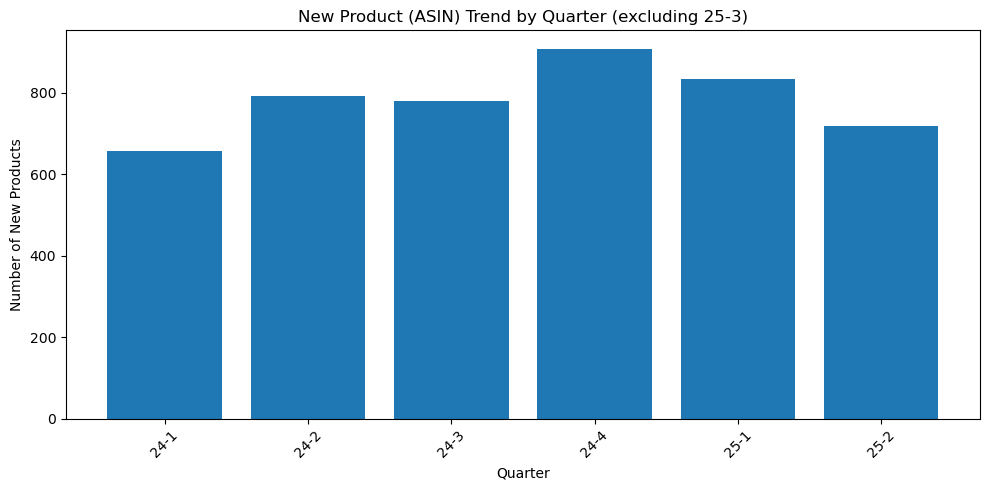

In [109]:
plt.figure(figsize=(10, 5))
plt.bar(quarter_trend['yr_quarter'], quarter_trend['asin'])
plt.title('New Product (ASIN) Trend by Quarter (excluding 25-3)')
plt.xlabel('Quarter')
plt.ylabel('Number of New Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

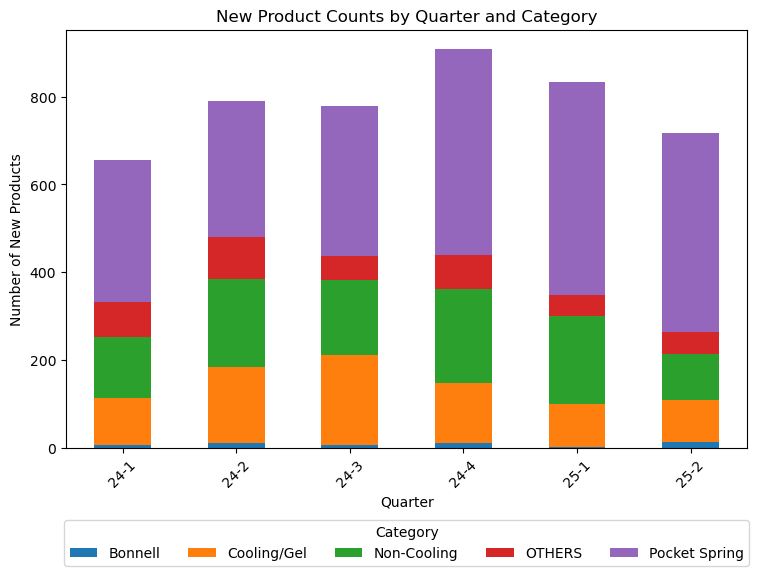

In [262]:
# 1. 분기별, 카테고리별 신제품 개수 집계
pivot = (
    df2[df2['yr_quarter'] != '25-3']
#    .groupby(['yr_quarter', 'category'])['asin']
    .groupby(['yr_quarter', 'subcategory'])['asin']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

# 2. 누적 막대그래프 (stacked bar chart)
pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)
plt.title('New Product Counts by Quarter and Category')
plt.xlabel('Quarter')
plt.ylabel('Number of New Products')
plt.xticks(rotation=45)
#plt.legend(title='Category', bbox_to_anchor=(1.05, 0), loc='lower left')
plt.legend(
    title='Category',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.3),  # 0.5는 x(가운데), -0.3은 y(그래프 아래)
    ncol=5                      # 한 줄에 카테고리 3개씩 (필요에 따라 조정)
)
plt.tight_layout()
plt.show()

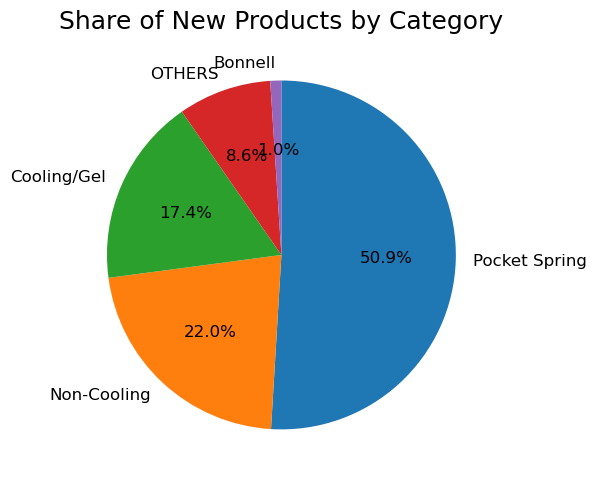

In [266]:
# 1. 전체 기간 subcategory별 신제품 개수 합계 (25-3 분기 제외)
subcategory_total = (
    df2[df2['yr_quarter'] != '25-3']
    .groupby('subcategory')['asin']
    .nunique()
    .sort_values(ascending=False)
)

# 2. 파이차트 그리기
plt.figure(figsize=(6, 6))
plt.pie(
    subcategory_total,
    labels=subcategory_total.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 12}  # 폰트 크기(예: 14) 조정
)
plt.title('Share of New Products by Category', fontsize=18)
plt.tight_layout()
plt.show()

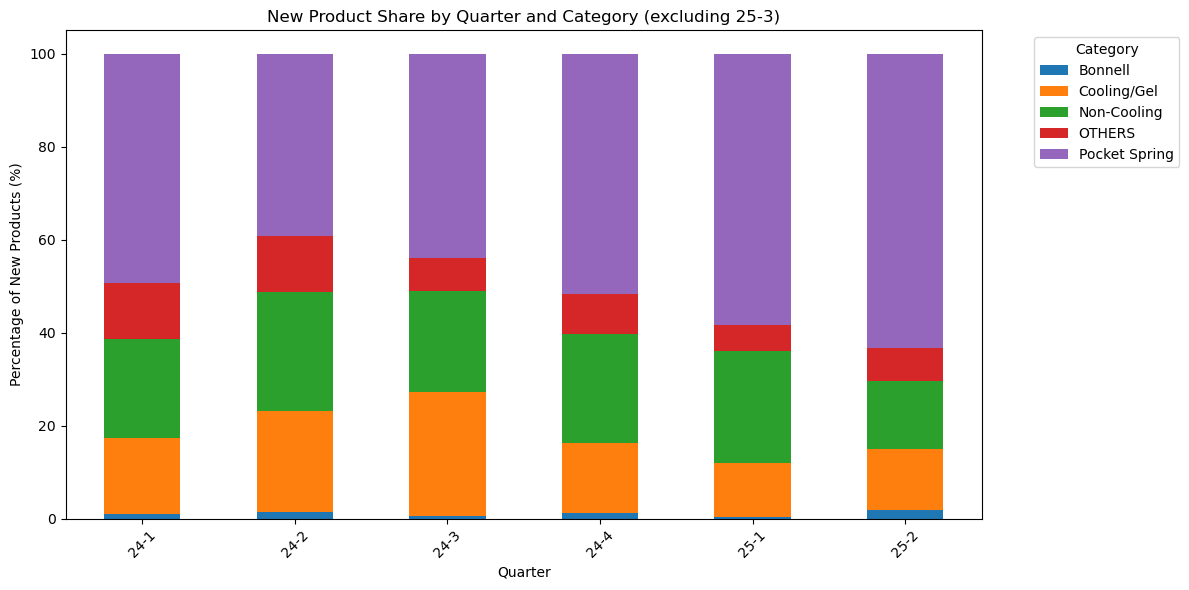

In [158]:

# 1. 분기별, 카테고리별 신제품 개수 피벗 (25-3 제외)
pivot = (
    df2[df2['yr_quarter'] != '25-3']
    .groupby(['yr_quarter', 'subcategory'])['asin']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

# 2. 각 분기별로 비율(%)로 변환
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 3. 100% stacked bar chart
pivot_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('New Product Share by Quarter and Category (excluding 25-3)')
plt.xlabel('Quarter')
plt.ylabel('Percentage of New Products (%)')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [272]:
# 1. 분기별, category, profile(inch)별 신제품 개수 집계
result = (
    df2[df2['yr_quarter'] != '25-3']
    .groupby(['yr_quarter', 'category', 'profile'], dropna=False)['asin']
    .nunique()
    .reset_index()
    .sort_values(['yr_quarter', 'category', 'profile'])
)

print(result)

    yr_quarter         category profile  asin
0         24-1    Foam Mattress     0.1     1
1         24-1    Foam Mattress     0.5     2
2         24-1    Foam Mattress     0.8     1
3         24-1    Foam Mattress      10    48
4         24-1    Foam Mattress    11.8     1
..         ...              ...     ...   ...
247       25-2  Spring Mattress       5     1
248       25-2  Spring Mattress       6     2
249       25-2  Spring Mattress       7     2
250       25-2  Spring Mattress       8    12
251       25-2  Spring Mattress       9     1

[252 rows x 4 columns]


In [296]:
profile_totals.sum()

4245

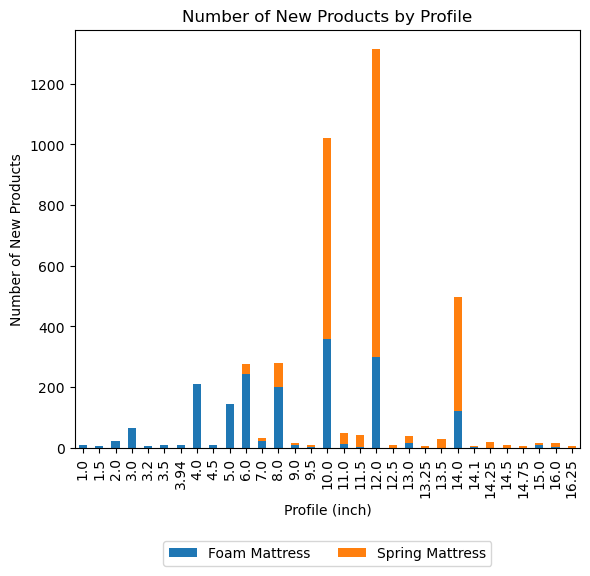

In [316]:
# profile을 숫자형으로 변환 (정렬 및 X축 표시를 위해)
result['profile_num'] = pd.to_numeric(result['profile'], errors='coerce')

# 분기/카테고리별 원하는 필터링 (모든 카테고리/분기 합계로 누적 그리려면 category 무시)
pivot = (
    result
    .groupby(['profile_num', 'category'])['asin']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# profile별 전체 합 계산 (각 row마다)
profile_totals = pivot.sum(axis=1)

# 50개 이상인 profile만 필터링
pivot_filtered = pivot[profile_totals >= 5]

# X축 profile 오름차순 정렬
pivot = pivot.sort_index(ascending=True)

# 누적 막대그래프(stacked bar chart)
pivot_filtered.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 6)
)
plt.title('Number of New Products by Profile')
plt.xlabel('Profile (inch)')
plt.ylabel('Number of New Products')
plt.legend(
    #title='Category',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.3),  # 0.5는 x(가운데), -0.3은 y(그래프 아래)
    ncol=5                      # 한 줄에 카테고리 3개씩 (필요에 따라 조정)
)
plt.tight_layout()
plt.show()

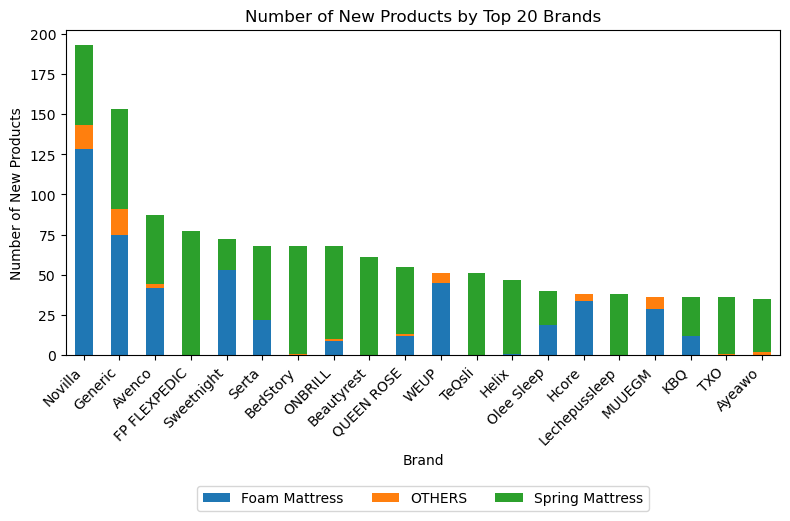

In [306]:
# 1. 브랜드별 신제품 총합 기준 상위 20개 추출
brand_total = (
    df2.groupby('brand')['asin']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .index
)

# 2. 이 브랜드들만 필터링하여 category별 신제품 개수 집계
brand_cat_top = (
    df2[df2['brand'].isin(brand_total)]
    .groupby(['brand', 'category'])['asin']
    .nunique()
    .unstack(fill_value=0)
    .loc[brand_total]   # 순서 유지
)

# 3. 누적(stacked) 막대그래프
brand_cat_top.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)
plt.title('Number of New Products by Top 20 Brands')
plt.xlabel('Brand')
plt.ylabel('Number of New Products')
plt.xticks(rotation=45, ha='right')
#plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(
    #title='Category',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.5),  # 0.5는 x(가운데), -0.3은 y(그래프 아래)
    ncol=5                      # 한 줄에 카테고리 3개씩 (필요에 따라 조정)
)
plt.tight_layout()
plt.show()

In [214]:
# sales_2024, sales_2025 결측치는 0으로 간주
df2['total_sales'] = df2['sales_2024'].fillna(0) + df2['sales_2025'].fillna(0)

df2['avg_price'] = (
    df2[['price_2024', 'price_2025']]
    .replace(0, np.nan)
    .mean(axis=1, skipna=True)
)

# total_sales 기준 상위 asin 추출 (예: Top 10)
top_asin = df2.sort_values('total_sales', ascending=False).head(20)

# 결과 확인
# 결과 확인
top_asin[['asin', 'title', 'total_sales', 'avg_price', 'brand', 'category','subcategory','profile','listed_since_date']]

C:\Users\최태욱\AppData\Local\Temp\ipykernel_16856\2242822260.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_sales'] = df2['sales_2024'].fillna(0) + df2['sales_2025'].fillna(0)
C:\Users\최태욱\AppData\Local\Temp\ipykernel_16856\2242822260.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['avg_price'] = (


,asin,title,total_sales,avg_price,brand,category,subcategory,profile,listed_since_date
2140,B0D7QW9612,GAESTE 8 Inch Full Cooling Gel Memory Foam Mat...,9715392.87,140.279986,GAESTE,Foam Mattress,Cooling/Gel,8,2024-06-21
4036,B0DCXFXGBM,Nectar Classic 12” Queen Mattress (New Version...,9274079.29,614.303469,Nectar,Foam Mattress,Cooling/Gel,12,2024-08-12
3981,B0DBRPDD3P,Amztree Queen Mattress 12 Inch Mattress Queen ...,6206407.13,204.943122,Amztree,Spring Mattress,Pocket Spring,12,2024-07-31
4106,B0DBVXVQKQ,Ablyea Queen Mattress 12 Inch Hybrid Mattress ...,5974447.98,205.829900,Ablyea,Spring Mattress,Pocket Spring,12,2024-08-01
4014,B0CVL8FVKR,"Gojef Queen Size Mattress, 12 Inch Memory Foam...",4634386.65,226.290341,Gojef,Spring Mattress,Pocket Spring,12,2024-02-25
3253,B0DCXBFQDW,Nectar Classic 12” King Mattress (New Version)...,4207126.61,815.684148,Nectar,Foam Mattress,Cooling/Gel,12,2024-08-12
4015,B0CS96W58W,"KOANTTI Queen Mattresses,14 Inch Queen Size Ma...",3387529.64,289.928291,KOANTTI,Spring Mattress,Pocket Spring,14,2024-01-13
4052,B0CSFYJLLN,"Novilla Queen Mattress, 12 Inch Hybrid Mattres...",3159536.26,211.917062,Novilla,Spring Mattress,Pocket Spring,12,2024-01-16
3258,B0CSFY8J3R,"Novilla King Mattress, 12 Inch Hybrid Mattress...",3054296.76,278.181386,Novilla,Spring Mattress,Pocket Spring,12,2024-01-16
5548,B0CSJTJCCS,ZINUS 5 Inch Cooling Essential Memory Foam Mat...,2818976.06,78.417931,ZINUS,Foam Mattress,Cooling/Gel,5,2024-01-17


In [218]:
# sales_2025 결측치는 0으로 간주
df3 = df2[df2['year']==2025].copy()
#df2['sales_2025_filled'] = df2['sales_2025'].fillna(0)

# sales_2025 기준 상위 asin 추출 (예: Top 10)
top_asin_2025 = df3.sort_values('sales_2025', ascending=False).head(20)

# 결과 확인
top_asin_2025[['asin', 'title', 'sales_2025', 'price_2025', 'brand', 'category','subcategory','profile','listed_since_date']]

,asin,title,sales_2025,price_2025,brand,category,subcategory,profile,listed_since_date
4864,B0DV5PWL3S,"Novilla Queen Mattress, 10 Inch Queen Size Mat...",1794976.09,174.494783,Novilla,Foam Mattress,Cooling/Gel,10,2025-01-27
4021,B0DP3ZQF6Q,"KOULABR Z Queen Size Mattress, 12 Inch Hybrid ...",1663608.44,233.921852,KOULABR Z,Spring Mattress,Pocket Spring,12,2025-01-02
4061,B0DX68SPYQ,OFFTR z Queen Mattress 14 Inch – Medium Firm H...,1390285.45,279.702778,OFFTR z,Spring Mattress,Pocket Spring,14,2025-03-12
3979,B0DZFYNSKL,"Queen Mattress,12 Inch Queen Size Mattresses i...",1373141.67,285.926316,AN Adamant Noyau,Spring Mattress,Pocket Spring,12,2025-01-15
3274,B0DWMTNL17,Sleepmax King Size Mattress 14 Inch - Hotel-Co...,1223084.75,584.913684,Sleepmax,Spring Mattress,Pocket Spring,14,2025-03-15
3240,B0DMN2PY7P,"King Size Mattress, Upgrade Strengthen 12 Inch...",1167324.30,284.854828,EEN EEN SLEEP,Spring Mattress,Pocket Spring,12,2025-06-15
6016,B0DWK5F9ZF,"Novilla Twin Mattress, 6 Inch Twin Bed Mattres...",1106717.79,80.472381,Novilla,Foam Mattress,Cooling/Gel,6,2025-02-08
4869,B0DWK7DTNW,"Novilla 12 Inch Queen Mattress in a Box, Gel M...",1001506.02,207.410476,Novilla,Foam Mattress,Cooling/Gel,12,2025-02-08
2135,B0DLZPMH8W,"Full Size Mattress, Upgrade Strengthen 10 Inch...",942982.52,166.308214,EEN EEN SLEEP,Spring Mattress,Pocket Spring,10,2025-06-15
4020,B0DQD63WG9,"KOULABR Z Queen Size Mattress, 14 Inch Hybrid ...",909289.14,289.195200,KOULABR Z,Spring Mattress,Pocket Spring,14,2025-01-03


### 3.2 2025년 현황

In [111]:
df_2025 = df1[df1['year'] == 2025]

In [113]:
df_2025

,asin,title,sales_2024,sales_2025,units_sold_2024,units_sold_2025,price_2024,price_2025,rank,crawl_time,brand,category,subcategory,profile,size_raw,size,listed_since_date,year,yr_month,yr_quarter
3,B0F7G97MQ1,AYDMI 45D High-Density Foam Sagging Mattress S...,NaN,NaN,NaN,NaN,NaN,NaN,96,2025-08-02 09:08:27,AYDMI,Foam Mattress,Non-Cooling,2,59”x 24”,OTHERS,2025-05-04,2025,2025-05,25-2
4,B0DZHZ1XF9,"Amzreine Baby Bassinet Mattress Topper, 30"" x ...",NaN,NaN,NaN,NaN,NaN,NaN,51,2025-07-17 09:05:51,Amzreine,Foam Mattress,Non-Cooling,2,"Oval 30"" x 15""",OTHERS,2025-05-18,2025,2025-05,25-2
5,B0DZHY2CH6,"Amzreine Baby Bassinet Mattress Pad, 30"" x 18""...",NaN,NaN,NaN,NaN,NaN,NaN,27,2025-08-05 09:08:06,Amzreine,Foam Mattress,Non-Cooling,2,"Oval 30"" x 18""",OTHERS,2025-05-18,2025,2025-05,25-2
6,B0DZHXPS5G,"Baby Bassinet Mattress, 26"" x 12"" x 2"" Dual Si...",NaN,NaN,NaN,NaN,NaN,NaN,25,2025-07-28 09:10:43,Amzreine,Foam Mattress,Non-Cooling,2,"Retangle 26"" x 12"" x 2""",OTHERS,2025-06-23,2025,2025-06,25-2
25,B0F1F63V7N,"DZHPSRSZ 4Pack Mattress Slide Stopper,Mattress...",NaN,NaN,NaN,NaN,NaN,NaN,79,2025-05-24 09:05:45,DZHPSRSZ,Foam Mattress,Non-Cooling,None,Bassinet,OTHERS,2025-03-14,2025,2025-03,25-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6594,B0DZNR1LYS,Topllen 10 Inch Twin XL Memory Foam Hybrid Mat...,NaN,44532.80,NaN,328.0,NaN,136.847059,30,2025-04-05 09:03:46,Topllen,Spring Mattress,Pocket Spring,10,Twin XL,Twin XL,2025-03-07,2025,2025-03,25-1
6595,B0DXFYY9ZQ,Tulo Green Tea Hybrid | 8 inch Firm Mattress i...,NaN,NaN,NaN,NaN,NaN,NaN,99,2025-04-30 09:04:07,Tulo,Spring Mattress,Pocket Spring,8,Twin XL,Twin XL,2025-02-17,2025,2025-02,25-1
6597,B0DWMGJTF1,"VEVOR Japanese Tatami Mat, Twin XL - 39'' x 80...",NaN,16638.88,NaN,274.0,NaN,60.495238,91,2025-04-24 09:05:05,VEVOR,Foam Mattress,Non-Cooling,0.5,Twin XL,Twin XL,2025-02-10,2025,2025-02,25-1
6607,B0DZH2D9T1,Folding Mattress 4in TwinXL Memory Foam Tri-Fo...,NaN,1649.89,NaN,11.0,NaN,149.990000,92,2025-05-17 09:06:05,Wellos,Foam Mattress,Cooling/Gel,4,Twin XL,Twin XL,2025-03-06,2025,2025-03,25-1


In [125]:
df_2025_brand = df_2025.groupby('brand')['asin'].count().sort_values(ascending=False)
df_2025_brand.to_csv('amz_nrr_2025_brand.csv')

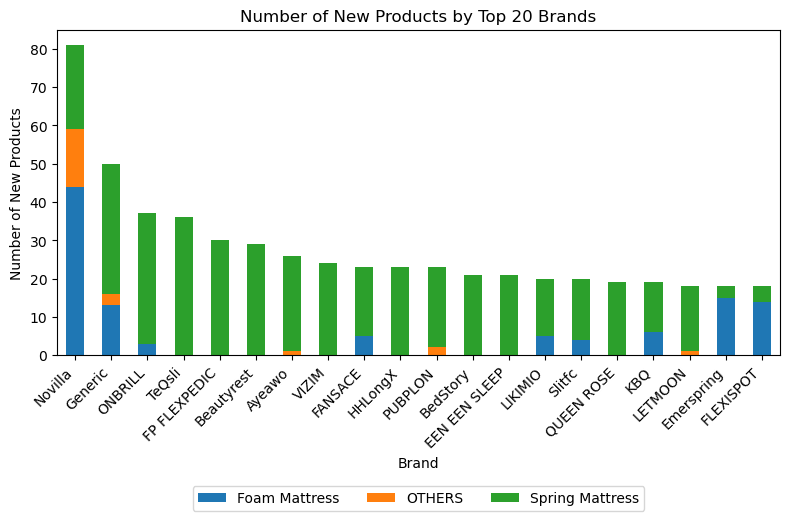

In [123]:
# 1. 브랜드별 신제품 총합 기준 상위 20개 추출
brand_total = (
    df_2025.groupby('brand')['asin']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .index
)

# 2. 이 브랜드들만 필터링하여 category별 신제품 개수 집계
brand_cat_top = (
    df_2025[df_2025['brand'].isin(brand_total)]
    .groupby(['brand', 'category'])['asin']
    .nunique()
    .unstack(fill_value=0)
    .loc[brand_total]   # 순서 유지
)

# 3. 누적(stacked) 막대그래프
brand_cat_top.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)
plt.title('Number of New Products by Top 20 Brands')
plt.xlabel('Brand')
plt.ylabel('Number of New Products')
plt.xticks(rotation=45, ha='right')
#plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(
    #title='Category',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.5),  # 0.5는 x(가운데), -0.3은 y(그래프 아래)
    ncol=5                      # 한 줄에 카테고리 3개씩 (필요에 따라 조정)
)
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_16856\3728288730.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['profile_num'] = pd.to_numeric(df_2025['profile'], errors='coerce')


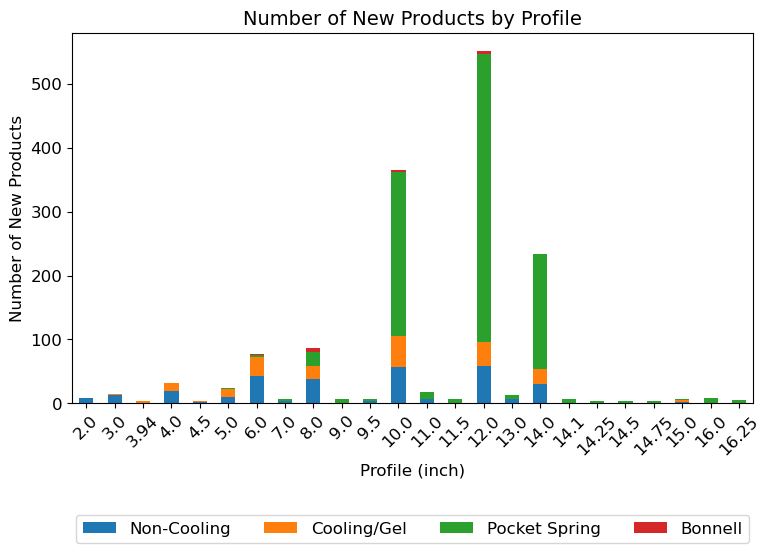

In [386]:
# 1. profile을 숫자형으로 변환
df_2025['profile_num'] = pd.to_numeric(df_2025['profile'], errors='coerce')

# 2. profile, category별 asin 고유 개수 집계
pivot = (
    df_2025
    .groupby(['profile_num', 'subcategory'])['asin']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

# 3. profile별 전체 합 계산 (각 row마다)
profile_totals = pivot.sum(axis=1)

# 4. (예시) 5개 이상인 profile만 필터링
pivot_filtered = pivot[profile_totals >= 3]

# 5. X축 profile 오름차순 정렬 (이미 sort_index로 정렬됨)
# pivot_filtered = pivot_filtered.sort_index(ascending=True) # 필요 시 명시적 사용

# 6. 누적 막대그래프(stacked bar chart)
pivot_filtered.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6)
)
plt.title('Number of New Products by Profile', fontsize=14)
plt.xlabel('Profile (inch)', fontsize=12)
plt.ylabel('Number of New Products', fontsize=12)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.legend(
    #title='Category',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.4),
    ncol=5,   # 카테고리 수에 맞게 조정
    fontsize=12,
    title_fontsize=14
)
plt.tight_layout()
plt.show()

## 5. Market Share 분석

In [135]:
df1 = df.copy()

In [137]:
# 1. 2025년 데이터 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 2. Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 3. CSV로 저장
brand_sales_2025.to_csv('brand_sales_2025_sorted.csv', index=False)

# (선택) 상위 5개 출력
print(brand_sales_2025.head())

    Brand_raw   RetailSales
610     ZINUS  1.401663e+08
386   NOVILLA  6.276125e+07
168       FDW  3.963378e+07
352     MLILY  3.545190e+07
375    NECTAR  3.312092e+07


In [166]:
print(brand_sales_2025['Brand_raw'].nunique())

619


In [141]:
# 1. 2025년 + Foam/Spring만 필터링
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df1[(df1['year'] == 2025) & (df1['category'].isin(target_cats))].copy()

# 2. category, Brand_raw별 매출 합계 집계
brand_sales_by_cat = (
    df_2025.groupby(['category', 'Brand_raw'])['RetailSales']
           .sum()
           .reset_index()
)

# 3. category별 Top 10 브랜드 출력
topn = 10
for category, group in brand_sales_by_cat.groupby('category'):
    top_brands = group.sort_values(by='RetailSales', ascending=False).head(topn)
    print(f"\n[Category: {category}] Top {topn} Brands by RetailSales")
    print(top_brands[['Brand_raw', 'RetailSales']])


[Category: Foam Mattress] Top 10 Brands by RetailSales
               Brand_raw   RetailSales
297                ZINUS  1.143750e+08
192              NOVILLA  4.922243e+07
84                   FDW  3.957806e+07
172                MLILY  3.400318e+07
184               NECTAR  2.413848e+07
96                GAESTE  1.878955e+07
73               EGOHOME  1.292322e+07
50              COOL GEL  1.213054e+07
20   BEST PRICE MATTRESS  1.065620e+07
70               DYONERY  1.015861e+07

[Category: Spring Mattress] Top 10 Brands by RetailSales
                      Brand_raw  RetailSales
567                       ZINUS  25788347.47
321                    BEDSTORY  12725569.86
374                FP FLEXPEDIC  12281239.32
466                     NOVILLA  11658139.23
450                     MOLBIUS  11592986.92
551                   VESGANTTI  10312017.88
337                     COOLVIE  10161218.32
510  SIGNATURE DESIGN BY ASHLEY  10108251.09
408                     KOANTTI   7939715.86
462    

   yr_month  ZINUS_MarketShare(%)
0     23-01             21.630911
1     23-02             19.223365
2     23-03             21.851210
3     23-04             21.663981
4     23-05             17.962815
5     23-06             16.717315
6     23-07             19.217889
7     23-08             15.678568
8     23-09             14.528470
9     23-10             12.593751
10    23-11             12.986644
11    23-12             19.707853
12    24-01             16.110558
13    24-02             13.016853
14    24-03             15.205036
15    24-04             16.335339
16    24-05             14.540987
17    24-06             15.337745
18    24-07             14.346452
19    24-08             14.508770
20    24-09             16.601391
21    24-10             11.666375
22    24-11             12.799560
23    24-12             11.704315
24    25-01             14.275058
25    25-02             15.178152
26    25-03             16.301423
27    25-04             16.667450
28    25-05   

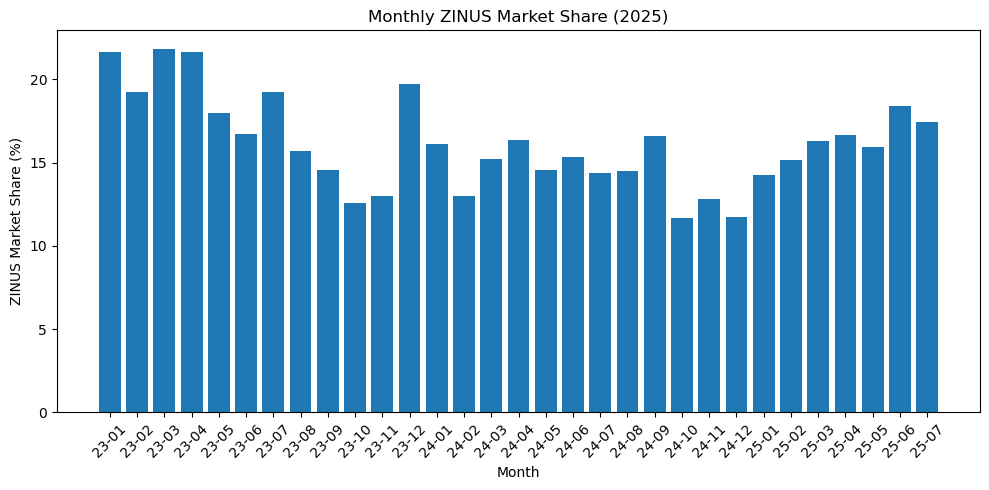

In [174]:
# 1. 2025년 데이터 필터링
#df_2025 = df1[df1['year'] == 2025].copy()

# 2. 월별 전체 매출 집계
monthly_total_sales = (
    df1.groupby('yr_month')['RetailSales']
           .sum()
           .reset_index()
           .rename(columns={'RetailSales': 'TotalSales'})
)

# 3. 월별 ZINUS 매출 집계
monthly_zinus_sales = (
    df1[df1['Brand_raw'].str.upper() == 'ZINUS']
    .groupby('yr_month')['RetailSales']
    .sum()
    .reset_index()
    .rename(columns={'RetailSales': 'ZinusSales'})
)

# 4. 월별 MarketShare(%) 계산
monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

# 5. 결과 출력
print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

plt.figure(figsize=(10, 5))
plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
plt.xlabel('Month')
plt.ylabel('ZINUS Market Share (%)')
plt.title('Monthly ZINUS Market Share (2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[Category: Foam Mattress]
   yr_month  ZINUS_MarketShare(%)
0     23-01             28.628112
1     23-02             24.429491
2     23-03             28.568155
3     23-04             29.006693
4     23-05             23.316958
5     23-06             21.830175
6     23-07             25.616652
7     23-08             22.191880
8     23-09             19.807475
9     23-10             17.742008
10    23-11             19.048443
11    23-12             29.181941
12    24-01             24.537245
13    24-02             20.329131
14    24-03             24.725006
15    24-04             25.570044
16    24-05             22.434140
17    24-06             25.081021
18    24-07             20.894985
19    24-08             23.932235
20    24-09             29.306924
21    24-10             19.112802
22    24-11             19.906940
23    24-12             17.494542
24    25-01             21.928375
25    25-02             23.787957
26    25-03             26.633516
27    25-04          

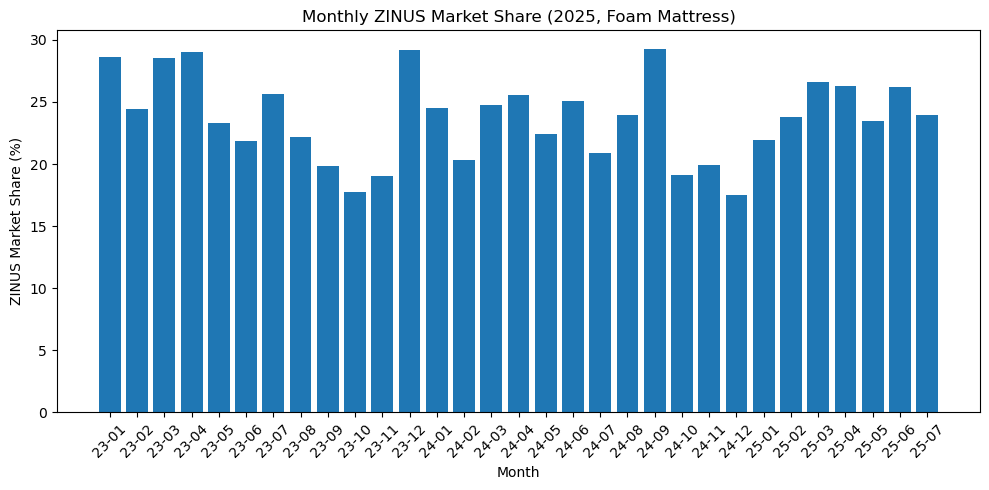


[Category: Spring Mattress]
   yr_month  ZINUS_MarketShare(%)
0     23-01             11.268434
1     23-02             12.879992
2     23-03             13.410256
3     23-04             11.429523
4     23-05             11.296230
5     23-06             10.354024
6     23-07             10.622993
7     23-08              8.035823
8     23-09              9.253170
9     23-10              7.116290
10    23-11              6.051045
11    23-12              9.108785
12    24-01              7.538744
13    24-02              6.787448
14    24-03              6.261483
15    24-04              6.900212
16    24-05              6.952270
17    24-06              7.033318
18    24-07              9.412910
19    24-08              6.780195
20    24-09              6.036159
21    24-10              5.382894
22    24-11              6.230600
23    24-12              5.948663
24    25-01              7.517555
25    25-02              7.524375
26    25-03              6.489518
27    25-04        

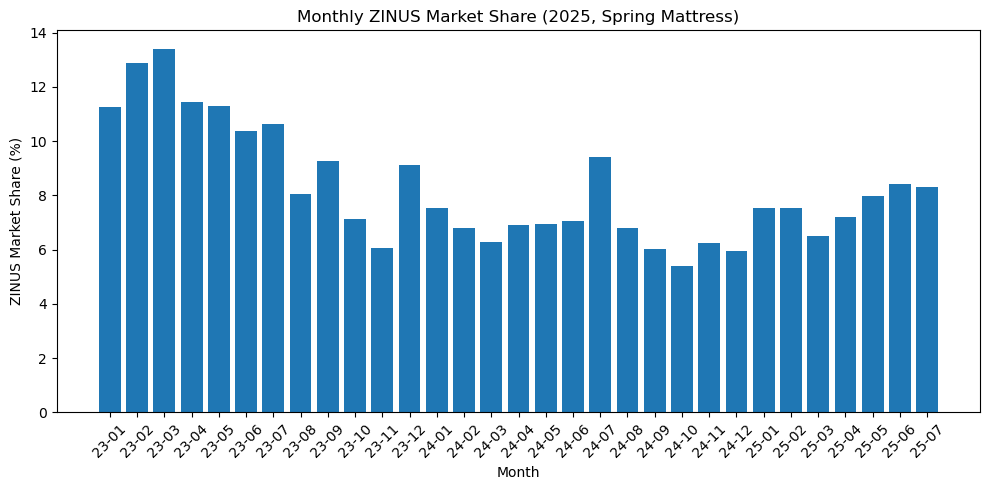

In [176]:
categories = ['Foam Mattress', 'Spring Mattress']

for cat in categories:
    # 1. 해당 카테고리만 필터링
    df_cat = df1[df1['category'] == cat].copy()
    
    # 2. 월별 전체 매출 집계
    monthly_total_sales = (
        df_cat.groupby('yr_month')['RetailSales']
              .sum()
              .reset_index()
              .rename(columns={'RetailSales': 'TotalSales'})
    )

    # 3. 월별 ZINUS 매출 집계
    monthly_zinus_sales = (
        df_cat[df_cat['Brand_raw'].str.upper() == 'ZINUS']
        .groupby('yr_month')['RetailSales']
        .sum()
        .reset_index()
        .rename(columns={'RetailSales': 'ZinusSales'})
    )

    # 4. 월별 MarketShare(%) 계산
    monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
    monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
    monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

    # 5. 결과 출력 (옵션)
    print(f"\n[Category: {cat}]")
    print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

    # 6. 막대그래프
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
    plt.xlabel('Month')
    plt.ylabel('ZINUS Market Share (%)')
    plt.title(f'Monthly ZINUS Market Share (2025, {cat})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

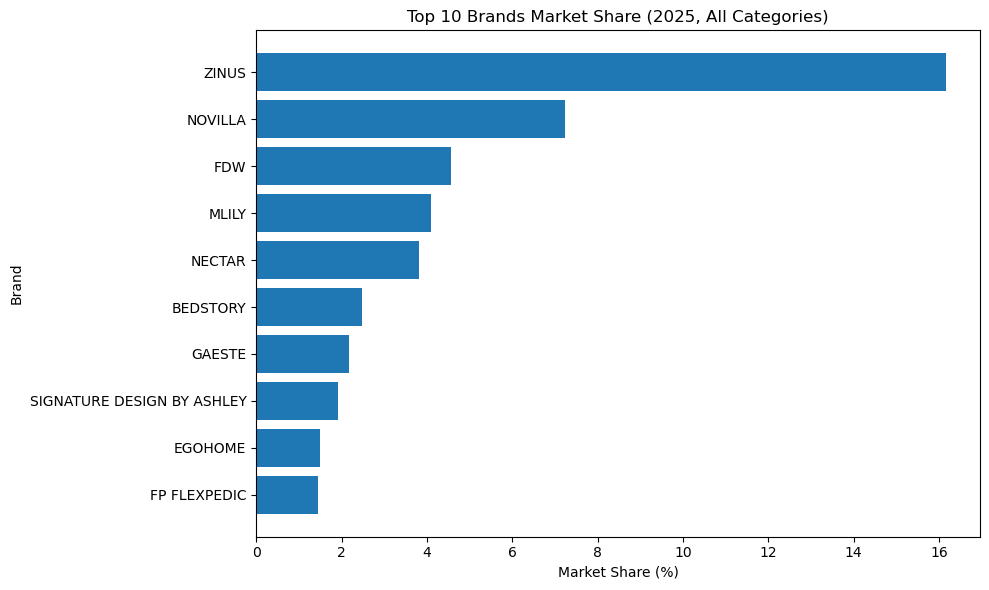

In [168]:
opn = 10

# 1. 2025년 전체 데이터만 사용 (category 구분 X)
df_2025_total = df1[df1['year'] == 2025]

# 2. 브랜드별 매출 집계
brand_sales_all = (
    df_2025_total.groupby('Brand_raw')['RetailSales']
                 .sum()
                 .reset_index()
                 .sort_values(by='RetailSales', ascending=False)
)

# 3. Top 10 브랜드 및 Others 계산
top_brands = brand_sales_all.head(topn).copy()
others_sales = brand_sales_all['RetailSales'][topn:].sum()

# 4. MarketShare 계산 (Top10 + Others 기준)
total_sales = top_brands['RetailSales'].sum() + others_sales
top_brands['MarketShare'] = top_brands['RetailSales'] / total_sales * 100

# 5. 그래프 (Top10만 표시)
plt.figure(figsize=(10, 6))
plt.barh(top_brands['Brand_raw'], top_brands['MarketShare'])
plt.xlabel('Market Share (%)')
plt.ylabel('Brand')
plt.title('Top 10 Brands Market Share (2025, All Categories)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

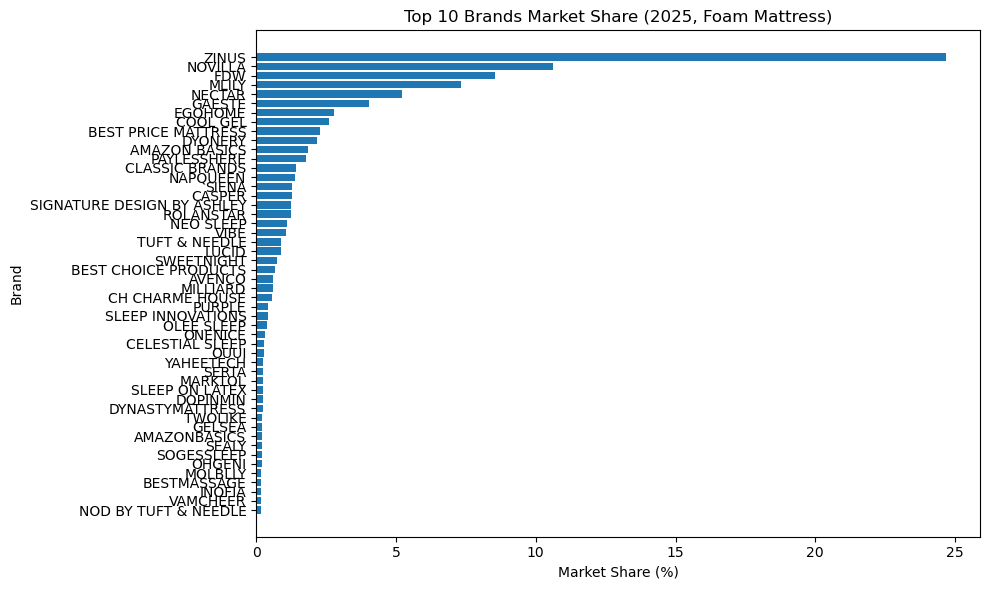

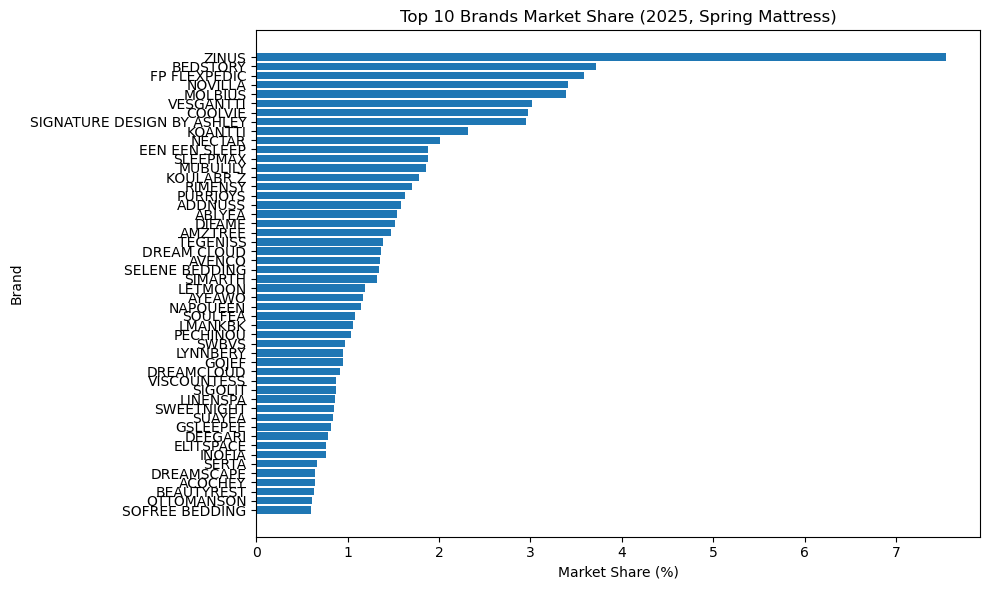

In [180]:
categories = ['Foam Mattress', 'Spring Mattress']
topn = 50

for cat in categories:
    df_2025_cat = df1[(df1['year'] == 2025) & (df1['category'] == cat)]
    
    # 전체 브랜드 매출 집계
    brand_sales_all = (
        df_2025_cat.groupby('Brand_raw')['RetailSales']
                   .sum()
                   .reset_index()
                   .sort_values(by='RetailSales', ascending=False)
    )
    
    # Top 10 추출 및 Others 계산
    top_brands = brand_sales_all.head(topn).copy()
    others_sales = brand_sales_all['RetailSales'][topn:].sum()
    
    # MarketShare 계산 (Top10 + Others 기준)
    total_sales = top_brands['RetailSales'].sum() + others_sales
    top_brands['MarketShare'] = top_brands['RetailSales'] / total_sales * 100
    
    # 그래프 (Top10만 표시)
    plt.figure(figsize=(10, 6))
    plt.barh(top_brands['Brand_raw'], top_brands['MarketShare'])
    plt.xlabel('Market Share (%)')
    plt.ylabel('Brand')
    plt.title(f'Top 10 Brands Market Share (2025, {cat})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

   yr_month  ZINUS_MarketShare(%)
0     23-01              9.447689
1     23-02              9.851803
2     23-03              9.348261
3     23-04             10.021913
4     23-05             10.159380
5     23-06              7.334778
6     23-07              7.393668
7     23-08              6.271916
8     23-09              6.256496
9     23-10              5.410728
10    23-11              4.626941
11    23-12              6.696563
12    24-01              5.776762
13    24-02              5.017301
14    24-03              4.896707
15    24-04              4.752167
16    24-05              4.997880
17    24-06              5.321370
18    24-07              6.943784
19    24-08              4.201077
20    24-09              3.416354
21    24-10              3.776430
22    24-11              4.152049
23    24-12              2.931926
24    25-01              3.218521
25    25-02              3.123281
26    25-03              2.972973
27    25-04              4.174873
28    25-05   

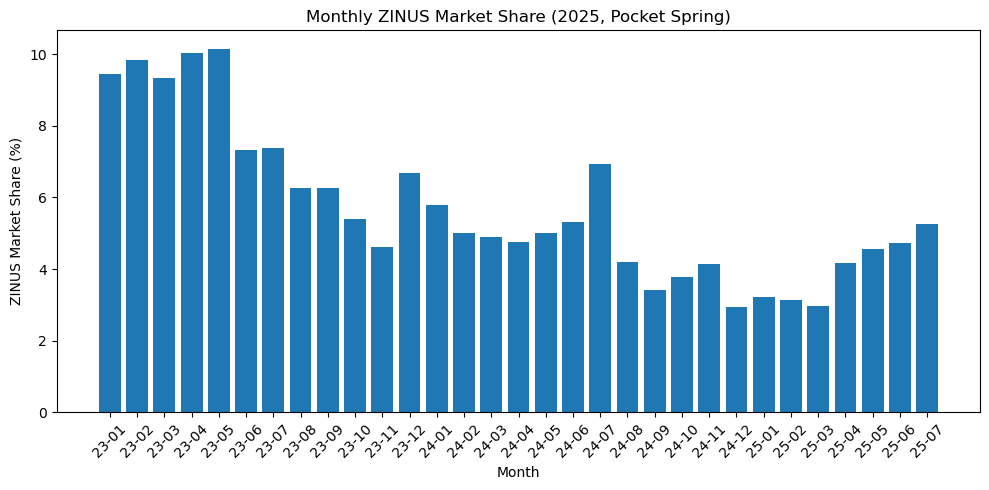

In [183]:

# 1. pocket spring만 필터링
df_pocket = df1[(df1['category'] == 'Spring Mattress') & (df1['subcategory'] == 'Pocket Spring')]

# 2. 월별 전체 매출 집계
monthly_total_sales = (
    df_pocket.groupby('yr_month')['RetailSales']
             .sum()
             .reset_index()
             .rename(columns={'RetailSales': 'TotalSales'})
)

# 3. 월별 ZINUS 매출 집계
monthly_zinus_sales = (
    df_pocket[df_pocket['Brand_raw'].str.upper() == 'ZINUS']
    .groupby('yr_month')['RetailSales']
    .sum()
    .reset_index()
    .rename(columns={'RetailSales': 'ZinusSales'})
)

# 4. 월별 MarketShare(%) 계산
monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

# 5. 결과 출력 (옵션)
print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

# 6. 막대그래프
plt.figure(figsize=(10, 5))
plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
plt.xlabel('Month')
plt.ylabel('ZINUS Market Share (%)')
plt.title('Monthly ZINUS Market Share (2025, Pocket Spring)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                      Brand_raw  RetailSales  MarketShare(%)
21                     BEDSTORY  12725569.86        4.017779
73                 FP FLEXPEDIC  12281239.32        3.877493
260                       ZINUS  12140687.16        3.833117
146                     MOLBIUS  11592986.92        3.660194
161                     NOVILLA  11091284.60        3.501795
244                   VESGANTTI  10312017.88        3.255761
36                      COOLVIE  10161218.32        3.208149
204  SIGNATURE DESIGN BY ASHLEY   9995142.88        3.155715
106                     KOANTTI   7939715.86        2.506766
157                      NECTAR   6872422.27        2.169795
58                EEN EEN SLEEP   6433890.91        2.031339
211                    SLEEPMAX   6427611.60        2.029357
150                    MUBULILY   6368115.20        2.010572
108                   KOULABR Z   6104652.07        1.927391
188                     RIMENSY   5842663.43        1.844674
184                    P

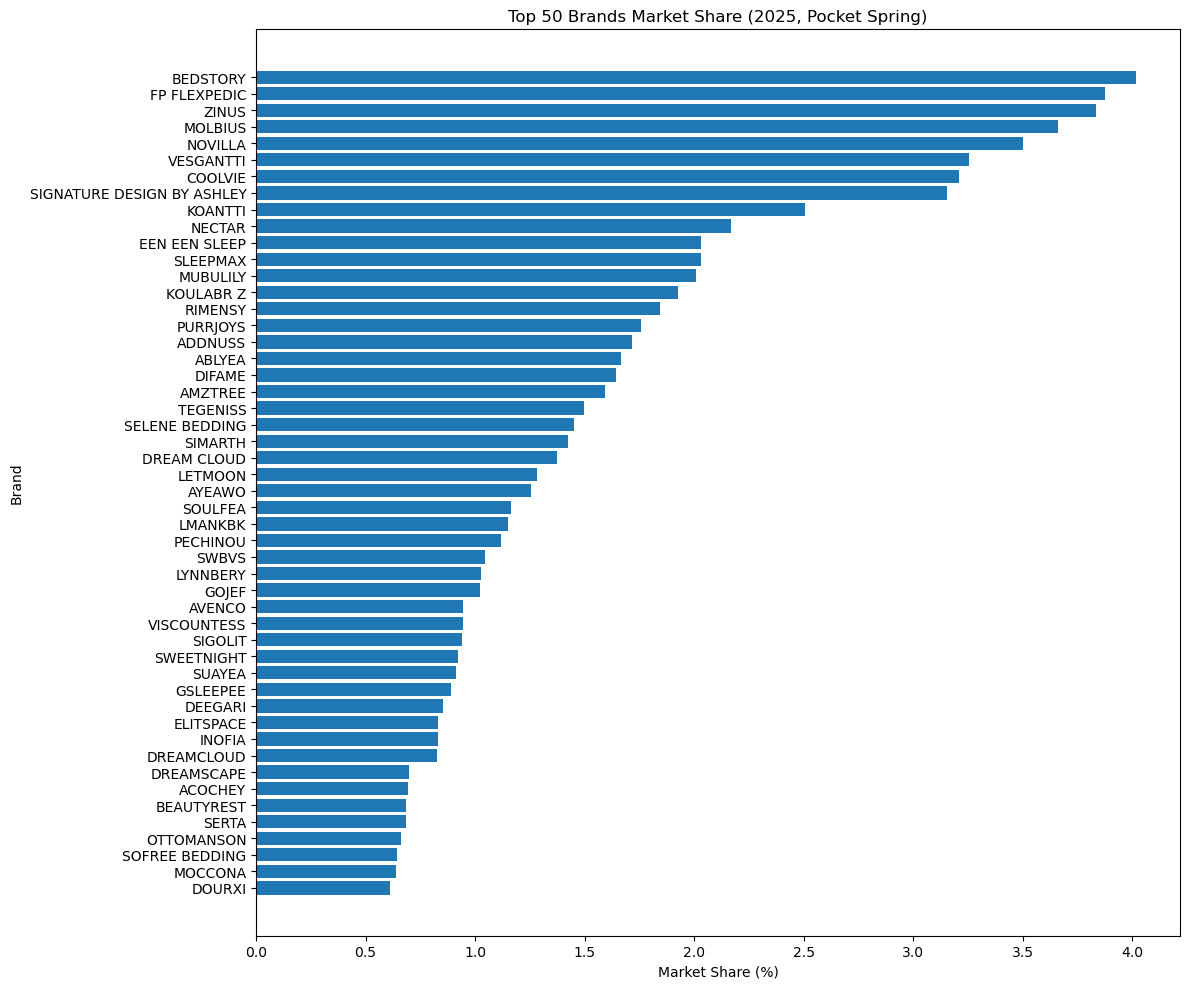

In [185]:
# 1. pocket spring 필터링 (2025년, Spring Mattress, pocket spring)
df_pocket = df1[
    (df1['year'] == 2025) &
    (df1['category'] == 'Spring Mattress') &
    (df1['subcategory'].str.lower() == 'pocket spring')
]

# 2. 브랜드별 매출 합계 집계 (내림차순 정렬)
brand_sales = (
    df_pocket.groupby('Brand_raw')['RetailSales']
             .sum()
             .reset_index()
             .sort_values(by='RetailSales', ascending=False)
)

# 3. Top 50 추출
topn = 50
top_brands = brand_sales.head(topn).copy()

# 4. 전체 매출 합계
total_sales = brand_sales['RetailSales'].sum()

# 5. 시장점유율(%) 계산
top_brands['MarketShare(%)'] = top_brands['RetailSales'] / total_sales * 100

# 6. 결과 확인
print(top_brands[['Brand_raw', 'RetailSales', 'MarketShare(%)']])

# (선택) 그래프
plt.figure(figsize=(12, 10))
plt.barh(top_brands['Brand_raw'], top_brands['MarketShare(%)'])
plt.xlabel('Market Share (%)')
plt.ylabel('Brand')
plt.title('Top 50 Brands Market Share (2025, Pocket Spring)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
topn = 10

for category, group in brand_sales_by_cat.groupby('category'):
    # 1. 매출 기준 정렬
    group_sorted = group.sort_values(by='RetailSales', ascending=False).reset_index(drop=True)
    # 2. Top N 브랜드
    top_brands = group_sorted.head(topn)
    # 3. Others 계산
    others = group_sorted.iloc[topn:]
    others_sales = others['RetailSales'].sum()
    # 4. Top N + Others 데이터프레임 생성
    result = top_brands[['Brand_raw', 'RetailSales']].copy()
    if others_sales > 0:
        others_row = pd.DataFrame({
            'Brand_raw': ['Others'],
            'RetailSales': [others_sales]
        })
        result = pd.concat([result, others_row], ignore_index=True)
    # 5. 비율 컬럼 추가
    total_sales = result['RetailSales'].sum()
    result['SalesRatio'] = (result['RetailSales'] / total_sales * 100).round(2)
    # 6. 출력
    print(f"\n[Category: {category}] Top {topn} Brands (+Others) by RetailSales")
    print(result)

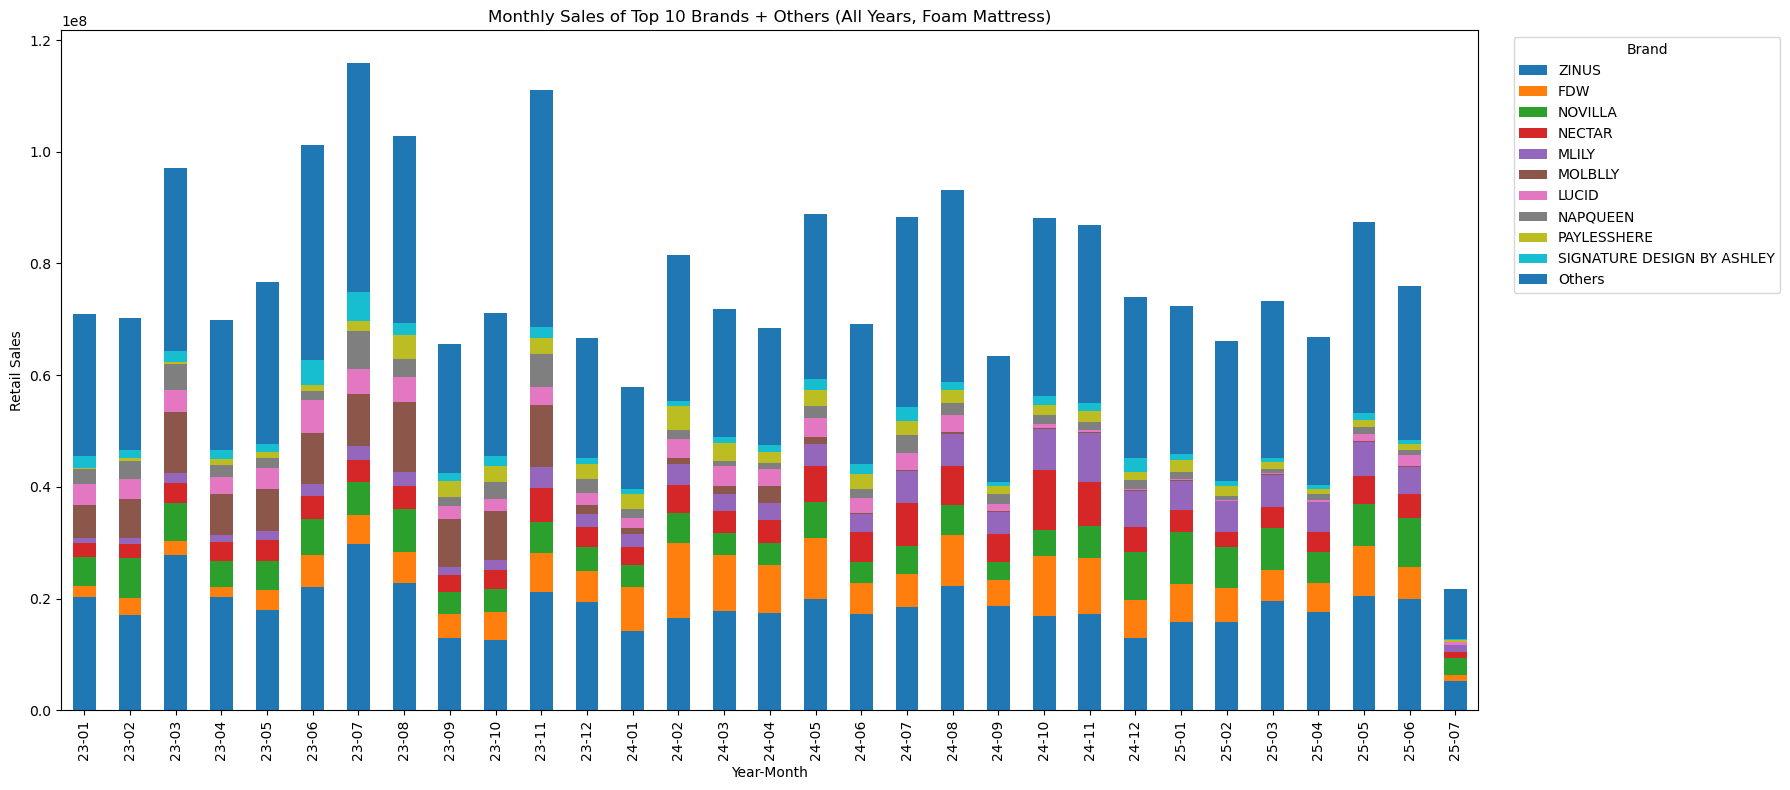

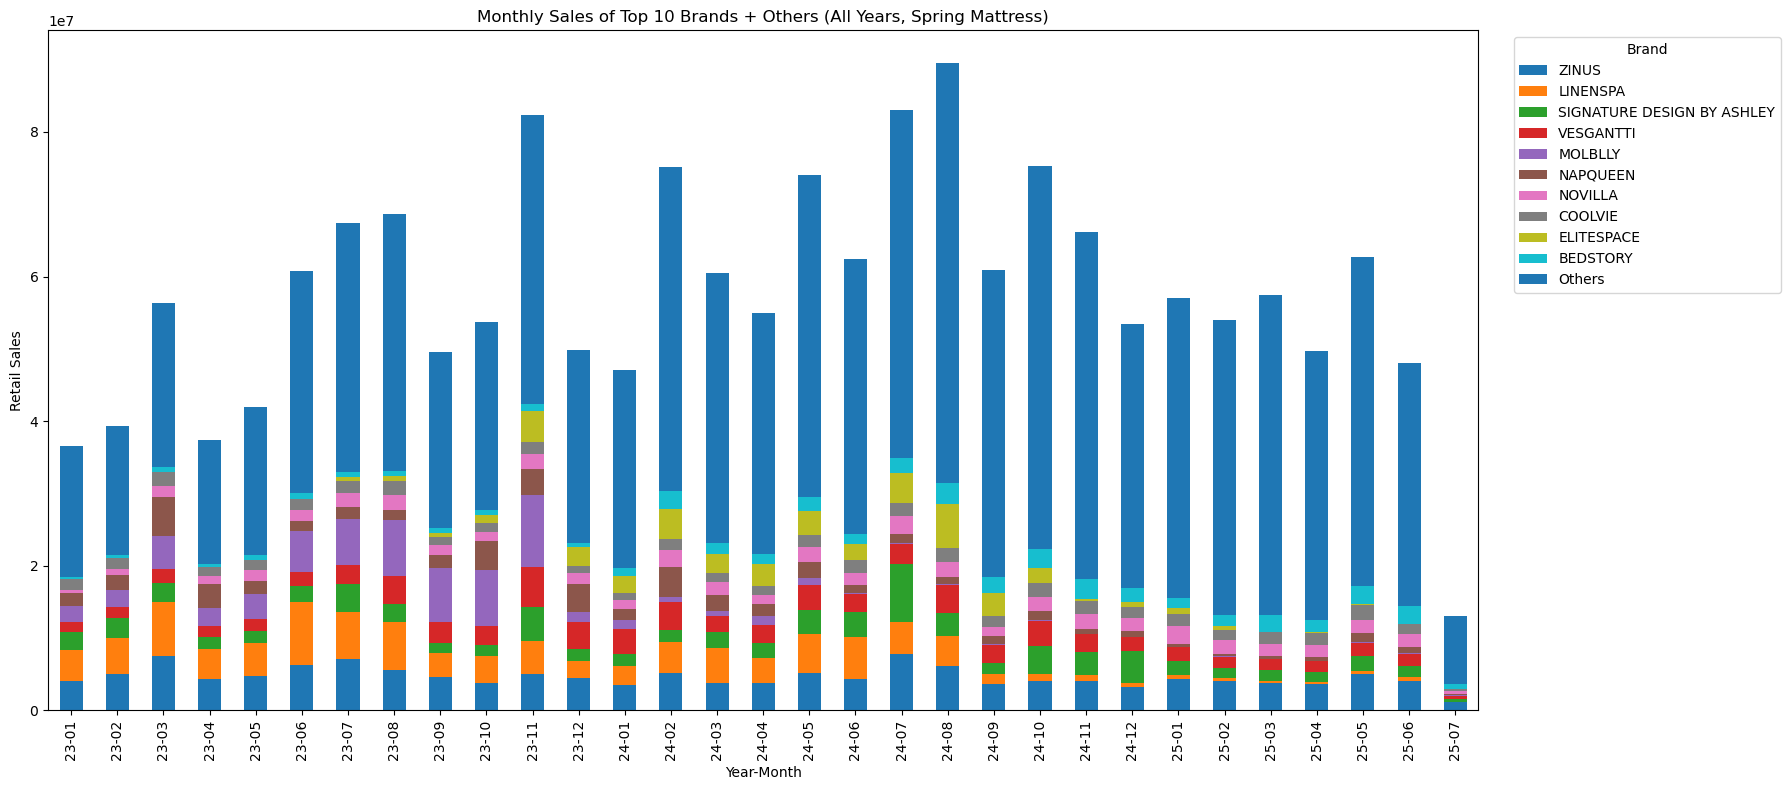

In [157]:
target_cats = ['Foam Mattress', 'Spring Mattress']

for cat in target_cats:
    # 1. 카테고리별 전체 데이터 추출
    df_cat = df1[df1['category'] == cat].copy()
    if df_cat.empty:
        continue

    # 2. 연/월, 브랜드별 매출 집계 (yr_month 사용)
    monthly_brand_sales = (
        df_cat.groupby(['yr_month', 'Brand_raw'])['RetailSales']
              .sum()
              .reset_index()
    )

    # 3. 전체 기간 Top 10 브랜드 선정
    top_brands = (
        monthly_brand_sales.groupby('Brand_raw')['RetailSales']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    # 4. Others 처리
    monthly_brand_sales['Brand_Plot'] = monthly_brand_sales['Brand_raw'].where(
        monthly_brand_sales['Brand_raw'].isin(top_brands), 'Others'
    )

    # 5. Others 포함 월별 합계 재집계
    monthly_plot = (
        monthly_brand_sales.groupby(['yr_month', 'Brand_Plot'])['RetailSales']
        .sum()
        .reset_index()
    )

    # 6. Pivot (Top 10 + Others)
    plot_brands = list(top_brands) + ['Others']
    pivot = monthly_plot.pivot(index='yr_month', columns='Brand_Plot', values='RetailSales').fillna(0)
    pivot = pivot[[b for b in plot_brands if b in pivot.columns]]

    # 7. 누적 막대그래프 그리기
    plt.figure(figsize=(18, 8))
    pivot.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'Monthly Sales of Top 10 Brands + Others (All Years, {cat})')
    plt.xlabel('Year-Month')
    plt.ylabel('Retail Sales')
    plt.legend(title='Brand', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

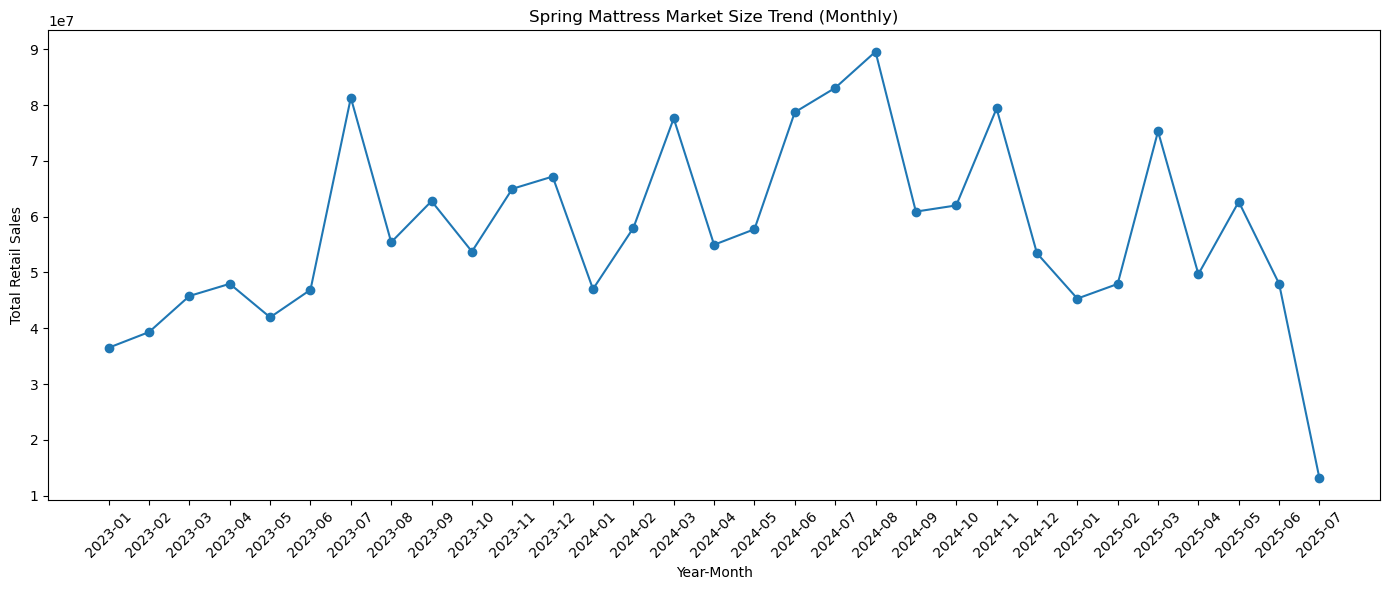

In [153]:

# 1. Spring Mattress 데이터만 추출
df_spring = df1[df1['category'] == 'Spring Mattress'].copy()

# 2. 연/월 추출 (WeekEnding 기준)
df_spring['YearMonth'] = pd.to_datetime(df_spring['WeekEnding']).dt.to_period('M')

# 3. 연/월별 매출 합계 집계
monthly_market = (
    df_spring.groupby('YearMonth')['RetailSales']
    .sum()
    .reset_index()
)

# 4. 라인그래프로 시장 크기 추이 시각화
plt.figure(figsize=(14, 6))
plt.plot(monthly_market['YearMonth'].astype(str), monthly_market['RetailSales'], marker='o')
plt.title('Spring Mattress Market Size Trend (Monthly)')
plt.xlabel('Year-Month')
plt.ylabel('Total Retail Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()